In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import yaml
import os
import glob
import random
import time
from collections import defaultdict

os.environ["XLA_FLAGS"] = "--xla_gpu_deterministic_ops=true --xla_gpu_autotune_level=0"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

sys.path.append("..")

import wandb
# import jax
from dataclasses import asdict
import numpy as np
import pandas as pd
import tqdm
# from agents import agents
# from ml_collections import FrozenConfigDict
#  from utils.datasets import Dataset, GCDataset, HGCDataset
# from utils.evaluation import evaluate
# from utils.flax_utils import restore_agent, save_agent
# from utils.log_utils import CsvLogger, get_exp_name, get_wandb_video, setup_wandb
from utils.config import GCTTTConfig, load_config
import matplotlib.pyplot as plt
import importlib
import re
from utils.plotting import plot_max_overall_success_vs_ttt_steps, plot_mean_success_over_checkpoints
%matplotlib inline

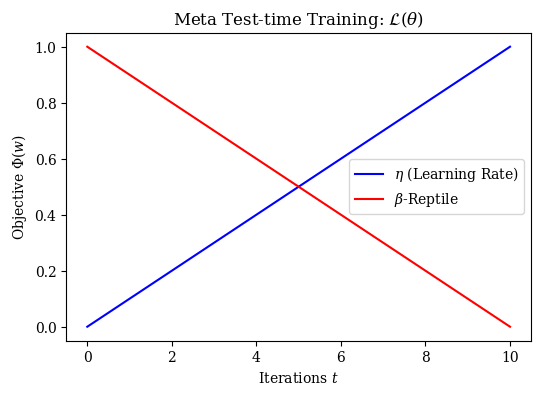

In [3]:
import matplotlib.pyplot as plt

# 1. Use STIX fonts (bundled with Matplotlib)
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif", # Matches the math spacing to the text
})
# 2. Define colors from your LaTeX preamble
colors = {
    "algblue": (0/255, 0/255, 255/255),
    "linkred": (255/255, 0/255, 0/255),
    "citeblue": (0/255, 0/255, 255/255)
}

# 3. Create the Plot
fig, ax = plt.subplots(figsize=(6, 4))

# Use raw strings r"..." for math
ax.plot([0, 10], [0, 1], label=r"$\eta$ (Learning Rate)", color=colors["algblue"])
ax.plot([0, 10], [1, 0], label=r"$\beta$-Reptile", color=colors["linkred"])

ax.set_title(r"Meta Test-time Training: $\mathcal{L}(\theta)$")
ax.set_xlabel(r"Iterations $t$")
ax.set_ylabel(r"Objective $\Phi(w)$")
ax.legend()

plt.show()

# GC-TTT Critic Free (Expert dataset, BC policies)

Group label: Pretrained
Group info: ['pointmaze_expert_bc/RANDOM-point_exp-bc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-04_actor_lossbc']
num_seeds: 3, num_meta_steps: 1
Meta steps: 400000, Area under success curve: 0.7853666666666667


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


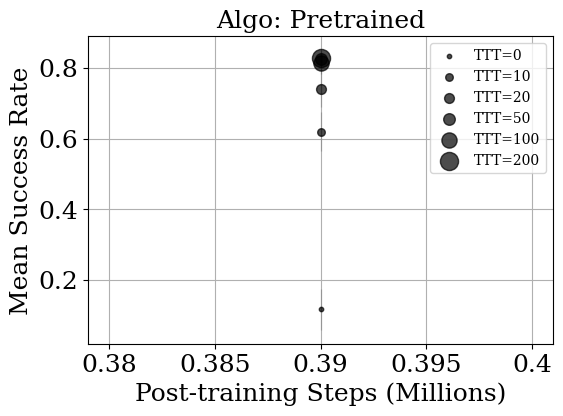

Group label: Continual-TTT
Group info: ['pointmaze_expert_bc/FT-ALL-point_exp-bc-JTAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-04_actor_lossbc']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.782
Meta steps: 10000, Area under success curve: 0.8050666666666666
Meta steps: 15000, Area under success curve: 0.8107
Meta steps: 20000, Area under success curve: 0.8064999999999999
Meta steps: 25000, Area under success curve: 0.8122
Meta steps: 30000, Area under success curve: 0.8218666666666666
Meta steps: 35000, Area under success curve: 0.8092333333333334
Meta steps: 40000, Area under success curve: 0.7986666666666667
Meta steps: 45000, Area under success curve: 0.8059666666666666
Meta steps: 50000, Area under success curve: 0.7968333333333334


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


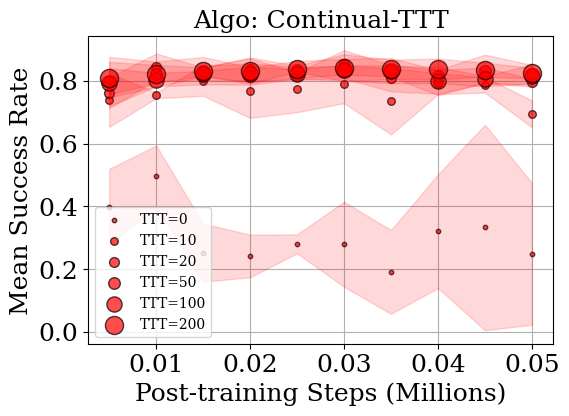

Group label: TT-FOMAML
Group info: ['pointmaze_expert_bc/FT-ALL-point_exp-bc-FFAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-04_actor_lossbc']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.7801333333333333
Meta steps: 10000, Area under success curve: 0.7818999999999999
Meta steps: 15000, Area under success curve: 0.7849666666666667
Meta steps: 20000, Area under success curve: 0.8000666666666667
Meta steps: 25000, Area under success curve: 0.7959666666666666
Meta steps: 30000, Area under success curve: 0.7782333333333333
Meta steps: 35000, Area under success curve: 0.8094333333333332
Meta steps: 40000, Area under success curve: 0.7961333333333335
Meta steps: 45000, Area under success curve: 0.8060666666666667
Meta steps: 50000, Area under success curve: 0.8034333333333333


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


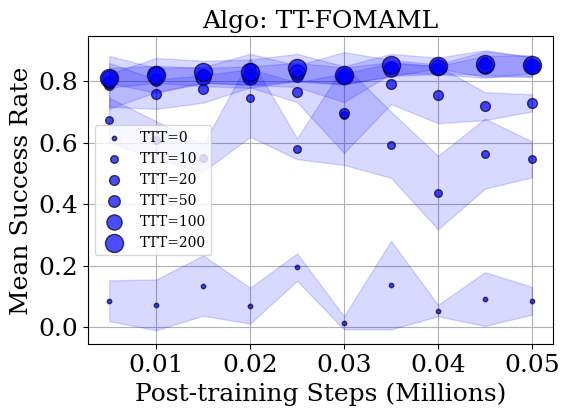

Group label: TT-Reptile
Group info: ['pointmaze_expert_bc/FT-ALL-point_exp-bc-RRAB-100-1-m_0.01-lr0.01-ilr3e-05_finetune_lr3e-04_actor_lossbc']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.7908333333333334
Meta steps: 10000, Area under success curve: 0.796
Meta steps: 15000, Area under success curve: 0.8009333333333334
Meta steps: 20000, Area under success curve: 0.8033666666666668
Meta steps: 25000, Area under success curve: 0.8099000000000001
Meta steps: 30000, Area under success curve: 0.8066
Meta steps: 35000, Area under success curve: 0.8155666666666668
Meta steps: 40000, Area under success curve: 0.8100666666666666
Meta steps: 45000, Area under success curve: 0.8238
Meta steps: 50000, Area under success curve: 0.8194


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


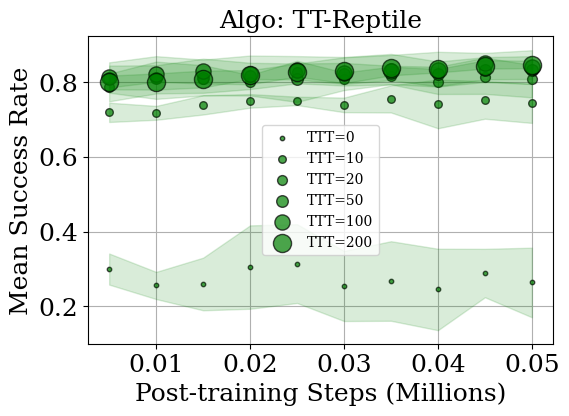

num_seeds: 3, num_meta_steps: 1
Area under success curve for best checkpoint Pretrained: 0.7853666666666667 at meta_steps 400000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint Continual-TTT: 0.8218666666666666 at meta_steps 30000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint TT-FOMAML: 0.8094333333333332 at meta_steps 35000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint TT-Reptile: 0.8238 at meta_steps 45000

Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
Continual-TTT                                       0.2800 ± 0.1352  0.7880 ± 0.0595  0.8520 ± 0.0450  0.8347 ± 0.0349  0.8347 ± 0.0149  0.8413 ± 0.0428  

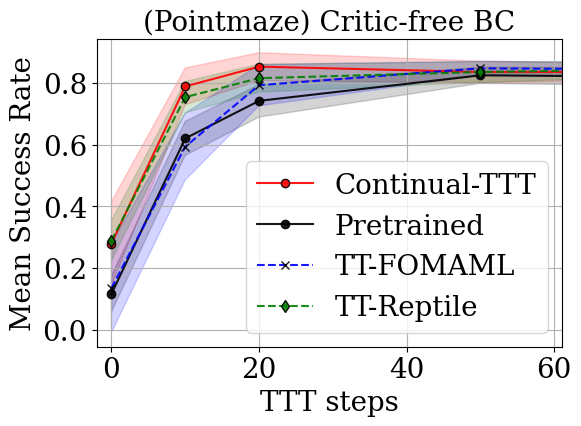

<Axes: title={'center': '(Pointmaze) Critic-free BC'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [42]:
POINTMAZE_BC_BASELINE = {
    "Pretrained": {
        "groups": [
            "pointmaze_expert_bc/RANDOM-point_exp-bc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-04_actor_lossbc"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Continual-TTT": {
        "groups": [
            "pointmaze_expert_bc/FT-ALL-point_exp-bc-JTAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-04_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
    },

    "TT-FOMAML": {
        "groups": [
            "pointmaze_expert_bc/FT-ALL-point_exp-bc-FFAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-04_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },


    "TT-Reptile": {
        "groups": [
            "pointmaze_expert_bc/FT-ALL-point_exp-bc-RRAB-100-1-m_0.01-lr0.01-ilr3e-05_finetune_lr3e-04_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },
}

for run_name, run_info in POINTMAZE_BC_BASELINE.items():
    plot_mean_success_over_checkpoints({run_name: run_info}, new_style=True)

plot_max_overall_success_vs_ttt_steps(
    POINTMAZE_BC_BASELINE,
    title="(Pointmaze) Critic-free BC",
    print_table=True,
    xlim=(-2, 61),
    figure_path="figures/pointmaze_bc_critic_free.pdf",
    use_best_auc_up_to=200,
    )


Group label: Pretrained
Group info: ['antmaze_expert_bc/RANDOM-ant_exp-bc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-04_actor_lossbc_TTT_actor']
num_seeds: 3, num_meta_steps: 1
Meta steps: 400000, Area under success curve: 0.5101
Saving figure to figures/antmaze_critic_free_Pretrained_metasteps.pdf


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


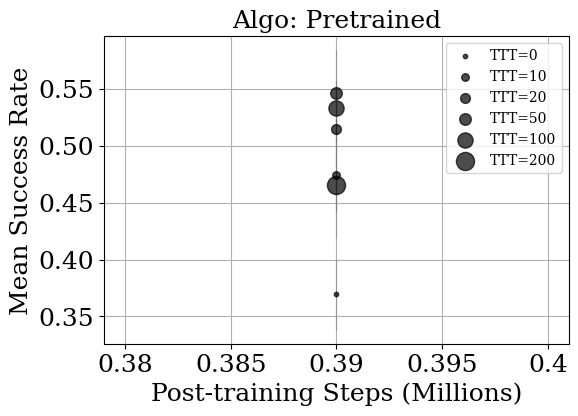

Group label: Continual-TTT
Group info: ['antmaze_expert_bc/FT-ALL-ant_exp-bc-JTAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-04_actor_lossbc']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.6349999999999999
Meta steps: 10000, Area under success curve: 0.6355666666666666
Meta steps: 15000, Area under success curve: 0.6212333333333333
Meta steps: 20000, Area under success curve: 0.6315999999999999
Meta steps: 25000, Area under success curve: 0.6219666666666666
Meta steps: 30000, Area under success curve: 0.6138999999999999
Meta steps: 35000, Area under success curve: 0.6072333333333333
Meta steps: 40000, Area under success curve: 0.5980333333333333
Meta steps: 45000, Area under success curve: 0.5819666666666667
Meta steps: 50000, Area under success curve: 0.5962666666666666


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


Saving figure to figures/antmaze_critic_free_Continual-TTT_metasteps.pdf


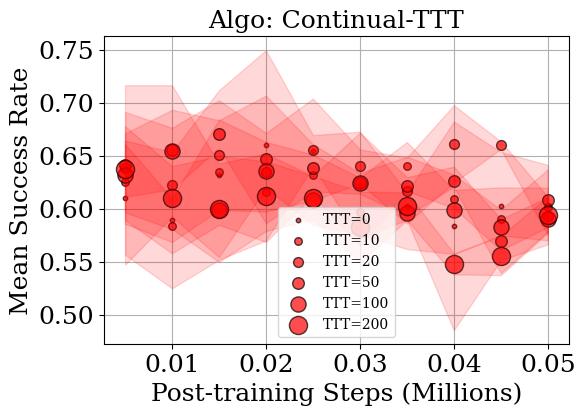

Group label: TT-FOMAML
Group info: ['antmaze_expert_bc/FT-ALL-ant_exp-bc-FFAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-04_actor_lossbc']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.6169333333333331
Meta steps: 10000, Area under success curve: 0.6276333333333334
Meta steps: 15000, Area under success curve: 0.6530666666666665
Meta steps: 20000, Area under success curve: 0.6397666666666666
Meta steps: 25000, Area under success curve: 0.6922333333333333
Meta steps: 30000, Area under success curve: 0.69
Meta steps: 35000, Area under success curve: 0.7040333333333332
Meta steps: 40000, Area under success curve: 0.6994333333333331
Meta steps: 45000, Area under success curve: 0.6944666666666666
Meta steps: 50000, Area under success curve: 0.7030333333333333
Saving figure to figures/antmaze_critic_free_TT-FOMAML_metasteps.pdf


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


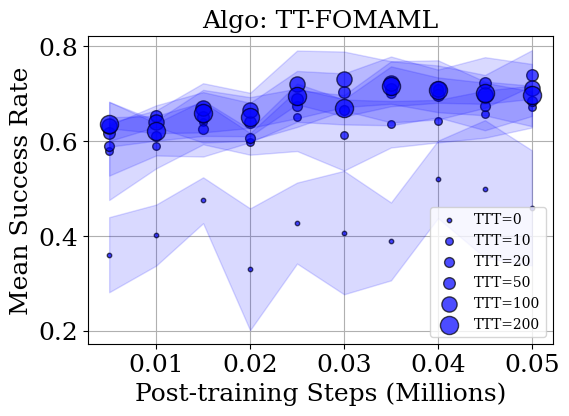

Group label: TT-Reptile
Group info: ['antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.5-lr0.5-ilr0.0003_finetune_lr3e-04_actor_lossbc']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.6286333333333333
Meta steps: 10000, Area under success curve: 0.5913333333333334
Meta steps: 15000, Area under success curve: 0.5662
Meta steps: 20000, Area under success curve: 0.56
Meta steps: 25000, Area under success curve: 0.5364
Meta steps: 30000, Area under success curve: 0.5356000000000001
Meta steps: 35000, Area under success curve: 0.5105000000000001
Meta steps: 40000, Area under success curve: 0.49946666666666656
Meta steps: 45000, Area under success curve: 0.5156000000000001
Meta steps: 50000, Area under success curve: 0.48566666666666664
Saving figure to figures/antmaze_critic_free_TT-Reptile_metasteps.pdf


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


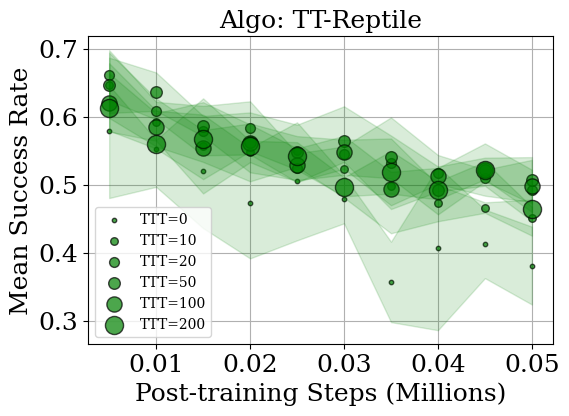

num_seeds: 3, num_meta_steps: 1
Area under success curve for best checkpoint Pretrained: 0.5101 at meta_steps 400000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint Continual-TTT: 0.6355666666666666 at meta_steps 10000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint TT-FOMAML: 0.7040333333333332 at meta_steps 35000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint TT-Reptile: 0.6286333333333333 at meta_steps 5000

Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
Continual-TTT                                       0.5893 ± 0.0643  0.5840 ± 0.0259  0.6227 ± 0.0539  0.6560 ± 0.0375  0.6547 ± 0.0620  0.6107 ± 0.0296   

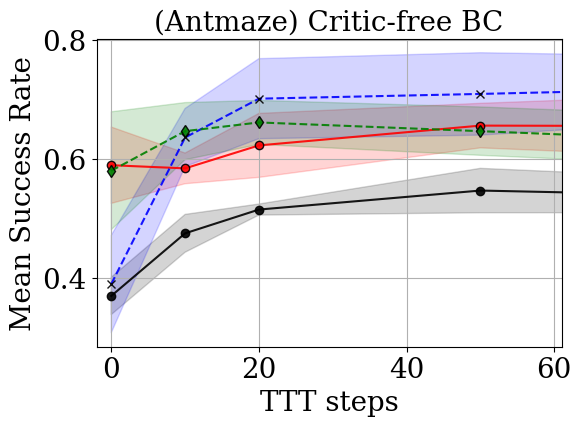

<Axes: title={'center': '(Antmaze) Critic-free BC'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [43]:
ANTMAZE_BC_CRITIC_FREE = {
    "Pretrained": {
        "groups": [
            "antmaze_expert_bc/RANDOM-ant_exp-bc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-04_actor_lossbc_TTT_actor"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Continual-TTT": {
        "groups": [
            "antmaze_expert_bc/FT-ALL-ant_exp-bc-JTAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-04_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
    },

    "TT-FOMAML": {
        "groups": [
            "antmaze_expert_bc/FT-ALL-ant_exp-bc-FFAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-04_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },

    "TT-Reptile": {
        "groups": [
            "antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.5-lr0.5-ilr0.0003_finetune_lr3e-04_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },


    # gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.01-lr0.01-ilr0.0003_finetune_lr3e-04_actor_lossbc
    # gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.01-lr0.01-ilr0.0003_finetune_lr3e-05_actor_lossbc
    # gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.01-lr0.01-ilr3e-05_finetune_lr3e-04_actor_lossbc
    # gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.01-lr0.01-ilr3e-05_finetune_lr3e-05_actor_lossbc
    # gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.2-lr0.2-ilr0.0003_finetune_lr3e-04_actor_lossbc
    # gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.2-lr0.2-ilr0.0003_finetune_lr3e-05_actor_lossbc
    # gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.2-lr0.2-ilr3e-05_finetune_lr3e-04_actor_lossbc
    #gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.2-lr0.2-ilr3e-05_finetune_lr3e-05_actor_lossbc
    # gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.5-lr0.5-ilr0.0003_finetune_lr3e-04_actor_lossbc
    #gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.5-lr0.5-ilr0.0003_finetune_lr3e-05_actor_lossbc
    # gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.5-lr0.5-ilr3e-05_finetune_lr3e-04_actor_lossbc
    #gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.5-lr0.5-ilr3e-05_finetune_lr3e-05_actor_lossbc

    #"TT-Reptile $\\epsilon=0.1 ilr 3e-04$": {
    #    "groups": [
    #        "pointmaze_expert_bc/FT-ALL-point_exp-bc-RRAB-100-1-m_0.1-lr0.1-ilr0.0003_finetune_lr3e-04_actor_lossbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "-",
    #    "dot_type": "d",
    #},

    #"TT-Reptile $\\epsilon=0.1$ ilr 3e-05": {
    #    "groups": [
    #        "pointmaze_expert_bc/FT-ALL-point_exp-bc-RRAB-100-1-m_0.1-lr0.1-ilr3e-05_finetune_lr3e-04_actor_lossbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #    "dot_type": "d",
    #},

    #"TT-Reptile $\epsilon=0.2$ ilr 3e-04": {
    #    "groups": [
    #        "pointmaze_expert_bc/FT-ALL-point_exp-bc-RRAB-100-1-m_0.2-lr0.2-ilr0.0003_finetune_lr3e-04_actor_lossbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "-",
    #    "dot_type": "o",
    #},

    #"TT-Reptile $\epsilon=0.2$ ilr 3e-05": {
    #    "groups": [
    #        "pointmaze_expert_bc/FT-ALL-point_exp-bc-RRAB-100-1-m_0.2-lr0.2-ilr3e-05_finetune_lr3e-04_actor_lossbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #    "dot_type": "o",
    #},
}

for run_name, run_info in ANTMAZE_BC_CRITIC_FREE.items():
    plot_mean_success_over_checkpoints({run_name: run_info}, new_style=True, figure_path=f"figures/antmaze_critic_free_{run_name}_metasteps.pdf")

plot_max_overall_success_vs_ttt_steps(
    ANTMAZE_BC_CRITIC_FREE,
    title="(Antmaze) Critic-free BC",
    print_table=True,
    xlim=(-2, 61),
    figure_path="figures/antmaze_bc_critic_free.pdf",
    show_legend=False,
    use_best_auc_up_to=200,
)


Group label: Pretrained
Group info: ['antmaze_expert_bc/RANDOM-ant_exp-bc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-04_actor_lossbc_TTT_actor']
num_seeds: 3, num_meta_steps: 1
Meta steps: 400000, Area under success curve: 0.5101


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


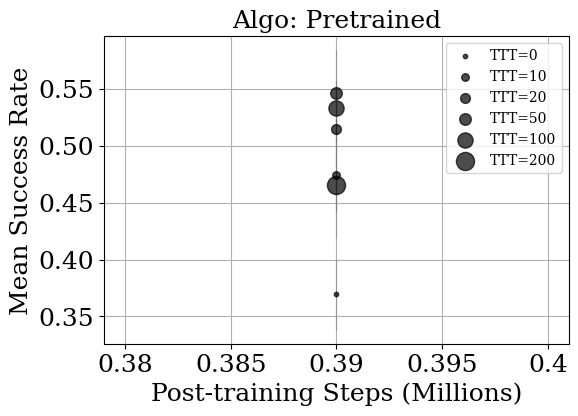

Group label: Continual-TTT
Group info: ['antmaze_expert_bc/FT-ALL-ant_exp-bc-JTAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-04_actor_lossbc']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.6349999999999999
Meta steps: 10000, Area under success curve: 0.6355666666666666
Meta steps: 15000, Area under success curve: 0.6212333333333333
Meta steps: 20000, Area under success curve: 0.6315999999999999
Meta steps: 25000, Area under success curve: 0.6219666666666666
Meta steps: 30000, Area under success curve: 0.6138999999999999
Meta steps: 35000, Area under success curve: 0.6072333333333333
Meta steps: 40000, Area under success curve: 0.5980333333333333
Meta steps: 45000, Area under success curve: 0.5819666666666667
Meta steps: 50000, Area under success curve: 0.5962666666666666


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


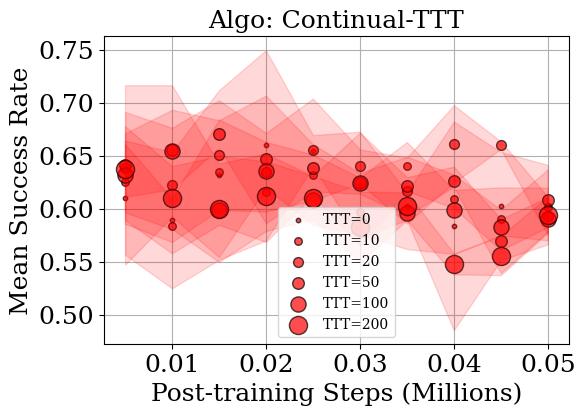

Group label: Continual-TTT lr 3e-04
Group info: ['antmaze_expert_bc/FT-ALL-ant_exp-bc-JTAB-100-1-lr0.0003-ilr0.0003_finetune_lr3e-04_actor_lossbc']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.6481
Meta steps: 10000, Area under success curve: 0.6292333333333333
Meta steps: 15000, Area under success curve: 0.5876666666666667
Meta steps: 20000, Area under success curve: 0.5791333333333333
Meta steps: 25000, Area under success curve: 0.5630666666666666
Meta steps: 30000, Area under success curve: 0.5730666666666666
Meta steps: 35000, Area under success curve: 0.5577333333333333
Meta steps: 40000, Area under success curve: 0.5382333333333333
Meta steps: 45000, Area under success curve: 0.5511333333333334
Meta steps: 50000, Area under success curve: 0.5572333333333334


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


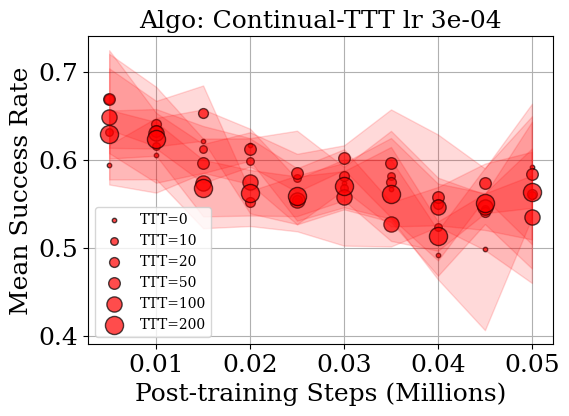

Group label: TT-FOMAML
Group info: ['antmaze_expert_bc/FT-ALL-ant_exp-bc-FFAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-04_actor_lossbc']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.6169333333333331
Meta steps: 10000, Area under success curve: 0.6276333333333334
Meta steps: 15000, Area under success curve: 0.6530666666666665
Meta steps: 20000, Area under success curve: 0.6397666666666666
Meta steps: 25000, Area under success curve: 0.6922333333333333
Meta steps: 30000, Area under success curve: 0.69
Meta steps: 35000, Area under success curve: 0.7040333333333332
Meta steps: 40000, Area under success curve: 0.6994333333333331
Meta steps: 45000, Area under success curve: 0.6944666666666666
Meta steps: 50000, Area under success curve: 0.7030333333333333


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


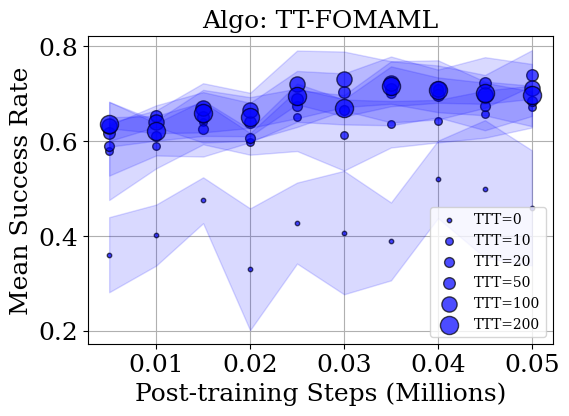

Group label: TT-FOMAML lr 3e-04
Group info: ['antmaze_expert_bc/FT-ALL-ant_exp-bc-FFAB-100-1-lr0.0003-ilr0.0003_finetune_lr3e-04_actor_lossbc']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.4433333333333333
Meta steps: 10000, Area under success curve: 0.4343666666666666
Meta steps: 15000, Area under success curve: 0.44439999999999996
Meta steps: 20000, Area under success curve: 0.5315666666666666
Meta steps: 25000, Area under success curve: 0.5318666666666667
Meta steps: 30000, Area under success curve: 0.48649999999999993
Meta steps: 35000, Area under success curve: 0.5277666666666666
Meta steps: 40000, Area under success curve: 0.5107666666666666
Meta steps: 45000, Area under success curve: 0.4976
Meta steps: 50000, Area under success curve: 0.5110666666666667


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


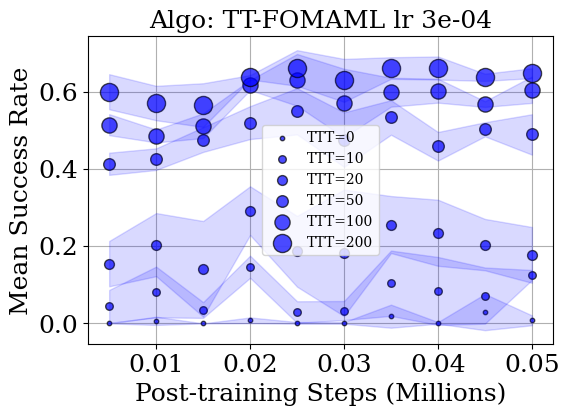

Group label: TT-Reptile
Group info: ['antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.5-lr0.5-ilr0.0003_finetune_lr3e-04_actor_lossbc']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.6286333333333333
Meta steps: 10000, Area under success curve: 0.5913333333333334
Meta steps: 15000, Area under success curve: 0.5662
Meta steps: 20000, Area under success curve: 0.56
Meta steps: 25000, Area under success curve: 0.5364
Meta steps: 30000, Area under success curve: 0.5356000000000001
Meta steps: 35000, Area under success curve: 0.5105000000000001
Meta steps: 40000, Area under success curve: 0.49946666666666656
Meta steps: 45000, Area under success curve: 0.5156000000000001
Meta steps: 50000, Area under success curve: 0.48566666666666664


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


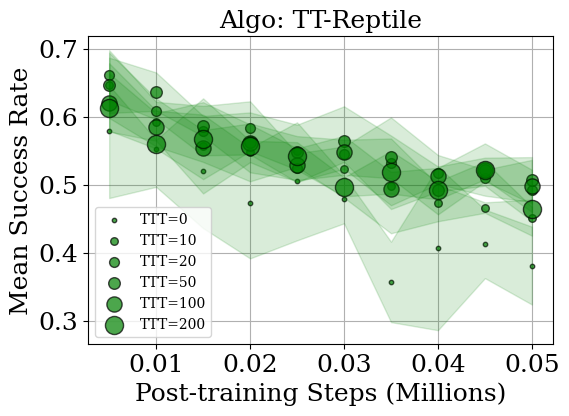

Group label: TT-Reptile lr 3e-05
Group info: ['antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.5-lr0.5-ilr3e-05_finetune_lr3e-04_actor_lossbc']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.5809666666666667
Meta steps: 10000, Area under success curve: 0.5599333333333333
Meta steps: 15000, Area under success curve: 0.5730999999999998
Meta steps: 20000, Area under success curve: 0.5619333333333333
Meta steps: 25000, Area under success curve: 0.5394666666666666
Meta steps: 30000, Area under success curve: 0.5260666666666667
Meta steps: 35000, Area under success curve: 0.5193333333333333
Meta steps: 40000, Area under success curve: 0.5115666666666666
Meta steps: 45000, Area under success curve: 0.4898
Meta steps: 50000, Area under success curve: 0.5039666666666666


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


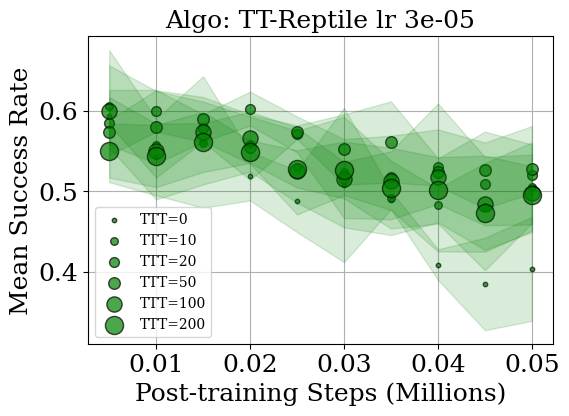

num_seeds: 3, num_meta_steps: 1
Area under success curve for best checkpoint Pretrained: 0.5101 at meta_steps 400000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint Continual-TTT: 0.6355666666666666 at meta_steps 10000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint Continual-TTT lr 3e-04: 0.6481 at meta_steps 5000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint TT-FOMAML: 0.7040333333333332 at meta_steps 35000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint TT-FOMAML lr 3e-04: 0.5318666666666667 at meta_steps 25000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint TT-Reptile: 0.6286333333333333 at meta_steps 5000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint TT-Reptile lr 3e-05: 0.5809666666666667 at meta_steps 5000

Results Table: Max Overall Success vs TTT_steps
Label                                       

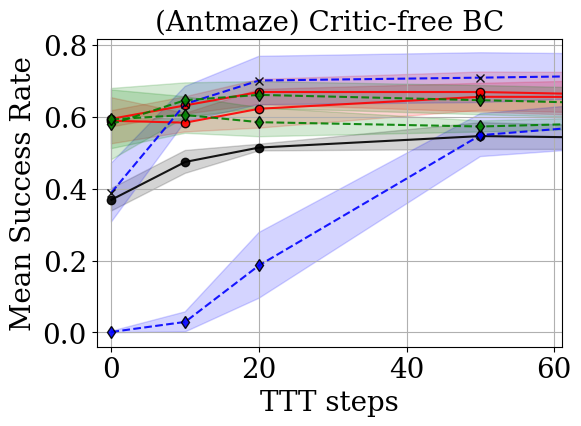

<Axes: title={'center': '(Antmaze) Critic-free BC'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [16]:
ANTMAZE_BC_CRITIC_FREE = {
    "Pretrained": {
        "groups": [
            "antmaze_expert_bc/RANDOM-ant_exp-bc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-04_actor_lossbc_TTT_actor"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Continual-TTT": {
        "groups": [
            "antmaze_expert_bc/FT-ALL-ant_exp-bc-JTAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-04_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
    },

    "Continual-TTT lr 3e-04": {
        "groups": [
            "antmaze_expert_bc/FT-ALL-ant_exp-bc-JTAB-100-1-lr0.0003-ilr0.0003_finetune_lr3e-04_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
    },

    "TT-FOMAML": {
        "groups": [
            "antmaze_expert_bc/FT-ALL-ant_exp-bc-FFAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-04_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },

    "TT-FOMAML lr 3e-04": {
        "groups": [
            "antmaze_expert_bc/FT-ALL-ant_exp-bc-FFAB-100-1-lr0.0003-ilr0.0003_finetune_lr3e-04_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "d",
    },

    "TT-Reptile": {
        "groups": [
            "antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.5-lr0.5-ilr0.0003_finetune_lr3e-04_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },

    "TT-Reptile lr 3e-05": {
        "groups": [
            "antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.5-lr0.5-ilr3e-05_finetune_lr3e-04_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },


    # gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.01-lr0.01-ilr0.0003_finetune_lr3e-04_actor_lossbc
    # gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.01-lr0.01-ilr0.0003_finetune_lr3e-05_actor_lossbc
    # gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.01-lr0.01-ilr3e-05_finetune_lr3e-04_actor_lossbc
    # gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.01-lr0.01-ilr3e-05_finetune_lr3e-05_actor_lossbc
    # gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.2-lr0.2-ilr0.0003_finetune_lr3e-04_actor_lossbc
    # gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.2-lr0.2-ilr0.0003_finetune_lr3e-05_actor_lossbc
    # gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.2-lr0.2-ilr3e-05_finetune_lr3e-04_actor_lossbc
    #gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.2-lr0.2-ilr3e-05_finetune_lr3e-05_actor_lossbc
    # gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.5-lr0.5-ilr0.0003_finetune_lr3e-04_actor_lossbc
    #gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.5-lr0.5-ilr0.0003_finetune_lr3e-05_actor_lossbc
    # gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.5-lr0.5-ilr3e-05_finetune_lr3e-04_actor_lossbc
    #gc_ttt/notebooks/results_eval/antmaze_expert_bc/FT-ALL-ant_exp-bc-RRAB-100-1-m_0.5-lr0.5-ilr3e-05_finetune_lr3e-05_actor_lossbc

    #"TT-Reptile $\\epsilon=0.1 ilr 3e-04$": {
    #    "groups": [
    #        "pointmaze_expert_bc/FT-ALL-point_exp-bc-RRAB-100-1-m_0.1-lr0.1-ilr0.0003_finetune_lr3e-04_actor_lossbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "-",
    #    "dot_type": "d",
    #},

    #"TT-Reptile $\\epsilon=0.1$ ilr 3e-05": {
    #    "groups": [
    #        "pointmaze_expert_bc/FT-ALL-point_exp-bc-RRAB-100-1-m_0.1-lr0.1-ilr3e-05_finetune_lr3e-04_actor_lossbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #    "dot_type": "d",
    #},

    #"TT-Reptile $\epsilon=0.2$ ilr 3e-04": {
    #    "groups": [
    #        "pointmaze_expert_bc/FT-ALL-point_exp-bc-RRAB-100-1-m_0.2-lr0.2-ilr0.0003_finetune_lr3e-04_actor_lossbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "-",
    #    "dot_type": "o",
    #},

    #"TT-Reptile $\epsilon=0.2$ ilr 3e-05": {
    #    "groups": [
    #        "pointmaze_expert_bc/FT-ALL-point_exp-bc-RRAB-100-1-m_0.2-lr0.2-ilr3e-05_finetune_lr3e-04_actor_lossbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #    "dot_type": "o",
    #},
}

for run_name, run_info in ANTMAZE_BC_CRITIC_FREE.items():
    plot_mean_success_over_checkpoints({run_name: run_info}, new_style=True)

plot_max_overall_success_vs_ttt_steps(
    ANTMAZE_BC_CRITIC_FREE,
    title="(Antmaze) Critic-free BC",
    print_table=True,
    xlim=(-2, 61),
    show_legend=False,
    use_best_auc_up_to=200,
)


Group label: Pointmaze Stitch
Group info: ['../../results/pointmaze_stitch/iql_ddpgbc/RANDOM-point_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003']
num_seeds: 3, num_meta_steps: 10
Meta steps: 50000, Area under success curve: 0.33929999999999993
Meta steps: 100000, Area under success curve: 0.3620333333333333
Meta steps: 150000, Area under success curve: 0.3775333333333333
Meta steps: 200000, Area under success curve: 0.46333333333333326
Meta steps: 250000, Area under success curve: 0.47923333333333334
Meta steps: 300000, Area under success curve: 0.4526
Meta steps: 350000, Area under success curve: 0.4036
Meta steps: 400000, Area under success curve: 0.3257333333333334
Meta steps: 450000, Area under success curve: 0.3228333333333333
Meta steps: 500000, Area under success curve: 0.3433333333333334
Saving figure to figures/Pointmaze Stitch_metasteps.pdf


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


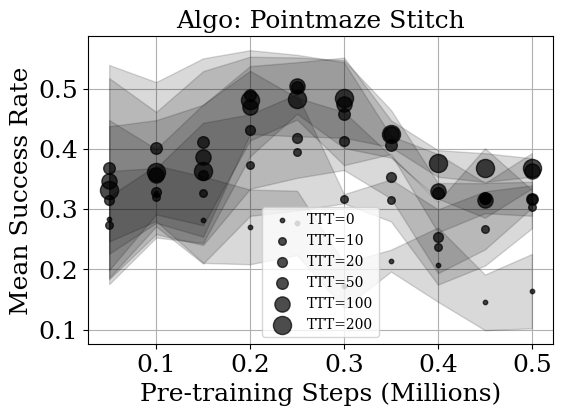

Group label: Antmaze Stitch
Group info: ['RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003']
num_seeds: 3, num_meta_steps: 10
Meta steps: 50000, Area under success curve: 0.6492333333333333
Meta steps: 100000, Area under success curve: 0.6742666666666666
Meta steps: 150000, Area under success curve: 0.6795999999999998
Meta steps: 200000, Area under success curve: 0.6578333333333333
Meta steps: 250000, Area under success curve: 0.6620333333333334
Meta steps: 300000, Area under success curve: 0.6555
Meta steps: 350000, Area under success curve: 0.675
Meta steps: 400000, Area under success curve: 0.6725666666666666
Meta steps: 450000, Area under success curve: 0.6634333333333333
Meta steps: 500000, Area under success curve: 0.6610666666666666


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


Saving figure to figures/Antmaze Stitch_metasteps.pdf


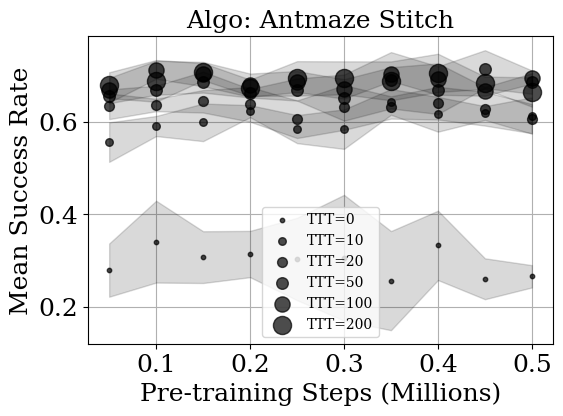

Group label: Humanoidmaze Stitch
Group info: ['RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003']
num_seeds: 3, num_meta_steps: 10
Meta steps: 50000, Area under success curve: 0.2636666666666666
Meta steps: 100000, Area under success curve: 0.3184666666666667
Meta steps: 150000, Area under success curve: 0.36016666666666663
Meta steps: 200000, Area under success curve: 0.3663
Meta steps: 250000, Area under success curve: 0.38363333333333327
Meta steps: 300000, Area under success curve: 0.3958
Meta steps: 350000, Area under success curve: 0.42179999999999995
Meta steps: 400000, Area under success curve: 0.41966666666666674
Meta steps: 450000, Area under success curve: 0.41629999999999995
Meta steps: 500000, Area under success curve: 0.4134333333333333


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


Saving figure to figures/Humanoidmaze Stitch_metasteps.pdf


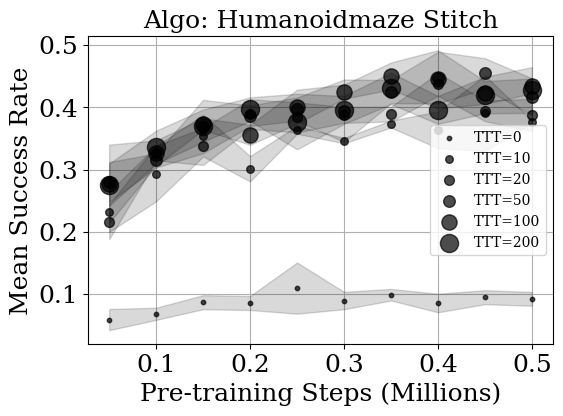

num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint Pointmaze Stitch: 0.47923333333333334 at meta_steps 250000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint Antmaze Stitch: 0.6795999999999998 at meta_steps 150000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint Humanoidmaze Stitch: 0.42179999999999995 at meta_steps 350000

Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
Antmaze Stitch                                      0.3080 ± 0.0558  0.5987 ± 0.0405  0.6440 ± 0.0242  0.6853 ± 0.0226  0.7027 ± 0.0262  0.7080 ± 0.0185              N/A
Humanoidmaze Stitch                                 0.0987 ± 0.0093  0.3733 ± 0

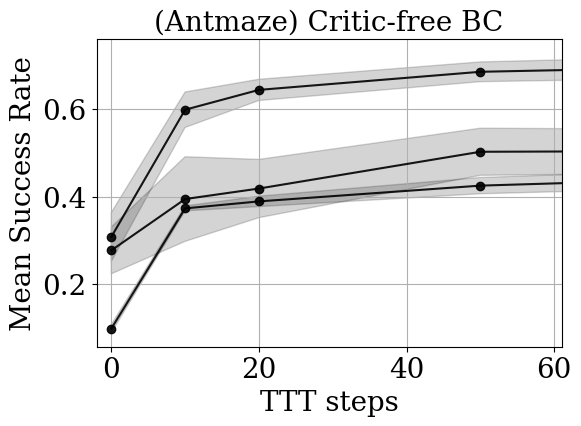

<Axes: title={'center': '(Antmaze) Critic-free BC'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [8]:
BASELINES = {

    "Pointmaze Stitch": {
        "groups": [
            "../../results/pointmaze_stitch/iql_ddpgbc/RANDOM-point_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },
    "Antmaze Stitch": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Humanoidmaze Stitch": {
        "groups": [
          "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
         ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

}

for run_name, run_info in BASELINES.items():
    plot_mean_success_over_checkpoints(
        {run_name: run_info},
        figure_path=f"figures/{run_name}_metasteps.pdf",
        new_style=True,
        is_pretraining=True,
    )

plot_max_overall_success_vs_ttt_steps(
    BASELINES,
    title="(Antmaze) Critic-free BC",
    print_table=True,
    xlim=(-2, 61),
    show_legend=False,
    use_best_auc_up_to=200,
)


Group label: Antmaze Stitch FOMAML
Group info: ['../../results/antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-FFAB-100-1-lr0.0003-ilr3e-05_finetune_lr1e-03']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.7070333333333332
Meta steps: 10000, Area under success curve: 0.7216
Meta steps: 15000, Area under success curve: 0.6997999999999999
Meta steps: 20000, Area under success curve: 0.6996000000000001
Meta steps: 25000, Area under success curve: 0.7162000000000001
Meta steps: 30000, Area under success curve: 0.7018666666666666
Meta steps: 35000, Area under success curve: 0.7152666666666667
Meta steps: 40000, Area under success curve: 0.7044333333333332
Meta steps: 45000, Area under success curve: 0.7086
Meta steps: 50000, Area under success curve: 0.7203666666666666


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


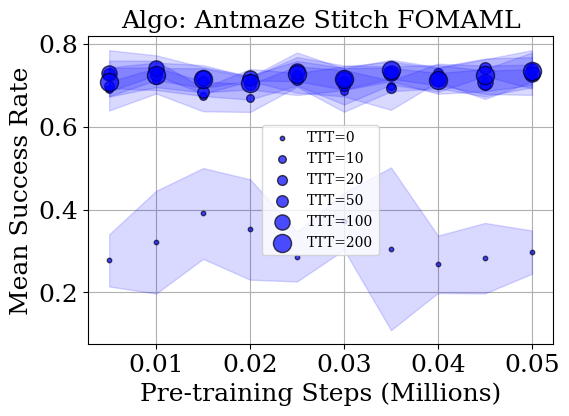

Group label: Antmaze Stitch Continual-TTT
Group info: ['../../results/antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-JTA-1-1-lr0.0003-ilr0.0003_finetune_lr1e-03']
num_seeds: 3, num_meta_steps: 11
Meta steps: 5000, Area under success curve: 0.6812
Meta steps: 10000, Area under success curve: 0.6980333333333334
Meta steps: 15000, Area under success curve: 0.6976333333333332
Meta steps: 20000, Area under success curve: 0.6887000000000001
Meta steps: 25000, Area under success curve: 0.6953333333333334
Meta steps: 30000, Area under success curve: 0.6880333333333334
Meta steps: 35000, Area under success curve: 0.7289000000000001
Meta steps: 40000, Area under success curve: 0.7061000000000002
Meta steps: 45000, Area under success curve: 0.7004333333333332
Meta steps: 50000, Area under success curve: 0.7049666666666665
Meta steps: 100000, Area under success curve: 0.7163333333333334


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


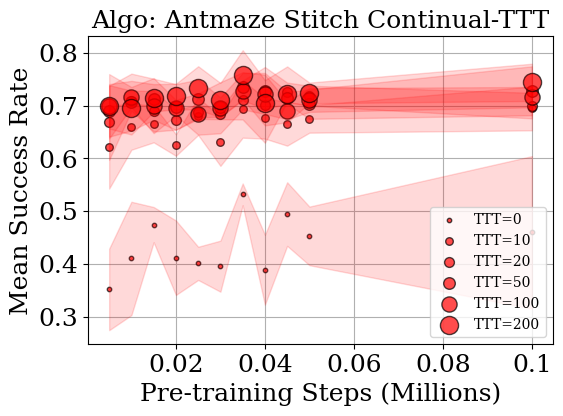

Group label: Antmaze Stitch Pretrained
Group info: ['../../results/antmaze_stitch/iql_ddpgbc/RANDOM-ant_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-03']
num_seeds: 3, num_meta_steps: 1
Meta steps: 400000, Area under success curve: 0.7039666666666667


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


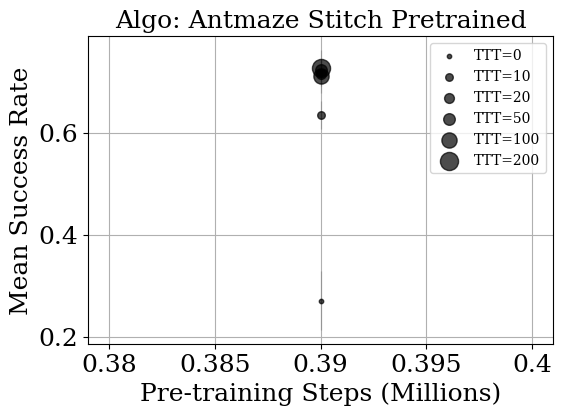

Group label: Antmaze Stitch Reptile eps=0.1
Group info: ['../../results/antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-RRAB-100-1-m_0.1-lr0.1-ilr0.0003']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.6623333333333333
Meta steps: 10000, Area under success curve: 0.6568999999999999
Meta steps: 15000, Area under success curve: 0.6582333333333332
Meta steps: 20000, Area under success curve: 0.6453
Meta steps: 25000, Area under success curve: 0.6483
Meta steps: 30000, Area under success curve: 0.6464333333333333
Meta steps: 35000, Area under success curve: 0.6462
Meta steps: 40000, Area under success curve: 0.6367666666666666
Meta steps: 45000, Area under success curve: 0.6495333333333333
Meta steps: 50000, Area under success curve: 0.6342


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


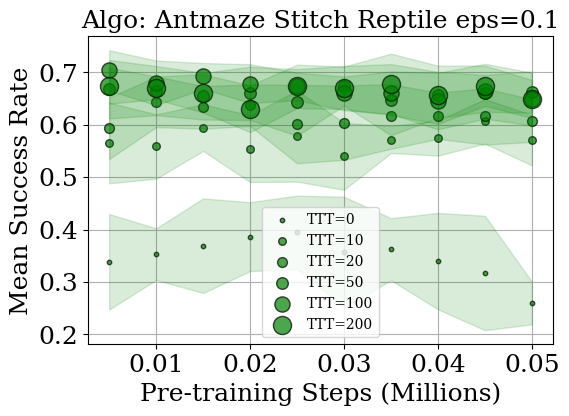

Group label: Antmaze Stitch Reptile eps=0.01
Group info: ['../../results/antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-RRAB-100-1-m_0.01-lr0.01-ilr0.0003']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.6621333333333334
Meta steps: 10000, Area under success curve: 0.6727666666666667
Meta steps: 15000, Area under success curve: 0.6604999999999999
Meta steps: 20000, Area under success curve: 0.6615666666666666
Meta steps: 25000, Area under success curve: 0.6614333333333333
Meta steps: 30000, Area under success curve: 0.6604333333333333
Meta steps: 35000, Area under success curve: 0.6607333333333333
Meta steps: 40000, Area under success curve: 0.6433666666666666
Meta steps: 45000, Area under success curve: 0.6538666666666666
Meta steps: 50000, Area under success curve: 0.6493000000000001


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


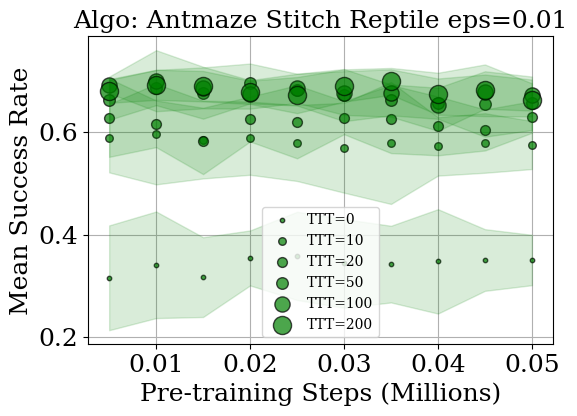

num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint Antmaze Stitch FOMAML: 0.7216 at meta_steps 10000
num_seeds: 3, num_meta_steps: 11
Area under success curve for best checkpoint Antmaze Stitch Continual-TTT: 0.7289000000000001 at meta_steps 35000
num_seeds: 3, num_meta_steps: 1
Area under success curve for best checkpoint Antmaze Stitch Pretrained: 0.7039666666666667 at meta_steps 400000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint Antmaze Stitch Reptile eps=0.1: 0.6623333333333333 at meta_steps 5000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint Antmaze Stitch Reptile eps=0.01: 0.6727666666666667 at meta_steps 10000

Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
----------------------------------------------------------------

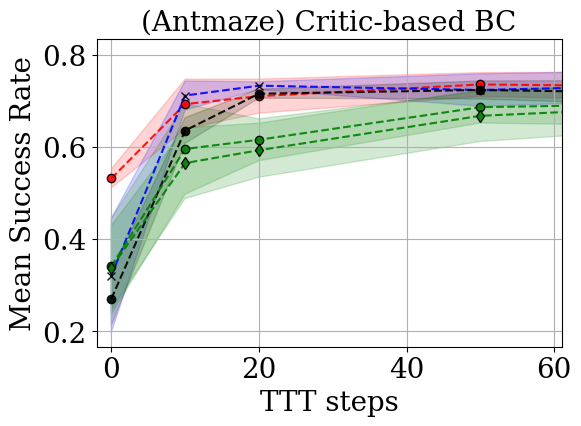

<Axes: title={'center': '(Antmaze) Critic-based BC'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [11]:
# New antmaze runs

BASELINES = {
    "Antmaze Stitch FOMAML": {
        "groups": [
            "../../results/antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-FFAB-100-1-lr0.0003-ilr3e-05_finetune_lr1e-03"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Antmaze Stitch Continual-TTT": {
        "groups": [
            "../../results/antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-JTA-1-1-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "red",
        "linestyle": "--",
    },

    "Antmaze Stitch Pretrained": {
        "groups": [
            "../../results/antmaze_stitch/iql_ddpgbc/RANDOM-ant_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "--",
    },

    "Antmaze Stitch Reptile eps=0.1": {
        "groups": [
            "../../results/antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-RRAB-100-1-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Antmaze Stitch Reptile eps=0.01": {
        "groups": [
            "../../results/antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-RRAB-100-1-m_0.01-lr0.01-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },

}

for run_name, run_info in BASELINES.items():
    plot_mean_success_over_checkpoints(
        {run_name: run_info},
        new_style=True,
        is_pretraining=True,
    )

plot_max_overall_success_vs_ttt_steps(
    BASELINES,
    title="(Antmaze) Critic-based BC",
    print_table=True,
    xlim=(-2, 61),
    show_legend=False,
    use_best_auc_up_to=200,
)


Group label: Pretrained
Group info: ['humanoidmaze_expert_bc/RANDOM-humanoid_exp-bc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-04_actor_lossbc']
num_seeds: 3, num_meta_steps: 2
Meta steps: 400000, Area under success curve: 0.11046666666666667
Meta steps: 1000000, Area under success curve: 0.12686666666666663


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


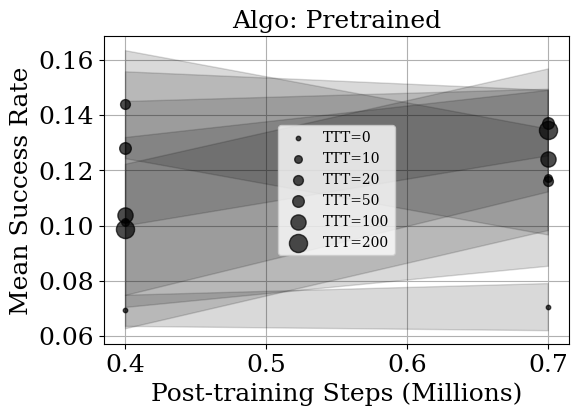

Group label: Continual-TTT
Group info: ['humanoidmaze_expert_bc/FT-ALL-humanoid_exp-bc-JTAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-05_actor_lossbc']
num_seeds: 3, num_meta_steps: 7
Meta steps: 20000, Area under success curve: 0.1929
Meta steps: 25000, Area under success curve: 0.19923333333333332
Meta steps: 30000, Area under success curve: 0.19363333333333332
Meta steps: 35000, Area under success curve: 0.19243333333333332
Meta steps: 40000, Area under success curve: 0.19246666666666667
Meta steps: 45000, Area under success curve: 0.18663333333333335
Meta steps: 50000, Area under success curve: 0.19623333333333334


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


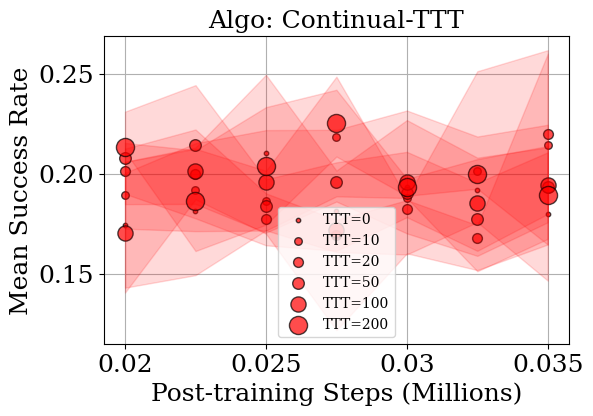

Group label: TT-FOMAML
Group info: ['humanoidmaze_expert_bc/FT-ALL-humanoid_exp-bc-FFAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-04_actor_lossbc']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.13746666666666665
Meta steps: 10000, Area under success curve: 0.15036666666666665
Meta steps: 15000, Area under success curve: 0.13296666666666662
Meta steps: 20000, Area under success curve: 0.14816666666666667
Meta steps: 25000, Area under success curve: 0.1504333333333333
Meta steps: 30000, Area under success curve: 0.14060000000000003
Meta steps: 35000, Area under success curve: 0.14366666666666666
Meta steps: 40000, Area under success curve: 0.15186666666666665
Meta steps: 45000, Area under success curve: 0.14329999999999998
Meta steps: 50000, Area under success curve: 0.1395333333333333


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


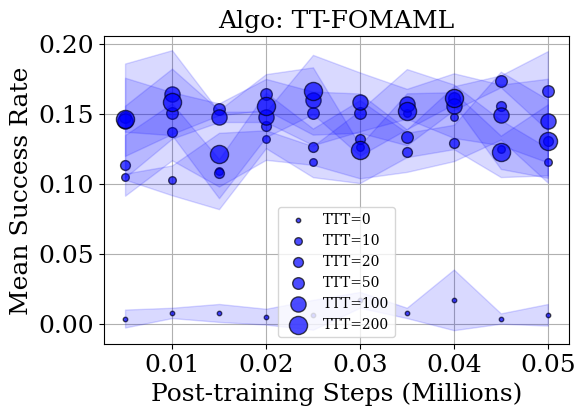

Group label: TT-Reptile
Group info: ['humanoidmaze_expert_bc/FT-ALL-humanoid_exp-bc-RRAB-100-1-m_0.5-lr0.5-ilr3e-05_finetune_lr3e-05_actor_lossbc']
num_seeds: 3, num_meta_steps: 7
Meta steps: 20000, Area under success curve: 0.18959999999999994
Meta steps: 25000, Area under success curve: 0.19066666666666665
Meta steps: 30000, Area under success curve: 0.19863333333333333
Meta steps: 35000, Area under success curve: 0.20079999999999998
Meta steps: 40000, Area under success curve: 0.20043333333333335
Meta steps: 45000, Area under success curve: 0.17976666666666666
Meta steps: 50000, Area under success curve: 0.2083333333333333


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


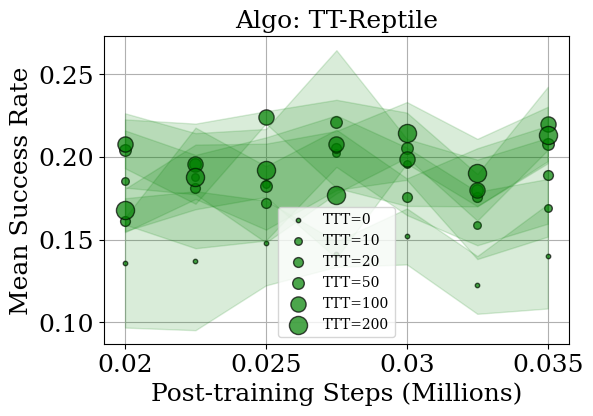

num_seeds: 3, num_meta_steps: 2
Area under success curve for best checkpoint Pretrained: 0.12686666666666663 at meta_steps 1000000
num_seeds: 3, num_meta_steps: 7
Area under success curve for best checkpoint Continual-TTT: 0.19923333333333332 at meta_steps 25000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint TT-FOMAML: 0.15186666666666665 at meta_steps 40000
num_seeds: 3, num_meta_steps: 7
Area under success curve for best checkpoint TT-Reptile: 0.2083333333333333 at meta_steps 50000

Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
Continual-TTT                                       0.1813 ± 0.0319  0.1920 ± 0.0206  0.2000 ± 0.0222  0.2147 ± 0.0296  0.2013 ± 0.0140  0.1

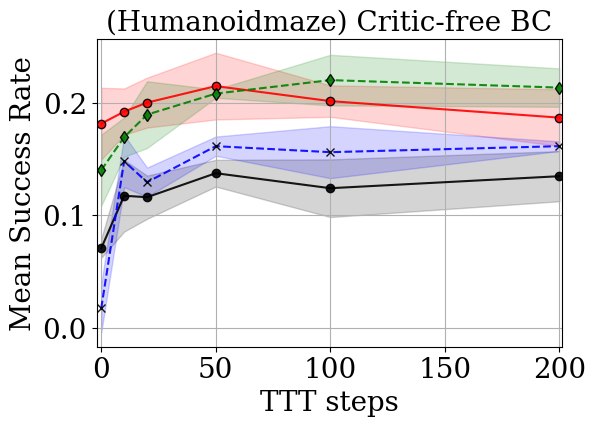

<Axes: title={'center': '(Humanoidmaze) Critic-free BC'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [44]:
HUMANOIDMAZE_BC_CRITIC_FREE = {
    "Pretrained": {
        "groups": [
            "humanoidmaze_expert_bc/RANDOM-humanoid_exp-bc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-04_actor_lossbc"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Continual-TTT": {
        "groups": [
            "humanoidmaze_expert_bc/FT-ALL-humanoid_exp-bc-JTAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-05_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
    },
    "TT-FOMAML": {
        "groups": [
            "humanoidmaze_expert_bc/FT-ALL-humanoid_exp-bc-FFAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-04_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },

    # Reorganized by epsilon (m_) and inner lr (ilr)
    # Assign each epsilon a color, and each ilr (fine-tune lr) a linestyle

    # epsilon -> color mapping
    # 0.01: 'purple'
    # 0.1:  'green'
    # 0.2:  'blue'
    # 0.5:  'red'
    # ilr    -> linestyle mapping
    # 0.0003: '-'
    # 3e-05:  '--'
    "TT-Reptile": {
        "groups": [
            "humanoidmaze_expert_bc/FT-ALL-humanoid_exp-bc-RRAB-100-1-m_0.5-lr0.5-ilr3e-05_finetune_lr3e-05_actor_lossbc",
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    }
}

for run_name, run_info in HUMANOIDMAZE_BC_CRITIC_FREE.items():
    plot_mean_success_over_checkpoints({run_name: run_info}, new_style=True)

plot_max_overall_success_vs_ttt_steps(
    HUMANOIDMAZE_BC_CRITIC_FREE,
    title="(Humanoidmaze) Critic-free BC",
    print_table=True,
    xlim=(-2, 201),
    figure_path="figures/humanoidmaze_bc_critic_free.pdf",
    show_legend=False,
    use_best_auc_up_to=200,
    )


Group label: Continual-TTT
Group info: ['FT-ALL-humanoidmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.0003']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.4890333333333334
Meta steps: 10000, Area under success curve: 0.5101
Meta steps: 15000, Area under success curve: 0.4985666666666667
Meta steps: 20000, Area under success curve: 0.4982000000000001
Meta steps: 25000, Area under success curve: 0.483
Meta steps: 30000, Area under success curve: 0.48443333333333344
Meta steps: 35000, Area under success curve: 0.4783666666666667
Meta steps: 40000, Area under success curve: 0.4862666666666666
Meta steps: 45000, Area under success curve: 0.4832333333333334
Meta steps: 50000, Area under success curve: 0.4895666666666667


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


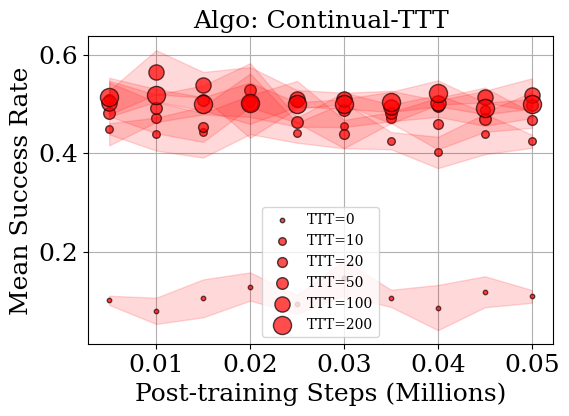

Group label: TT-FOMAML
Group info: ['FT-ALL-humanoidmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.0003']


num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.4174
Meta steps: 10000, Area under success curve: 0.4497666666666666
Meta steps: 15000, Area under success curve: 0.44410000000000005
Meta steps: 20000, Area under success curve: 0.46123333333333333
Meta steps: 25000, Area under success curve: 0.4718333333333334
Meta steps: 30000, Area under success curve: 0.47123333333333334
Meta steps: 35000, Area under success curve: 0.47513333333333335
Meta steps: 40000, Area under success curve: 0.4903
Meta steps: 45000, Area under success curve: 0.4894
Meta steps: 50000, Area under success curve: 0.49183333333333334


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


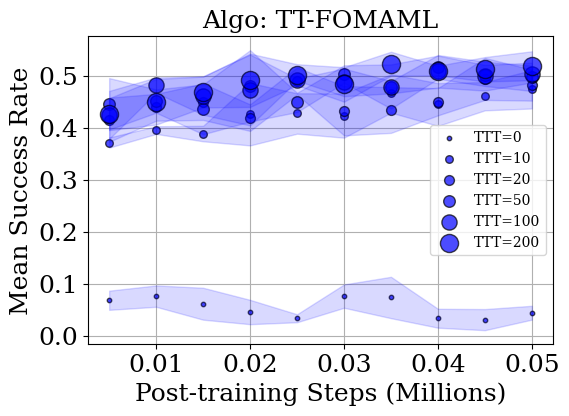

Group label: TT-Reptile
Group info: ['humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc']
num_seeds: 3, num_meta_steps: 7
Meta steps: 5000, Area under success curve: 0.6110666666666666
Meta steps: 10000, Area under success curve: 0.6239333333333333
Meta steps: 15000, Area under success curve: 0.6175333333333334
Meta steps: 20000, Area under success curve: 0.6171333333333333
Meta steps: 25000, Area under success curve: 0.6237666666666667
Meta steps: 30000, Area under success curve: 0.6149333333333332
Meta steps: 35000, Area under success curve: 0.6096


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


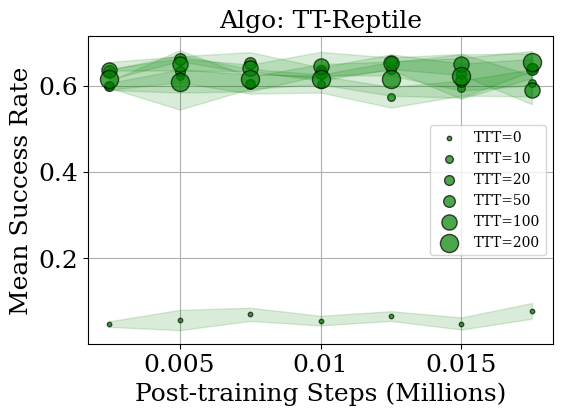

Group label: Pretrained
Group info: ['humanoidmaze_iql_ddpgbc/RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_actor_lossddpgbc']
num_seeds: 3, num_meta_steps: 1
Meta steps: 400000, Area under success curve: 0.46659999999999996


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


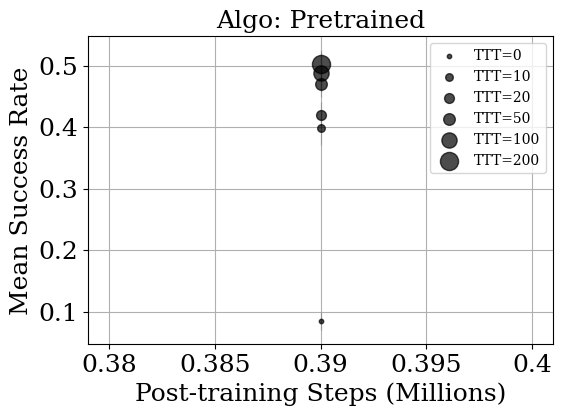

num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint Continual-TTT: 0.5101 at meta_steps 10000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint TT-FOMAML: 0.49183333333333334 at meta_steps 50000
num_seeds: 3, num_meta_steps: 7
Area under success curve for best checkpoint TT-Reptile: 0.6239333333333333 at meta_steps 10000
num_seeds: 3, num_meta_steps: 1
Area under success curve for best checkpoint Pretrained: 0.46659999999999996 at meta_steps 400000

Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
Continual-TTT                                       0.0800 ± 0.0267  0.4387 ± 0.0335  0.4720 ± 0.0316  0.4907 ± 0.0277  0.5640 ± 0.0448  0.5173 ± 0.0130 

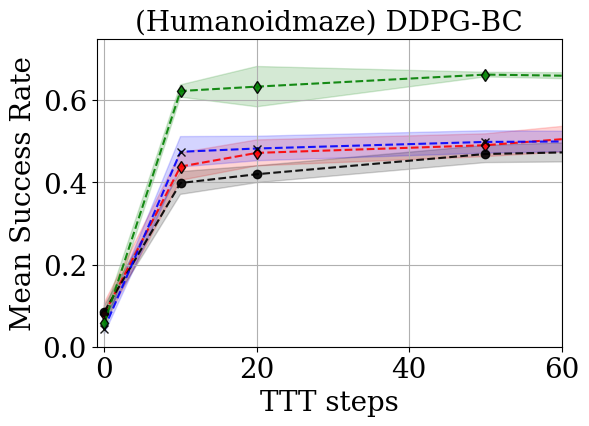

<Axes: title={'center': '(Humanoidmaze) DDPG-BC'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [47]:
HUMANOIDMAZE_JTA = {
    "Continual-TTT": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    #"Pretrained lr3e-04": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
    #    ],
    #    "color": "black",
    #    "linestyle": "--",
    #    "dot_type": "o",
    #},

    "TT-FOMAML": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },




    #"All: FT-JTA-actor 200-inner lr3e-04": {
    #    "groups": [
    #        "FT-ALL-humanoidmaze-ddpgbc-JTA-200-1-mc0.2-lr0.0003-ilr0.0003"
    #    ],
    #    "color": "purple",
    #    "linestyle": "-",
    #    "dot_type": "d",
    #},

    #"All: FT-Reptile-actor Best eps=0.15": {
    #    "groups": [
    #        "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.15-lr0.15-ilr0.0003"
    #    ],
    #    "color": "green",
    #    "linestyle": "-",
    #},

    "TT-Reptile": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },

    #"TT-Reptile": {
    #    "groups": [
    #        "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-50-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #    "dot_type": "d",
    #},

    "Pretrained": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    #"New Baseline Run Actor": {
    #    "groups": [
    #        "humanoidmaze_iql_ddpgbc/RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_actor_lossddpgbc_TTT_actor"
    #    ],
    #    "color": "black",
    #    "linestyle": "--",
    #    "dot_type": "d",
    #},


    #"All: FT-Reptile-actor Best eps=1.0": {
    #    "groups": [
    #        "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-lr1.0-ilr0.0003"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #    "dot_type": "o",
    #},
}

for run_name, run_info in HUMANOIDMAZE_JTA.items():
    plot_mean_success_over_checkpoints({run_name: run_info}, new_style=True)

plot_max_overall_success_vs_ttt_steps(
    HUMANOIDMAZE_JTA,
    title="(Humanoidmaze) DDPG-BC",
    xlim=(-1, 60),
    ylim=(0, 0.75),
    print_table=True,
    use_best_auc_up_to=200,
    legend_fontsize=18,
    show_legend=False,
    figure_path="figures/humanoidmaze_stitch_ddpgbc.pdf",
)

# GC-TTT Critic-based (Stitch datasets, GC-IQL-DDPGBC)

Group label: TT-Reptile
Group info: ['antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRAB-100-1-m_0.1-lr0.1-ilr3e-05_finetune_lr1e-03_actor_lossddpgbc']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.7014
Meta steps: 10000, Area under success curve: 0.6946000000000001
Meta steps: 15000, Area under success curve: 0.6836666666666666
Meta steps: 20000, Area under success curve: 0.6926666666666667
Meta steps: 25000, Area under success curve: 0.6918
Meta steps: 30000, Area under success curve: 0.6742666666666666
Meta steps: 35000, Area under success curve: 0.6813999999999999
Meta steps: 40000, Area under success curve: 0.6883333333333332
Meta steps: 45000, Area under success curve: 0.6964000000000001
Meta steps: 50000, Area under success curve: 0.6877


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


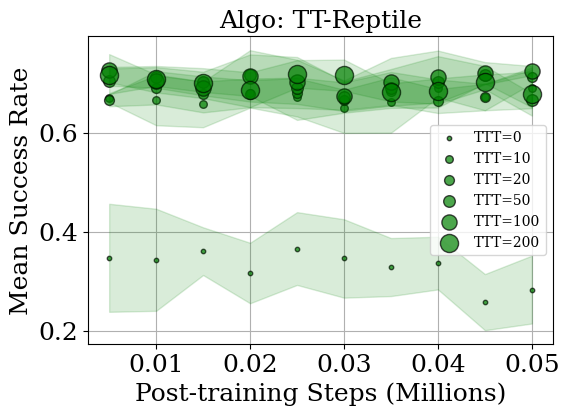

Group label: TT-Fomaml
Group info: ['antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFAB-100-1-lr0.0003-ilr3e-05_finetune_lr1e-03_actor_lossddpgbc']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.7090666666666666
Meta steps: 10000, Area under success curve: 0.7240000000000001
Meta steps: 15000, Area under success curve: 0.7362000000000001
Meta steps: 20000, Area under success curve: 0.7305333333333333
Meta steps: 25000, Area under success curve: 0.7249666666666666
Meta steps: 30000, Area under success curve: 0.7095666666666667
Meta steps: 35000, Area under success curve: 0.706
Meta steps: 40000, Area under success curve: 0.6979666666666666
Meta steps: 45000, Area under success curve: 0.7090666666666666
Meta steps: 50000, Area under success curve: 0.7043666666666667


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


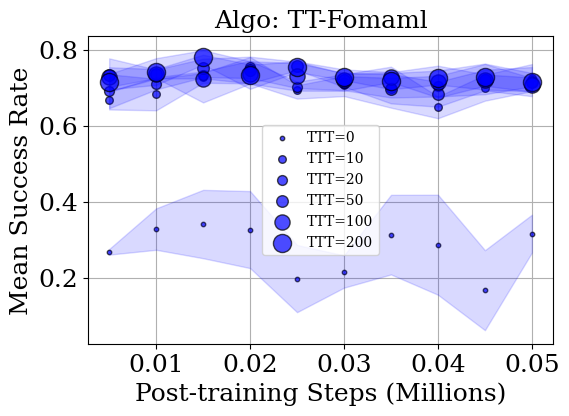

Group label: Continual-TTT
Group info: ['antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-JTAB-100-1-lr0.0003-ilr3e-05_finetune_lr1e-03_actor_lossddpgbc']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.7162333333333334
Meta steps: 10000, Area under success curve: 0.7309666666666667
Meta steps: 15000, Area under success curve: 0.7292666666666666
Meta steps: 20000, Area under success curve: 0.7116
Meta steps: 25000, Area under success curve: 0.7400333333333333
Meta steps: 30000, Area under success curve: 0.7175666666666666
Meta steps: 35000, Area under success curve: 0.7165
Meta steps: 40000, Area under success curve: 0.7300333333333333
Meta steps: 45000, Area under success curve: 0.72
Meta steps: 50000, Area under success curve: 0.7322666666666667


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


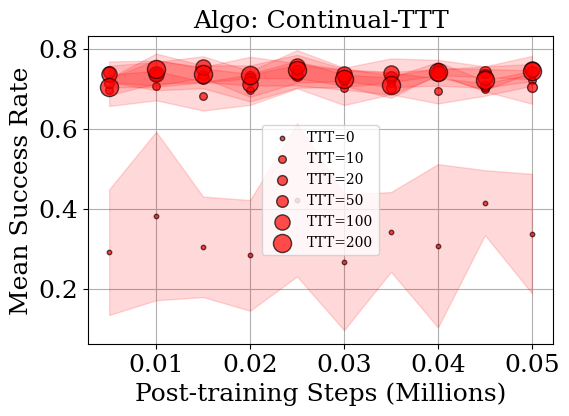

Group label: Pretrained
Group info: ['RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03']
num_seeds: 3, num_meta_steps: 1
Meta steps: 400000, Area under success curve: 0.6908333333333333


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


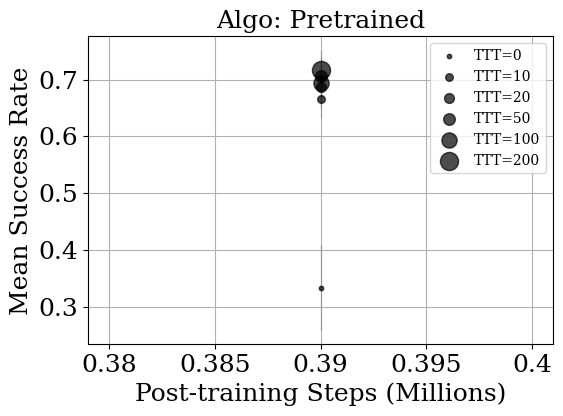

num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint TT-Reptile: 0.7014 at meta_steps 5000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint TT-Fomaml: 0.7362000000000001 at meta_steps 15000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint Continual-TTT: 0.7400333333333333 at meta_steps 25000
num_seeds: 3, num_meta_steps: 1
Area under success curve for best checkpoint Pretrained: 0.6908333333333333 at meta_steps 400000

Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
Continual-TTT                                       0.4227 ± 0.1914  0.7320 ± 0.0296  0.7493 ± 0.0217  0.7347 ± 0.0308  0.7573 ± 0.0405  0.7480 ± 0.0384   

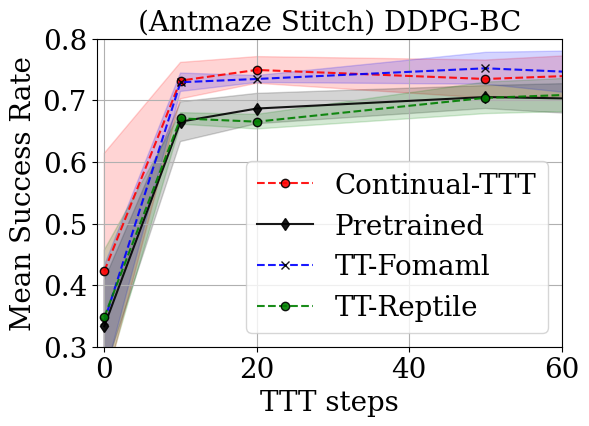

<Axes: title={'center': '(Antmaze Stitch) DDPG-BC'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [49]:
ANTMAZE_DDPGBC_BEST_LR = {
    "TT-Reptile": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRAB-100-1-m_0.1-lr0.1-ilr3e-05_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    #"All: FT-Reptile-actor best eps=0.01 lr1e-03": {
    #    "groups": [
    #        "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRAB-100-1-m_0.01-lr0.01-ilr3e-05_finetune_lr1e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #    "dot_type": "d",
    #},

    #"All: FT-Reptile-actor best eps=0.05 lr1e-03": {
    #    "groups": [
    #        "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRAB-100-1-m_0.05-lr0.05-ilr3e-05_finetune_lr1e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #    "dot_type": "x",
    #},


    #"All: FT-Reptile-actor best eps=0.2 lr1e-03": {
    #    "groups": [
    #        "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRAB-100-1-m_0.2-lr0.2-ilr3e-05_finetune_lr1e-03_actor_lossddpgbc"
    #    ],
    #    "color": "orange",
    #    "linestyle": "--",
    #    "dot_type": "P",
    #},


    #"All: FT-Reptile-actor best eps=0.5 lr1e-03": {
    #    "groups": [
    #        "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRAB-100-1-m_0.5-lr0.5-ilr3e-05_finetune_lr1e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #    "dot_type": "P",
    #},

    "TT-Fomaml": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFAB-100-1-lr0.0003-ilr3e-05_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Continual-TTT": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-JTAB-100-1-lr0.0003-ilr3e-05_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "red",
        "linestyle": "--",
    },

    "Pretrained": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

}

for run_name, run_info in ANTMAZE_DDPGBC_BEST_LR.items():
    plot_mean_success_over_checkpoints({run_name: run_info}, new_style=True)

plot_max_overall_success_vs_ttt_steps(
    ANTMAZE_DDPGBC_BEST_LR,
    title="(Antmaze Stitch) DDPG-BC",
    ylim=(0.3, 0.8),
    xlim=(-1, 60),
    print_table=True,
    use_best_auc_up_to=200,
    figure_path="figures/antmaze_stitch_ddpgbc.pdf",
    fontsize=20,
)

num_seeds: 3, num_meta_steps: 1
Area under success curve for best checkpoint All: FT-Reptile-actor best eps=0.1 lr3e-04: 0.6826000000000001 at meta_steps 50000
num_seeds: 3, num_meta_steps: 1
Area under success curve for best checkpoint All: FT-Fomaml-actor best lr3e-04: 0.7055666666666667 at meta_steps 50000
num_seeds: 3, num_meta_steps: 1
Area under success curve for best checkpoint All: FT-JT-actor best lr3e-04: 0.7180333333333331 at meta_steps 50000
num_seeds: 3, num_meta_steps: 1
Area under success curve for best checkpoint Pretrained lr3e-04: 0.6725666666666666 at meta_steps 400000

Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
All: FT-Fomaml-actor best lr3e-04                   0.3160 ± 0.05

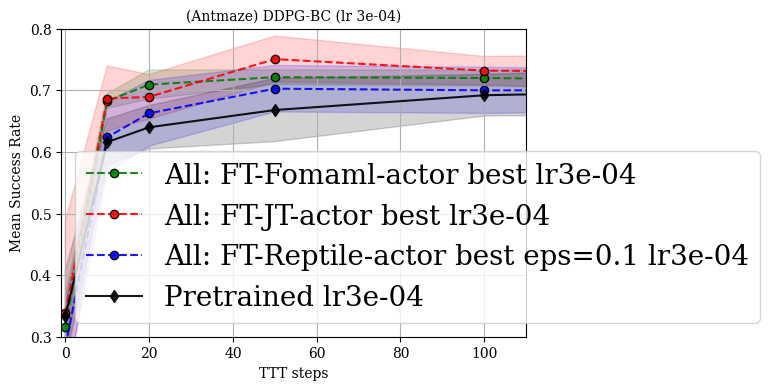

<Axes: title={'center': '(Antmaze) DDPG-BC (lr 3e-04)'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [20]:
from importlib import reload
import utils.plotting
reload(utils.plotting)
from utils.plotting import plot_max_overall_success_vs_ttt_steps

ANTMAZE_DDPGBC = {
    "All: FT-Reptile-actor best eps=0.1 lr3e-04": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRAB-100-1-m_0.1-lr0.1-ilr3e-05_finetune_lr3e-04_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-Fomaml-actor best lr3e-04": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-04_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-JT-actor best lr3e-04": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-JTAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-04_actor_lossddpgbc"
        ],
        "color": "red",
        "linestyle": "--",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

}

for run_name, run_info in ANTMAZE_DDPGBC.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(
    ANTMAZE_DDPGBC,
    title="(Antmaze) DDPG-BC (lr 3e-04)",
    xlim=(-1, 110),
    ylim=(0.3, 0.8),
    print_table=True,
    fontsize=10,
    use_best_auc_up_to=200,
)

# Baselines 
For the three datsets,

Try both DDPG-BC and BC with the following learning rates:
- [3e-05, 3e-04, 5e-04, 1e-03, 3e-03, 4e-03, 1e-02]
- Report the best learning rate(s) for each policy extraction objective.


num_seeds: 3, num_meta_steps: 1
Area under success curve for DDPG-BC ($3 \times 10^{-4}$): 0.31620000000000004
num_seeds: 2, num_meta_steps: 1
Area under success curve for DDPG-BC ($5 \times 10^{-3}$): 0.55
num_seeds: 3, num_meta_steps: 1
Area under success curve for BC ($3 \times 10^{-3}$): 0.9019666666666666

Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
BC ($3 \times 10^{-3}$)                             0.2080 ± 0.0617  0.9013 ± 0.0343  0.9453 ± 0.0113  0.9533 ± 0.0140  0.9053 ± 0.0349  0.9080 ± 0.0391              N/A
DDPG-BC ($3 \times 10^{-4}$)                        0.2080 ± 0.0617  0.2067 ± 0.0781  0.2720 ± 0.0450  0.3040 ± 0.0692  0.3360 ± 0.0256  0.3467 ± 0.0217              N/A
DDPG-BC 

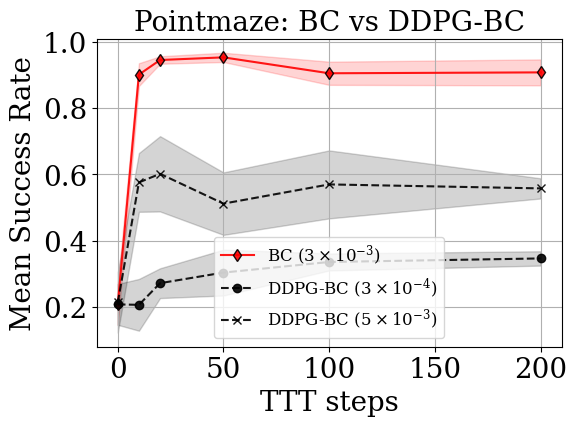

<Axes: title={'center': 'Pointmaze: BC vs DDPG-BC'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [4]:
# Pointmaze BASELINES
POINTMAZE_BASELINES = {
    "DDPG-BC ($3 \\times 10^{-4}$)": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    #"Pretrained lr5e-04": {
    #    "groups": [
    #        "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "o",
    #},

    #"Pretrained lr1e-03": {
    #    "groups": [
    #        "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
    #    ],
    #    "color": "black",
    #    "linestyle": "--",
    #    "dot_type": "d",
    #},

    #"Pretrained lr3e-03": {
    #    "groups": [
    #        "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "d",
    #},

    "DDPG-BC ($5 \\times 10^{-3}$)": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "x",
    },

    #"Pretrained lr1e-02": {
    #    "groups": [
    #        "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "x",
    #},

    #"Pretrained BC lr3e-04": {
    #    "groups": [
    #        "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "--",
    #},

    #"Pretrained BC lr5e-04": {
    #    "groups": [
    #        "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "-",
    #    "dot_type": "o",
    #},

    #"Pretrained BC lr1e-03": {
    #    "groups": [
    #        "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "--",
    #    "dot_type": "d",
    #},

    "BC ($3 \\times 10^{-3}$)": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "d",
    },

    #"Pretrained BC lr5e-03": {
    #    "groups": [
    #        "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "--",
    #    "dot_type": "x",
    #},

    #"Pretrained BC lr1e-02": {
    #    "groups": [
    #        "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "-",
    #    "dot_type": "x",
    #}
}

plot_max_overall_success_vs_ttt_steps(
    POINTMAZE_BASELINES,
    title="Pointmaze: BC vs DDPG-BC",
    print_table=True,
    fontsize=20,
    legend_fontsize=12,
    figure_path="figures/pointmaze_bc_vs_ddpgbc.pdf"
)

num_seeds: 3, num_meta_steps: 1
Area under success curve for ilr1e-03: 0.7039666666666667
num_seeds: 3, num_meta_steps: 1
Area under success curve for ilr1e-04: 0.6208666666666666
num_seeds: 3, num_meta_steps: 1
Area under success curve for ilr3e-03: 0.6605666666666667
num_seeds: 3, num_meta_steps: 1
Area under success curve for ilr3e-04: 0.6733666666666666
num_seeds: 3, num_meta_steps: 1
Area under success curve for ilr3e-05: 0.5425

Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
ilr1e-03                                            0.2707 ± 0.0580  0.6360 ± 0.0279  0.7160 ± 0.0098  0.7240 ± 0.0196  0.7120 ± 0.0339  0.7280 ± 0.0353              N/A
ilr1e-04                                            

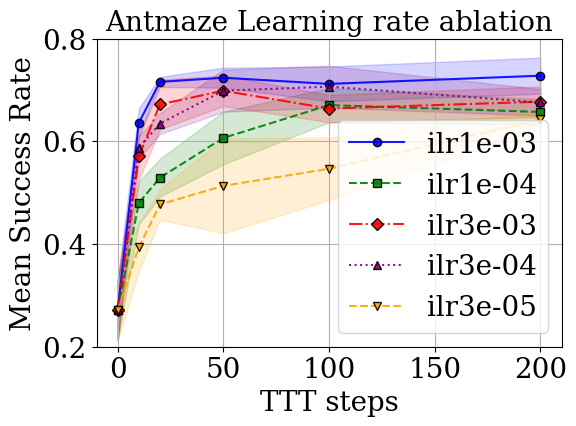

<Axes: title={'center': 'Antmaze Learning rate ablation'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [24]:
ANTMAZE_STITCH_ILR_ABLATION = {
    "ilr1e-03": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/RANDOM-ant_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "o",
    },
    "ilr1e-04": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/RANDOM-ant_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-04"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "s",
    },
    "ilr3e-03": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/RANDOM-ant_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "red",
        "linestyle": "-.",
        "dot_type": "D",
    },
    "ilr3e-04": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/RANDOM-ant_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-04"
        ],
        "color": "purple",
        "linestyle": ":",
        "dot_type": "^",
    },
    "ilr3e-05": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/RANDOM-ant_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-05"
        ],
        "color": "orange",
        "linestyle": "--",
        "dot_type": "v",
    },
}

plot_max_overall_success_vs_ttt_steps(
    ANTMAZE_STITCH_ILR_ABLATION,
    title="Antmaze Learning rate ablation",
    print_table=True,
    root_dir="../results",
    ylim=(0.2, 0.8)
)

num_seeds: 3, num_meta_steps: 1
Area under success curve for ilr1e-03: 0.4047
num_seeds: 3, num_meta_steps: 1
Area under success curve for ilr1e-04: 0.4782
num_seeds: 3, num_meta_steps: 1
Area under success curve for ilr3e-03: 0.02746666666666666
num_seeds: 3, num_meta_steps: 1
Area under success curve for ilr3e-04: 0.48186666666666667
num_seeds: 3, num_meta_steps: 1


Area under success curve for ilr3e-05: 0.4363666666666667

Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
ilr1e-03                                            0.0947 ± 0.0226  0.3480 ± 0.0303  0.4107 ± 0.0299  0.4160 ± 0.0353  0.4400 ± 0.0279  0.3827 ± 0.0272              N/A
ilr1e-04                                            0.0947 ± 0.0226  0.3947 ± 0.0204  0.4600 ± 0.0328  0.4680 ± 0.0400  0.4920 ± 0.0353  0.5280 ± 0.0450              N/A
ilr3e-03                                            0.0947 ± 0.0226  0.0027 ± 0.0043  0.0133 ± 0.0077  0.0307 ± 0.0056  0.0333 ± 0.0149  0.0200 ± 0.0128              N/A
ilr3e-04                                            0.0933 ± 0.0223  0.4347 ± 0.0359  0.4733

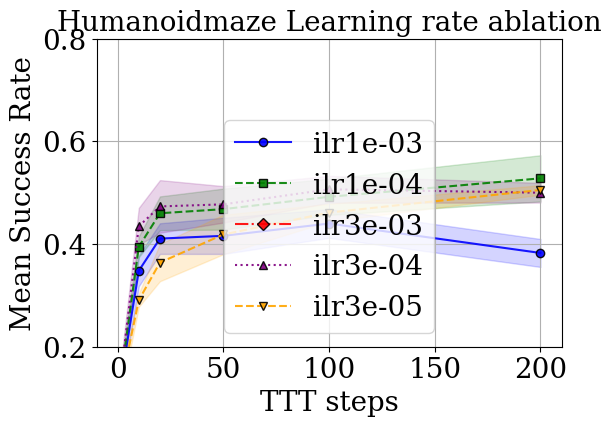

<Axes: title={'center': 'Humanoidmaze Learning rate ablation'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [25]:
HUMANOIDMAZE_STITCH_ILR_ABLATION = {
    "ilr1e-03": {
        "groups": [
            "humanoidmaze_stitch/iql_ddpgbc/RANDOM-humanoid_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "o",
    },
    "ilr1e-04": {
        "groups": [
            "humanoidmaze_stitch/iql_ddpgbc/RANDOM-humanoid_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-04"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "s",
    },
    "ilr3e-03": {
        "groups": [
            "humanoidmaze_stitch/iql_ddpgbc/RANDOM-humanoid_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "red",
        "linestyle": "-.",
        "dot_type": "D",
    },
    "ilr3e-04": {
        "groups": [
            "humanoidmaze_stitch/iql_ddpgbc/RANDOM-humanoid_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-04"
        ],
        "color": "purple",
        "linestyle": ":",
        "dot_type": "^",
    },
    "ilr3e-05": {
        "groups": [
            "humanoidmaze_stitch/iql_ddpgbc/RANDOM-humanoid_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-05"
        ],
        "color": "orange",
        "linestyle": "--",
        "dot_type": "v",
    },
}

plot_max_overall_success_vs_ttt_steps(
    HUMANOIDMAZE_STITCH_ILR_ABLATION,
    title="Humanoidmaze Learning rate ablation",
    print_table=True,
    root_dir="../results",
    ylim=(0.2, 0.8)
)

num_seeds: 3, num_meta_steps: 1
Area under success curve for ilr1e-03: 0.4086333333333333
num_seeds: 3, num_meta_steps: 1
Area under success curve for ilr1e-04: 0.2761333333333333
num_seeds: 3, num_meta_steps: 1
Area under success curve for ilr3e-03: 0.5330333333333335
num_seeds: 3, num_meta_steps: 1
Area under success curve for ilr3e-04: 0.3257333333333334
num_seeds: 3, num_meta_steps: 1
Area under success curve for ilr3e-05: 0.21446666666666667

Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
ilr1e-03                                            0.2080 ± 0.0315  0.3640 ± 0.0420  0.3867 ± 0.0171  0.4120 ± 0.0147  0.4227 ± 0.0257  0.4227 ± 0.0415              N/A
ilr1e-04                               

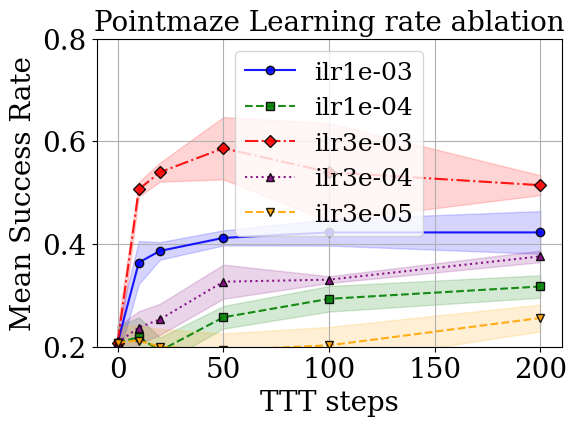

<Axes: title={'center': 'Pointmaze Learning rate ablation'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [23]:
POINTMAZE_STITCH_ILR_ABLATION = {
    "ilr1e-03": {
        "groups": [
            "pointmaze_stitch/iql_ddpgbc/RANDOM-point_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "o",
    },
    "ilr1e-04": {
        "groups": [
            "pointmaze_stitch/iql_ddpgbc/RANDOM-point_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-04"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "s",
    },
    "ilr3e-03": {
        "groups": [
            "pointmaze_stitch/iql_ddpgbc/RANDOM-point_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "red",
        "linestyle": "-.",
        "dot_type": "D",
    },
    "ilr3e-04": {
        "groups": [
            "pointmaze_stitch/iql_ddpgbc/RANDOM-point_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-04"
        ],
        "color": "purple",
        "linestyle": ":",
        "dot_type": "^",
    },
    "ilr3e-05": {
        "groups": [
            "pointmaze_stitch/iql_ddpgbc/RANDOM-point_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-05"
        ],
        "color": "orange",
        "linestyle": "--",
        "dot_type": "v",
    },
}

plot_max_overall_success_vs_ttt_steps(
    POINTMAZE_STITCH_ILR_ABLATION,
    title="Pointmaze Learning rate ablation",
    print_table=True,
    root_dir="../results",
    ylim=(0.2, 0.8)
)

num_seeds: 3, num_meta_steps: 1
Area under success curve for DDPG-BC ($3 \times 10^{-4}$): 0.6725666666666666
num_seeds: 3, num_meta_steps: 1
Area under success curve for DDPG-BC ($10^{-3}$): 0.6908333333333333
num_seeds: 3, num_meta_steps: 1
Area under success curve for BC ($10^{-3}$): 0.7151666666666665

Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
BC ($10^{-3}$)                                      0.3333 ± 0.0748  0.7280 ± 0.0480  0.7467 ± 0.0343  0.7413 ± 0.0246  0.7080 ± 0.0231  0.7280 ± 0.0161              N/A
DDPG-BC ($10^{-3}$)                                 0.3333 ± 0.0748  0.6653 ± 0.0323  0.6867 ± 0.0246  0.7053 ± 0.0186  0.6947 ± 0.0447  0.7160 ± 0.0356              N/A
DDPG-BC ($3 \

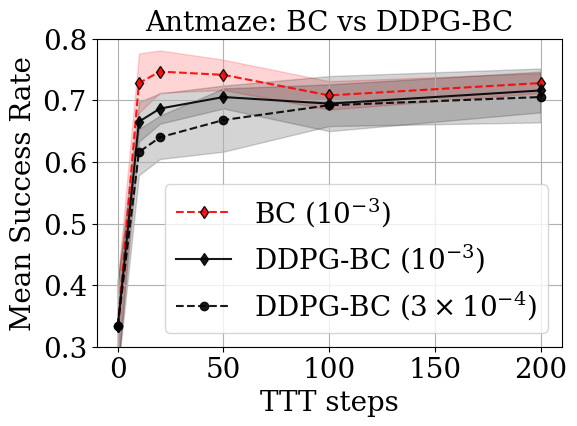

<Axes: title={'center': 'Antmaze: BC vs DDPG-BC'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [5]:
# Look at the baseline first
# Look at different learning rates


ANTMAZE_BASELINE = {
    "DDPG-BC ($3 \\times 10^{-4}$)": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    #"Pretrained lr5e-04": {
    #    "groups": [
    #        "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "o",
    #},

    "DDPG-BC ($10^{-3}$)": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    #"Pretrained lr3e-03": {
    #    "groups": [
    #        "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "X",
    #},

    #"Pretrained lr5e-03": {
    #    "groups": [
    #        "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "o",
    #},

    #"Pretrained lr1e-02": {
    #    "groups": [
    #        "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "d",
    #},

    #"Pretrained BC lr3e-04": {
    #    "groups": [
    #        "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "--",
    #},

    #"Pretrained BC lr5e-04": {
    #    "groups": [
    #        "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "-",
    #    "dot_type": "o",
    #},

    "BC ($10^{-3}$)": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    #"Pretrained BC lr3e-03": {
    #    "groups": [
    #        "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "-",
    #    "dot_type": "d",
    #},

    #"Pretrained BC lr5e-03": {
    #    "groups": [
    #        "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "--",
    #    "dot_type": "x",
    #}
}
plot_max_overall_success_vs_ttt_steps(
    ANTMAZE_BASELINE,
    title="Antmaze: BC vs DDPG-BC",
    ylim=(0.3, 0.8),
    print_table=True,
    figure_path="figures/antmaze_bc_vs_ddpgbc.pdf"
)

num_seeds: 3, num_meta_steps: 1
Area under success curve for DDPG-BC $3 \times 10^{-4}$: 0.41966666666666674
num_seeds: 3, num_meta_steps: 1
Area under success curve for BC $3 \times 10^{-4}$: 0.38010000000000005

Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
BC $3 \times 10^{-4}$                               0.0853 ± 0.0149  0.3560 ± 0.0412  0.3560 ± 0.0320  0.4120 ± 0.0169  0.3853 ± 0.0310  0.3907 ± 0.0171              N/A
DDPG-BC $3 \times 10^{-4}$                          0.0853 ± 0.0149  0.3640 ± 0.0296  0.4373 ± 0.0182  0.4480 ± 0.0416  0.4453 ± 0.0468  0.3960 ± 0.0225              N/A

Saving figure to figures/humanoidmaze_bc_vs_ddpgbc.pdf


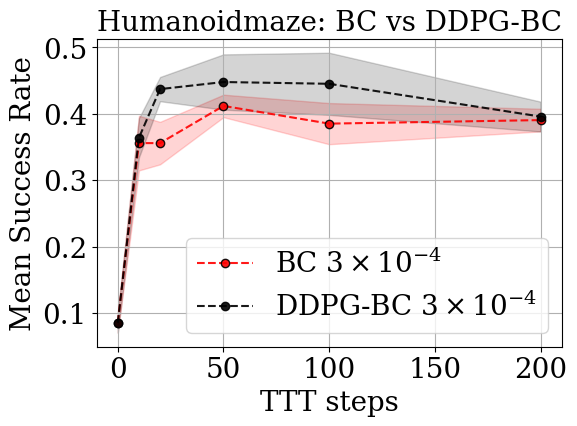

<Axes: title={'center': 'Humanoidmaze: BC vs DDPG-BC'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [6]:
HUMANOIDMAZE_DDPGBC_BC = {

    "DDPG-BC $3 \\times 10^{-4}$": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    #"Pretrained lr5e-04": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "o",
    #},

    #"Pretrained lr1e-03": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
    #    ],
    #    "color": "black",
    #    "linestyle": "--",
    #    "dot_type": "d",
    #},

    #"Pretrained lr3e-03": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "d",
    #},

    #"Pretrained lr5e-03": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
    #    ],
    #    "color": "black",
    #    "linestyle": "--",
    #    "dot_type": "x",
    #},

    #"Pretrained lr1e-02": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "x",
    #},

    "BC $3 \\times 10^{-4}$": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-04_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "o",
    },

    #"Pretrained BC lr5e-04": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "-",
    #    "dot_type": "o",
    #},

    #"Pretrained BC lr1e-03": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "--",
    #    "dot_type": "d",
    #},

    #"Pretrained BC lr3e-03": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "-",
    #    "dot_type": "d",
    #},

    #"Pretrained BC lr3e-05": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-05_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "blue",
    #    "linestyle": "--",
    #    "dot_type": "x",
    #},

    #"Pretrained BC lr5e-05": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-05_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "blue",
    #    "linestyle": "-",
    #    "dot_type": "x",
    #},

    #"Pretrained BC lr1e-04": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-04_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "blue",
    #    "linestyle": "--",
    #    "dot_type": "o",
    #}
}
plot_max_overall_success_vs_ttt_steps(
    HUMANOIDMAZE_DDPGBC_BC,
    title="Humanoidmaze: BC vs DDPG-BC",
    print_table=True,
    figure_path="figures/humanoidmaze_bc_vs_ddpgbc.pdf"
)

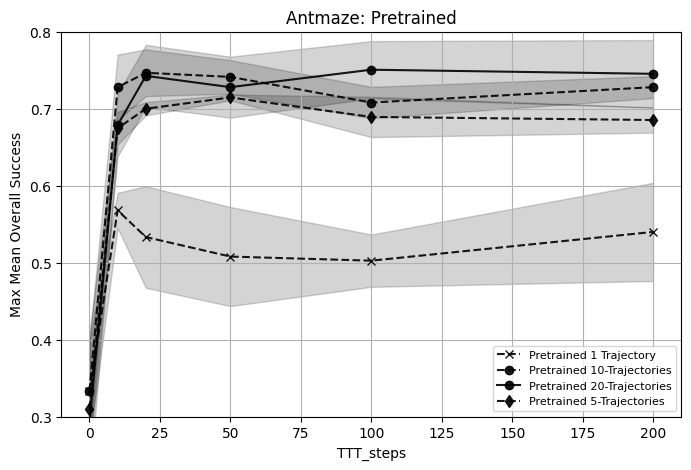

<Axes: title={'center': 'Antmaze: Pretrained'}, xlabel='TTT_steps', ylabel='Max Mean Overall Success'>

In [7]:
# Now, with the fixed learning rate (3e-04)
# Look at different num_trajectories used
# Look at the baseline first
# Look at different learning rates
ANTMAZE_BASELINE_TRAJ = {
    "Pretrained 1 Trajectory": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_actor_lossbc_traj_1"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Pretrained 5-Trajectories": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_actor_lossbc_traj_5"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "d",
    },
    "Pretrained 10-Trajectories": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "Pretrained 20-Trajectories": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_actor_lossbc_traj_20"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },
}
plot_max_overall_success_vs_ttt_steps(ANTMAZE_BASELINE_TRAJ, reset=False, title="Antmaze: Pretrained", ylim=(0.3, 0.8))

## Joint-training vs Fomaml vs Reptile
We assess the performance of such algorithms on the two more difficult datsets.


num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint TT-FOMAML: 0.3678666666666667 at meta_steps 5000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint TT-Reptile: 0.4379333333333333 at meta_steps 20000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint Continual-TTT: 0.27380000000000004 at meta_steps 35000
num_seeds: 2, num_meta_steps: 1
Area under success curve for best checkpoint Pretrained: 0.55 at meta_steps 400000

Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
Continual-TTT                                       0.0160 ± 0.0256  0.0813 ± 0.0777  0.1653 ± 0.1006  0.2907 ± 0.0918  0.2933 ± 0.0653  0.3387 ± 0.0085    

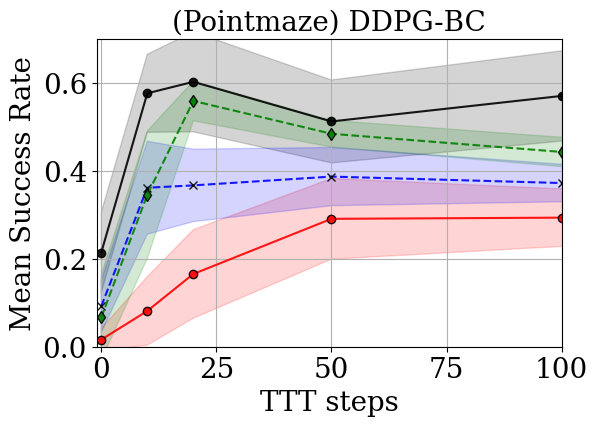

<Axes: title={'center': '(Pointmaze) DDPG-BC'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [7]:
# Pointmaze

POINTMAZE_STITCH_DDPGBC_BEST_LR = {
    #"FT-FOMAML 1-inner": {
    #    "groups": [
    #        "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-FFA-1-1-lr0.0003-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},
    #"FT-FOMAML 5-inner": {
    #    "groups": [
    #        "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-FFA-5-1-lr0.0003-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},
    "TT-FOMAML": {
        "groups": [
            "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-FFA-10-1-lr0.0003-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },
    #"FT-FOMAML 20-inner": {
    #    "groups": [
    #        "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-FFA-20-1-lr0.0003-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},
    #"FT-FOMAML 50-inner": {
    #    "groups": [
    #        "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-FFA-50-1-lr0.0003-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},
    #"FT-FOMAML 100-inner": {
    #    "groups": [
    #        "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-FFA-100-1-lr0.0003-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},
    #"FT-FOMAML 200-inner": {
    #    "groups": [
    #        "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-FFA-200-1-lr0.0003-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},

    "TT-Reptile": {
        "groups": [
            "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-RRA-1-1-m_0.1-lr0.1-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },
    #"FT-Reptile 5 eps=0.1": {
    #    "groups": [
    #        "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-RRA-5-1-m_0.1-lr0.1-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},
    #"FT-Reptile 10 eps=0.1": {
    #    "groups": [
    #        "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-RRA-10-1-m_0.1-lr0.1-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},
    #"FT-Reptile 20 eps=0.1": {
    #    "groups": [
    #        "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-RRA-20-1-m_0.1-lr0.1-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},
    #"FT-Reptile 50 eps=0.1": {
    #    "groups": [
    #        "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-RRA-50-1-m_0.1-lr0.1-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},
    #"FT-Reptile 100 eps=0.1": {
    #    "groups": [
    #        "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-RRA-100-1-m_0.1-lr0.1-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},
    #"FT-Reptile 200 eps=0.1": {
    #    "groups": [
    #        "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-RRA-200-1-m_0.1-lr0.1-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},

    #"FT-Continual 1-inner": {
    #    "groups": [
    #        "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-JTA-1-1-lr0.0003-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},
    #"FT-Continual 5-inner": {
    #    "groups": [
    #        "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-JTA-5-1-lr0.0003-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},
    #"FT-Continual 10-inner": {
    #    "groups": [
    #        "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-JTA-10-1-lr0.0003-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},
    #"FT-Continual 20-inner": {
    #    "groups": [
    #        "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-JTA-20-1-lr0.0003-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},
    "Continual-TTT": {
        "groups": [
            "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-JTA-50-1-lr0.0003-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
        ],
        "color": "red",
    },
    #"FT-Continual 100-inner": {
    #    "groups": [
    #        "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-JTA-100-1-lr0.0003-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},
    #"FT-Continual 200-inner": {
    #    "groups": [
    #        "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-JTA-200-1-lr0.0003-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},

    "Pretrained": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },
}

for run_name, run_info in POINTMAZE_STITCH_DDPGBC_BEST_LR.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info}, new_style=True)

plot_max_overall_success_vs_ttt_steps(
    POINTMAZE_STITCH_DDPGBC_BEST_LR,
    title="(Pointmaze) DDPG-BC",
    figure_path="figures/pointmaze_stitch_ddpgbc.pdf",
    ylim=(0.0, 0.7),
    xlim=(-1, 100),
    use_best_auc_up_to=200,
    print_table=True,
    show_legend=False,
    fontsize=20
)

num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint TT-reptile 1-inner: 0.4856333333333333 at meta_steps 5000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint TT-reptile 5-inner: 0.6226999999999999 at meta_steps 45000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint TT-reptile 10-inner: 0.6302666666666668 at meta_steps 5000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint FT-Continual 20-inner: 0.6339666666666666 at meta_steps 5000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint TT-reptile 50-inner: 0.6406333333333333 at meta_steps 20000
num_seeds: 3, num_meta_steps: 9
Area under success curve for best checkpoint TT-reptile 100-inner: 0.6356333333333333 at meta_steps 5000
num_seeds: 3, num_meta_steps: 6
Area under success curve for best checkpoint TT-REptile 200-inner: 0.5326666666666666 at meta_steps 5000
num_seeds: 3, num_meta_steps: 7
Area un

AssertionError: Expected 1 value for TTT_steps 200

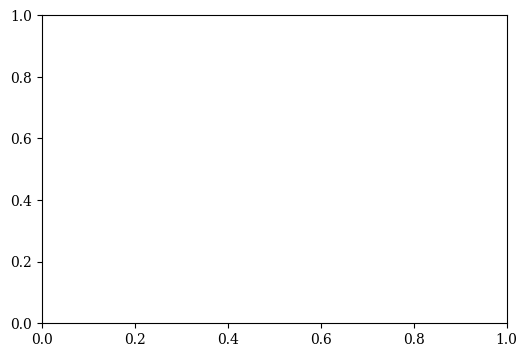

In [ ]:
HUMANOIDMAZE_DDPGBC_BEST_LR = {
    "TT-reptile 1-inner": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-1-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "purple",
        "linestyle": "--",
    },
    "TT-reptile 5-inner": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-5-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "purple",
        "linestyle": "--",
    },
    "TT-reptile 10-inner": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-10-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "purple",
        "linestyle": "--",
    },
    "TT-reptile 20-inner": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-20-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "purple",
        "linestyle": "--",
    },
    "TT-reptile 50-inner": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-50-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "purple",
        "linestyle": "--",
    },
    "TT-reptile 100-inner": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-100-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "purple",
        "linestyle": "--",
    },
    "TT-REptile 200-inner": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-200-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "TT-reptile early stopping 200-inner": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "orange",
        "linestyle": "-.",
    }
}

for run_name, run_info in HUMANOIDMAZE_DDPGBC_BEST_LR.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(
    HUMANOIDMAZE_DDPGBC_BEST_LR,
    title="(Humanoidmaze) DDPG-BC",
    ylim=(0.1, 0.9),
    use_best_auc_up_to=200,
    print_table=True,
    fontsize=10
)

num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint ContinualTTT 1-inner: 0.4943666666666667 at meta_steps 45000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint ContinualTTT 5-inner: 0.46586666666666665 at meta_steps 30000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint ContinualTTT 10-inner: 0.4825666666666667 at meta_steps 50000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint ContinualTTT 20-inner: 0.5101 at meta_steps 10000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint ContinualTTT 50-inner: 0.5105000000000001 at meta_steps 30000
num_seeds: 3, num_meta_steps: 9
Area under success curve for best checkpoint ContinualTTT 100-inner: 0.4079 at meta_steps 45000
num_seeds: 3, num_meta_steps: 6
Area under success curve for best checkpoint ContinualTTT 200-inner: 0.24803333333333327 at meta_steps 20000
num_seeds: 3, num_meta_steps: 10
Area under 

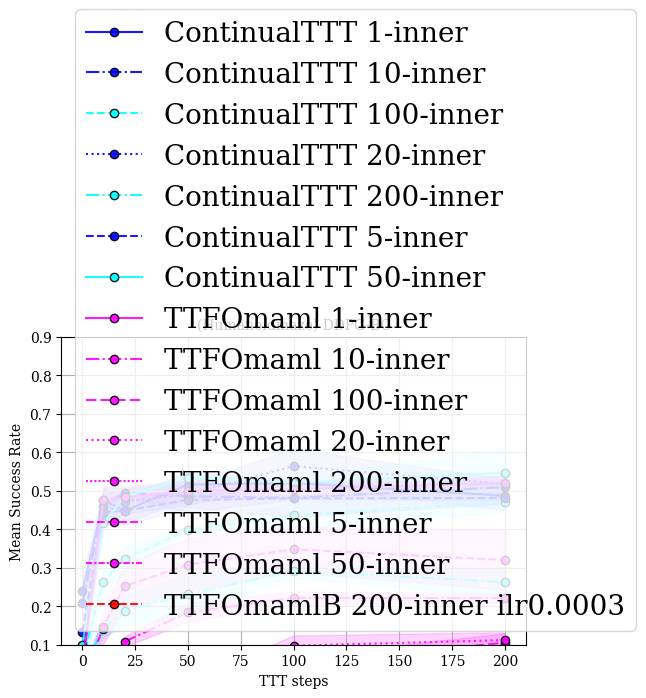

<Axes: title={'center': '(Humanoidmaze) DDPG-BC'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [29]:

HUMANOIDMAZE_CONTINUAL_TTT = {
    "ContinualTTT 1-inner": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "-",
    },
    "ContinualTTT 5-inner": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-5-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
    },
    "ContinualTTT 10-inner": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-10-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "-.",
    },
    "ContinualTTT 20-inner": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": ":",
    },
    "ContinualTTT 50-inner": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-50-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "cyan",
        "linestyle": "-",
    },
    "ContinualTTT 100-inner": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-100-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "cyan",
        "linestyle": "--",
    },
    "ContinualTTT 200-inner": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-200-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "cyan",
        "linestyle": "-.",
    },

    # TTFOmaml (was FFA) - added below, same style/format
    "TTFOmaml 1-inner": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "magenta",
        "linestyle": "-",
    },
    "TTFOmaml 5-inner": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-5-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "magenta",
        "linestyle": "--",
    },
    "TTFOmaml 10-inner": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-10-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "magenta",
        "linestyle": "-.",
    },
    "TTFOmaml 20-inner": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "magenta",
        "linestyle": ":",
    },
    "TTFOmaml 50-inner": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-50-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "magenta",
        "linestyle": (0, (3, 1, 1, 1)),  # custom dash for clarity
    },
    "TTFOmaml 100-inner": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-100-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "magenta",
        "linestyle": (0, (5, 2)),  # long dash
    },
    "TTFOmaml 200-inner": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-200-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "magenta",
        "linestyle": (0, (1, 1)),  # dotted
    },
    "TTFOmamlB 200-inner ilr0.0003": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFAB-200-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
    },
}

for run_name, run_info in HUMANOIDMAZE_CONTINUAL_TTT.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(
    HUMANOIDMAZE_CONTINUAL_TTT,
    title="(Humanoidmaze) DDPG-BC",
    ylim=(0.1, 0.9),
    use_best_auc_up_to=200,
    print_table=True,
    fontsize=10
)

num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint FFA 1-inner: 0.8864333333333333 at meta_steps 5000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint FFA 5-inner: 0.8371333333333334 at meta_steps 35000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint FFA 10-inner: 0.8405999999999999 at meta_steps 15000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint FFA 20-inner: 0.82 at meta_steps 5000
num_seeds: 3, num_meta_steps: 9
Area under success curve for best checkpoint FFA 50-inner: 0.8082999999999998 at meta_steps 10000
num_seeds: 3, num_meta_steps: 5
Area under success curve for best checkpoint FFA 100-inner: 0.7789666666666666 at meta_steps 5000
num_seeds: 3, num_meta_steps: 3
Area under success curve for best checkpoint FFA 200-inner: 0.7433666666666667 at meta_steps 5000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint JTA 1-inner: 0.61523333333

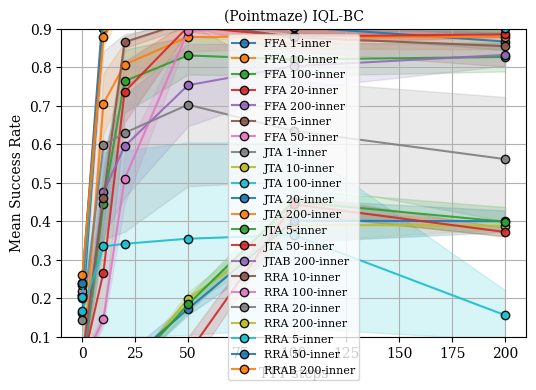

<Axes: title={'center': '(Pointmaze) IQL-BC'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [ ]:
POINTMAZE_IQL_BC_PATHS = {
    "FFA 1-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-FFA-1-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "FFA 5-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-FFA-5-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "FFA 10-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-FFA-10-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "FFA 20-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-FFA-20-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "FFA 50-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-FFA-50-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "FFA 100-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-FFA-100-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "FFA 200-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-FFA-200-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "JTA 1-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-JTA-1-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "JTA 5-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-JTA-5-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "JTA 10-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-JTA-10-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "JTA 20-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-JTA-20-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "JTA 50-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-JTA-50-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "JTA 100-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-JTA-100-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "JTA 200-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-JTA-200-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "JTAB 200-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-JTAB-200-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "RRA 5-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-5-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "RRA 10-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-10-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "RRA 20-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-20-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "RRA 50-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-50-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "RRA 100-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-100-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "RRA 200-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-200-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
    "RRAB 200-inner": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRAB-200-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
    },
}

for run_name, run_info in POINTMAZE_IQL_BC_PATHS.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(
    POINTMAZE_IQL_BC_PATHS,
    title="(Pointmaze) IQL-BC",
    ylim=(0.1, 0.9),
    use_best_auc_up_to=200,
    print_table=True,
    fontsize=10
)


In [ ]:
ANTMAZE_DDPGBC_PLOTS = {
    "JTA 1": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
    },
    "JTA 5": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-5-1-mc0.2-lr0.0003-ilr0.0003"
        ],
    },
    "JTA 10": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-10-1-mc0.2-lr0.0003-ilr0.0003"
        ],
    },
    "JTA 20": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
    },
    "JTA 50": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-50-1-mc0.2-lr0.0003-ilr0.0003"
        ],
    },
    "JTA 100": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-100-1-mc0.2-lr0.0003-ilr0.0003"
        ],
    },
    "JTA 200": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-200-1-mc0.2-lr0.0003-ilr0.0003"
        ],
    },
}

for run_name, run_info in ANTMAZE_DDPGBC_PLOTS.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(
    ANTMAZE_DDPGBC_PLOTS,
    title="(Antmaze) IQL DDPG-BC",
    ylim=(0.1, 0.9),
    use_best_auc_up_to=200,
    print_table=True,
    fontsize=10
)


num_seeds: 3, num_meta_steps: 7
Area under success curve for best checkpoint JTA 1: 0.6964 at meta_steps 5000
num_seeds: 3, num_meta_steps: 7
Area under success curve for best checkpoint JTA 5: 0.6932666666666667 at meta_steps 20000
num_seeds: 3, num_meta_steps: 10


AssertionError: Expected 1 row for seed 0 and meta_steps 5000 and ttt_steps 10 - JTA 10

## Inner loop steps ablation


num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint All: FT-Reptile-actor 5-inner eps=0.1 lr1e-03: 0.7068666666666666 at meta_steps 5000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint All: FT-Reptile-actor 10-inner eps=0.1 lr1e-03: 0.6897333333333333 at meta_steps 5000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint All: FT-Reptile-actor 20-inner eps=0.1 lr1e-03: 0.6827666666666667 at meta_steps 5000
num_seeds: 3, num_meta_steps: 8
Area under success curve for best checkpoint All: FT-Reptile-actor 50-inner eps=0.1 lr1e-03: 0.6513999999999999 at meta_steps 5000
num_seeds: 3, num_meta_steps: 5
Area under success curve for best checkpoint All: FT-Reptile-actor 100-inner eps=0.1 lr1e-03: 0.6591666666666666 at meta_steps 5000
num_seeds: 3, num_meta_steps: 3
Area under success curve for best checkpoint All: FT-Reptile-actor 200-inner eps=0.1 lr1e-03: 0.6514666666666666 at meta_steps 5000
num_seeds: 3, num_

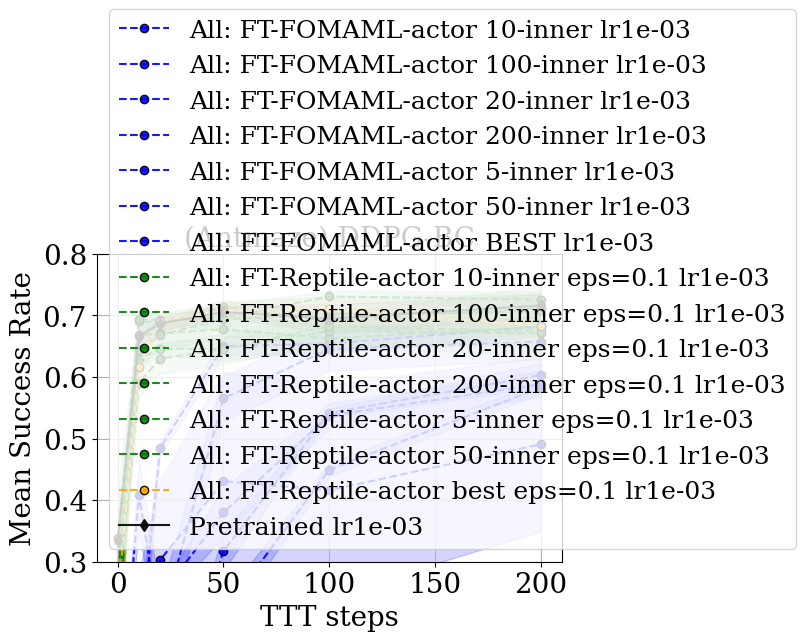

<Axes: title={'center': '(Antmaze) DDPG-BC'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [ ]:
ANTMAZE_DDPGBC_BEST_LR = {
    "All: FT-Reptile-actor 5-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-5-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 10-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-10-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 20-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-20-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 50-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-50-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 100-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-100-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 200-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-200-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },


    "All: FT-Reptile-actor best eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRAB-200-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "orange",
        "linestyle": "--",
    },


    "All: FT-FOMAML-actor 5-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-5-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 10-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-10-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 20-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-20-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 50-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-50-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 100-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-100-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 200-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-200-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor BEST lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFAB-200-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

}

for run_name, run_info in ANTMAZE_DDPGBC_BEST_LR.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(
    ANTMAZE_DDPGBC_BEST_LR,
    title="(Antmaze) DDPG-BC",
    ylim=(0.3, 0.8),
    use_best_auc_up_to=200,
    print_table=True
)

Group label: ContinualTTT 1-inner
Group info: ['antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-JTA-1-1-lr0.0003-ilr0.0003']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.6671333333333334
Meta steps: 10000, Area under success curve: 0.6794
Meta steps: 15000, Area under success curve: 0.6809999999999999
Meta steps: 20000, Area under success curve: 0.6809666666666666
Meta steps: 25000, Area under success curve: 0.6894666666666667
Meta steps: 30000, Area under success curve: 0.6996666666666667
Meta steps: 35000, Area under success curve: 0.7319
Meta steps: 40000, Area under success curve: 0.6898333333333333
Meta steps: 45000, Area under success curve: 0.7063333333333333
Meta steps: 50000, Area under success curve: 0.7053999999999999


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


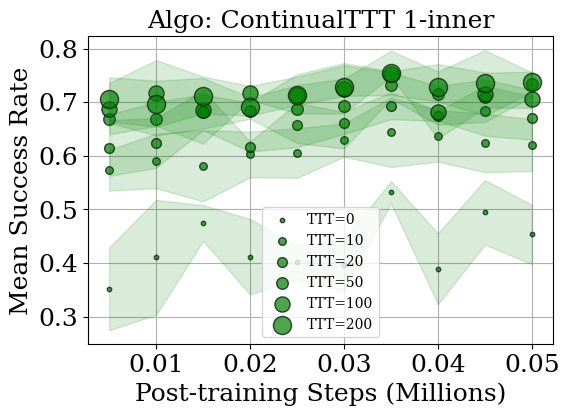

Group label: ContinualTTT 10-inner
Group info: ['antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-JTA-10-1-lr0.0003-ilr0.0003']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.6878333333333333
Meta steps: 10000, Area under success curve: 0.6200666666666667
Meta steps: 15000, Area under success curve: 0.6496333333333334
Meta steps: 20000, Area under success curve: 0.6612666666666667
Meta steps: 25000, Area under success curve: 0.6487333333333334
Meta steps: 30000, Area under success curve: 0.6360333333333333
Meta steps: 35000, Area under success curve: 0.6476333333333334
Meta steps: 40000, Area under success curve: 0.6658
Meta steps: 45000, Area under success curve: 0.6306666666666666
Meta steps: 50000, Area under success curve: 0.6636666666666666


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


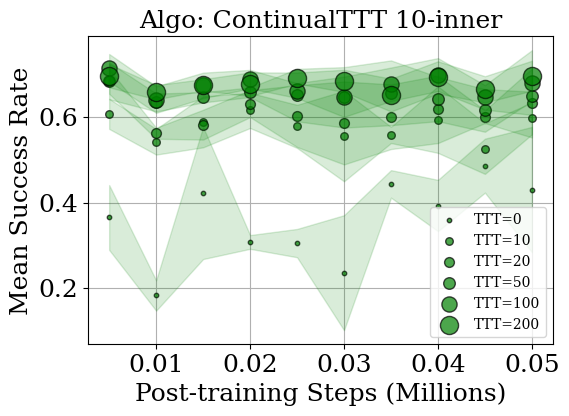

Group label: ContinualTTT 20-inner
Group info: ['antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-JTA-20-1-lr0.0003-ilr0.0003']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.6366
Meta steps: 10000, Area under success curve: 0.6374333333333333
Meta steps: 15000, Area under success curve: 0.6305666666666666
Meta steps: 20000, Area under success curve: 0.6189666666666667
Meta steps: 25000, Area under success curve: 0.6404666666666666
Meta steps: 30000, Area under success curve: 0.6272333333333333
Meta steps: 35000, Area under success curve: 0.6347333333333333
Meta steps: 40000, Area under success curve: 0.6580333333333335
Meta steps: 45000, Area under success curve: 0.6343000000000001
Meta steps: 50000, Area under success curve: 0.6536333333333332


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


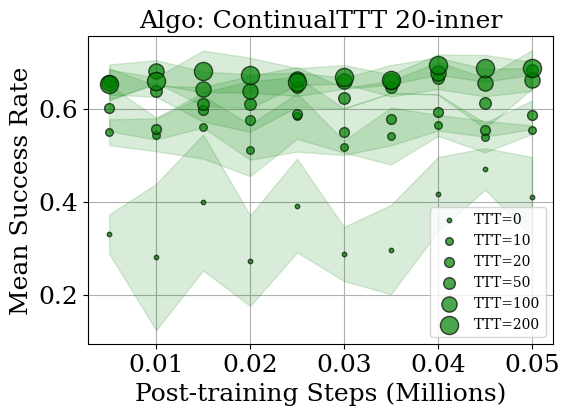

Group label: ContinualTTT 50-inner
Group info: ['antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-JTA-50-1-lr0.0003-ilr0.0003']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.5950666666666666
Meta steps: 10000, Area under success curve: 0.6196666666666667
Meta steps: 15000, Area under success curve: 0.6364
Meta steps: 20000, Area under success curve: 0.5802999999999999
Meta steps: 25000, Area under success curve: 0.5985666666666666
Meta steps: 30000, Area under success curve: 0.6145
Meta steps: 35000, Area under success curve: 0.5980000000000001
Meta steps: 40000, Area under success curve: 0.628
Meta steps: 45000, Area under success curve: 0.6224333333333333
Meta steps: 50000, Area under success curve: 0.6036333333333334


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


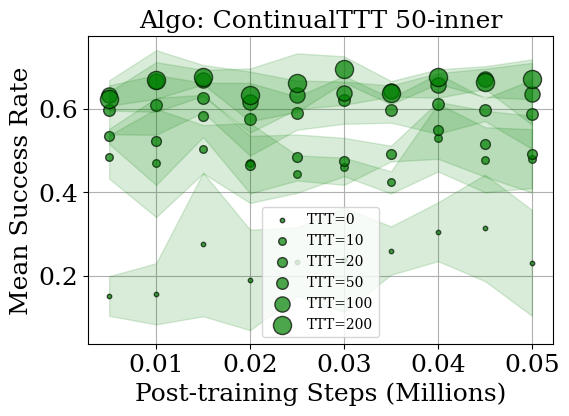

Group label: ContinualTTT 100-inner
Group info: ['antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-JTA-100-1-lr0.0003-ilr0.0003']
num_seeds: 2, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.4689
Meta steps: 10000, Area under success curve: 0.5136
Meta steps: 15000, Area under success curve: 0.4938499999999999
Meta steps: 20000, Area under success curve: 0.4828
Meta steps: 25000, Area under success curve: 0.5291999999999999
Meta steps: 30000, Area under success curve: 0.493
Meta steps: 35000, Area under success curve: 0.50255
Meta steps: 40000, Area under success curve: 0.47864999999999996
Meta steps: 45000, Area under success curve: 0.4734
Meta steps: 50000, Area under success curve: 0.5008


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


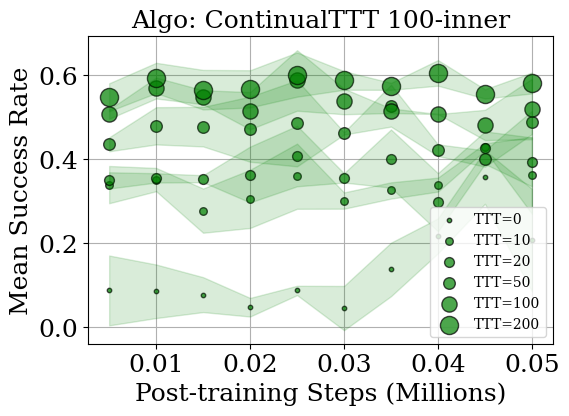

Group label: ContinualTTT Best
Group info: ['antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-JTAB-100-1-lr0.0003-ilr0.0003']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.6026666666666666
Meta steps: 10000, Area under success curve: 0.606
Meta steps: 15000, Area under success curve: 0.5531999999999999
Meta steps: 20000, Area under success curve: 0.5778333333333333
Meta steps: 25000, Area under success curve: 0.5956333333333333
Meta steps: 30000, Area under success curve: 0.5968333333333332
Meta steps: 35000, Area under success curve: 0.5909333333333334
Meta steps: 40000, Area under success curve: 0.5845999999999999
Meta steps: 45000, Area under success curve: 0.5589333333333333
Meta steps: 50000, Area under success curve: 0.6072666666666666


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


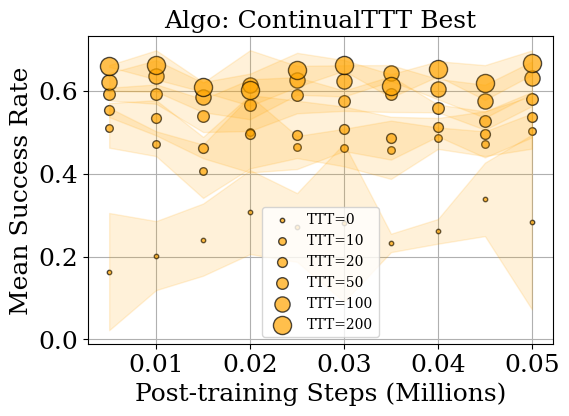

Group label: Fomaml
Group info: ['antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-FFAB-100-1-lr0.0003-ilr0.0003']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.5519999999999999
Meta steps: 10000, Area under success curve: 0.5498666666666666
Meta steps: 15000, Area under success curve: 0.5667
Meta steps: 20000, Area under success curve: 0.5449333333333333
Meta steps: 25000, Area under success curve: 0.5619666666666666
Meta steps: 30000, Area under success curve: 0.5670333333333333
Meta steps: 35000, Area under success curve: 0.5956333333333333
Meta steps: 40000, Area under success curve: 0.5809333333333332
Meta steps: 45000, Area under success curve: 0.5841666666666666
Meta steps: 50000, Area under success curve: 0.5840666666666666


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


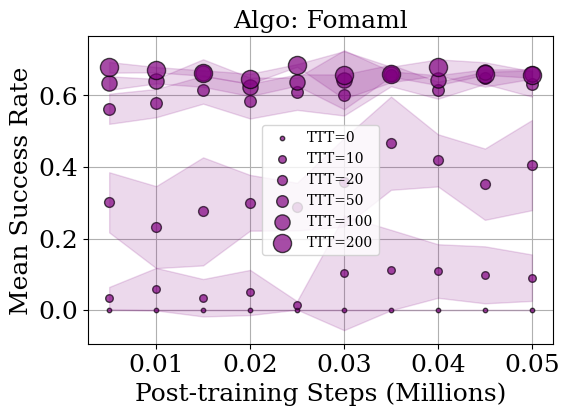

Group label: FOMAML lr3e-05
Group info: ['antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-FFAB-100-1-lr0.0003-ilr3e-05']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.573
Meta steps: 10000, Area under success curve: 0.6111
Meta steps: 15000, Area under success curve: 0.6085
Meta steps: 20000, Area under success curve: 0.5962999999999999
Meta steps: 25000, Area under success curve: 0.6305333333333334
Meta steps: 30000, Area under success curve: 0.6079666666666665
Meta steps: 35000, Area under success curve: 0.6125666666666665
Meta steps: 40000, Area under success curve: 0.6074333333333333
Meta steps: 45000, Area under success curve: 0.6194333333333333
Meta steps: 50000, Area under success curve: 0.618


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


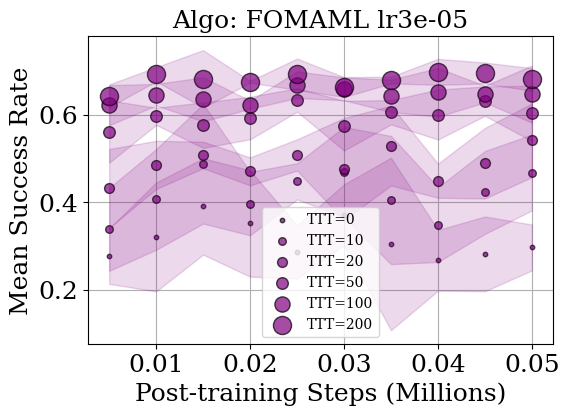

Group label: Reptile eps=0.1
Group info: ['antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-RRAB-100-1-m_0.1-lr0.1-ilr0.0003']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.6623333333333333
Meta steps: 10000, Area under success curve: 0.6568999999999999
Meta steps: 15000, Area under success curve: 0.6582333333333332
Meta steps: 20000, Area under success curve: 0.6453
Meta steps: 25000, Area under success curve: 0.6483
Meta steps: 30000, Area under success curve: 0.6464333333333333
Meta steps: 35000, Area under success curve: 0.6462
Meta steps: 40000, Area under success curve: 0.6367666666666666
Meta steps: 45000, Area under success curve: 0.6495333333333333
Meta steps: 50000, Area under success curve: 0.6342


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


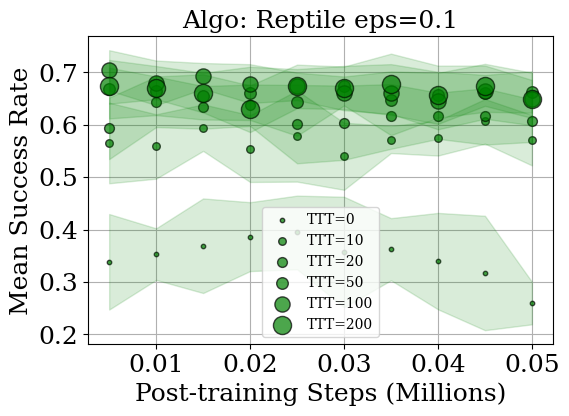

Group label: Baseline
Group info: ['antmaze_stitch/iql_ddpgbc/RANDOM-ant_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-04']
num_seeds: 3, num_meta_steps: 1
Meta steps: 400000, Area under success curve: 0.6733666666666666


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


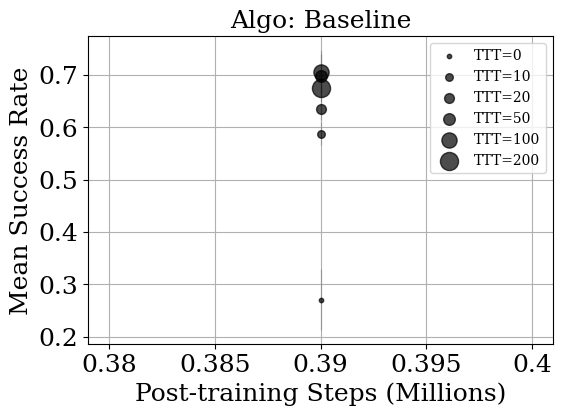

num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint ContinualTTT 1-inner: 0.7319 at meta_steps 35000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint ContinualTTT 10-inner: 0.6878333333333333 at meta_steps 5000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint ContinualTTT 20-inner: 0.6580333333333335 at meta_steps 40000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint ContinualTTT 50-inner: 0.6364 at meta_steps 15000
num_seeds: 2, num_meta_steps: 10
Area under success curve for best checkpoint ContinualTTT 100-inner: 0.5291999999999999 at meta_steps 25000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint ContinualTTT Best: 0.6072666666666666 at meta_steps 50000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint Fomaml: 0.5956333333333333 at meta_steps 35000
num_seeds: 3, num_meta_steps: 10
Area under success curve for be

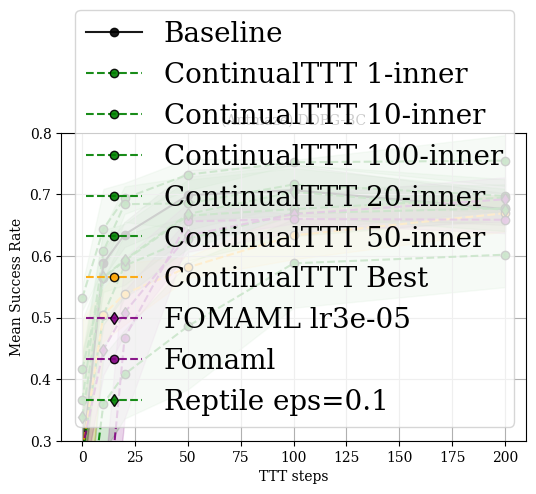

<Axes: title={'center': '(Antmaze) DDPG-BC'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [30]:
ANTMAZE_DDPGBC_INNER_ABLATION = {
    "ContinualTTT 1-inner": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-JTA-1-1-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "ContinualTTT 10-inner": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-JTA-10-1-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "ContinualTTT 20-inner": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-JTA-20-1-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "ContinualTTT 50-inner": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-JTA-50-1-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "ContinualTTT 100-inner": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-JTA-100-1-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    #"ContinualTTT 200-inner": {
    #    "groups": [
    #        "antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-JTA-200-1-lr0.0003-ilr0.0003"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},

    "ContinualTTT Best": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-JTAB-100-1-lr0.0003-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "--",
    },

    #"ContunualTTT Best (BC loss)": {
    #    "groups": [
    #        "antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-JTAB-100-1-lr0.0003-ilr0.0003_finetune_lr3e-04_actor_lossbc"
    #    ],
    #    "color": "blue",
    #    "linestyle": "--",
    #},

    "Fomaml": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-FFAB-100-1-lr0.0003-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "FOMAML lr3e-05": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-FFAB-100-1-lr0.0003-ilr3e-05"
        ],
        "color": "purple",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Reptile eps=0.1": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/FT-ALL-ant_sti-ddpgbc-RRAB-100-1-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Baseline": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/RANDOM-ant_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-04"
        ],
        "color": "black",
        "linestyle": "-",
    },

}

for run_name, run_info in ANTMAZE_DDPGBC_INNER_ABLATION.items():
    plot_mean_success_over_checkpoints({run_name: run_info}, new_style=True, root_dir="../results")

plot_max_overall_success_vs_ttt_steps(
    ANTMAZE_DDPGBC_INNER_ABLATION,
    title="(Antmaze) DDPG-BC",
    root_dir="../results",
    ylim=(0.3, 0.8),
    use_best_auc_up_to=200,
    print_table=True,
    fontsize=10
)

num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint All: FT-Reptile-actor 5-inner eps=0.1 lr1e-03: 0.7068666666666666 at meta_steps 5000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint All: FT-Reptile-actor 10-inner eps=0.1 lr1e-03: 0.6897333333333333 at meta_steps 5000
num_seeds: 3, num_meta_steps: 10
Area under success curve for best checkpoint All: FT-Reptile-actor 20-inner eps=0.1 lr1e-03: 0.6827666666666667 at meta_steps 5000
num_seeds: 3, num_meta_steps: 8
Area under success curve for best checkpoint All: FT-Reptile-actor 50-inner eps=0.1 lr1e-03: 0.6513999999999999 at meta_steps 5000
num_seeds: 3, num_meta_steps: 5
Area under success curve for best checkpoint All: FT-Reptile-actor 100-inner eps=0.1 lr1e-03: 0.6591666666666666 at meta_steps 5000
num_seeds: 3, num_meta_steps: 3
Area under success curve for best checkpoint All: FT-Reptile-actor 200-inner eps=0.1 lr1e-03: 0.6514666666666666 at meta_steps 5000
num_seeds: 3, num_

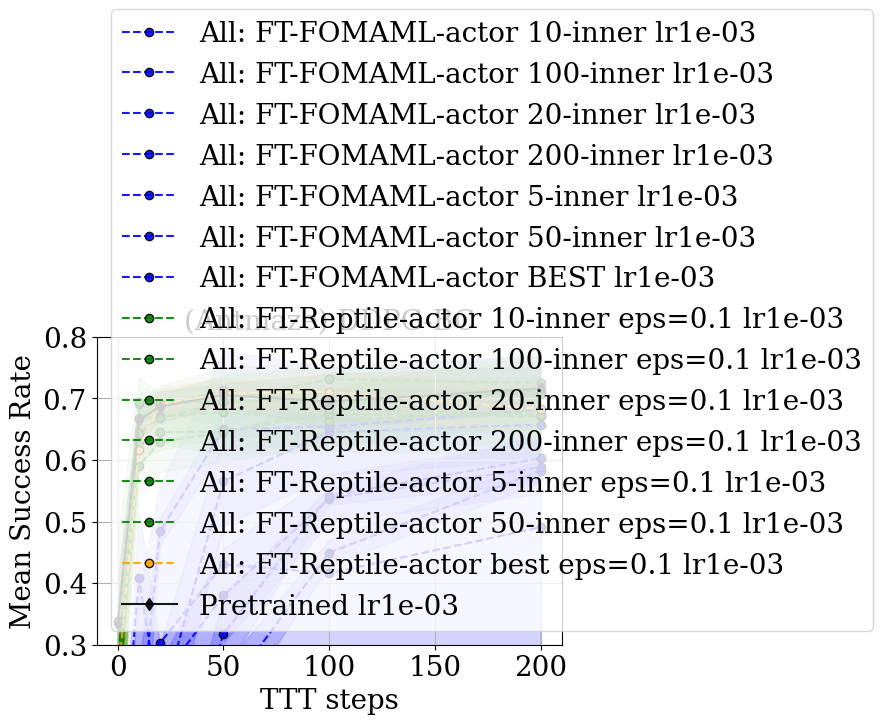

<Axes: title={'center': '(Antmaze) DDPG-BC'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [31]:
ANTMAZE_DDPGBC_BEST_LR = {
    "All: FT-Reptile-actor 5-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-5-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 10-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-10-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 20-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-20-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 50-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-50-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 100-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-100-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 200-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-200-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },


    "All: FT-Reptile-actor best eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRAB-200-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "orange",
        "linestyle": "--",
    },


    "All: FT-FOMAML-actor 5-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-5-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 10-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-10-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 20-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-20-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 50-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-50-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 100-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-100-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 200-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-200-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor BEST lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFAB-200-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

}

for run_name, run_info in ANTMAZE_DDPGBC_BEST_LR.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(
    ANTMAZE_DDPGBC_BEST_LR,
    title="(Antmaze) DDPG-BC",
    ylim=(0.3, 0.8),
    use_best_auc_up_to=200,
    print_table=True
)

In [ ]:
ANTMAZE_DDPGBC_BEST_LR = {
    "All: FT-Reptile-actor 5-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-5-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 10-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-10-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 20-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-20-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 50-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-50-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 100-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-100-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 200-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-200-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },


    "All: FT-Reptile-actor best eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRAB-200-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "orange",
        "linestyle": "--",
    },


    "All: FT-FOMAML-actor 5-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-5-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 10-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-10-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 20-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-20-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 50-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-50-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 100-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-100-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 200-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-200-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor BEST lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFAB-200-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

}

for run_name, run_info in ANTMAZE_DDPGBC_BEST_LR.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(
    ANTMAZE_DDPGBC_BEST_LR,
    title="(Antmaze) DDPG-BC",
    ylim=(0.3, 0.8),
    use_best_auc_up_to=200,
    print_table=True
)

In [24]:
group_label = "All: FT-Reptile-actor best eps=0.1 lr3e-04"
group_info = {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRAB-100-1-m_0.1-lr0.1-ilr3e-05_finetune_lr3e-04_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
}

In [25]:
from utils.plotting import fetch_group_runs

group_name = group_info["groups"][0]
settings, results = fetch_group_runs(group_name, root_dir="results_eval")


In [27]:
results

{1:     step  TTT_steps  overall_success  task1_success  task2_success  \
 0  50000          0            0.360           0.32           0.40   
 1  50000         10            0.696           0.72           0.90   
 2  50000         20            0.692           0.74           0.90   
 3  50000         50            0.732           0.86           0.94   
 4  50000        100            0.744           0.90           0.90   
 5  50000        200            0.724           0.90           0.92   
 
    task3_success  task4_success  task5_success  
 0           0.50           0.00           0.58  
 1           0.58           0.28           1.00  
 2           0.70           0.16           0.96  
 3           0.64           0.24           0.98  
 4           0.74           0.24           0.94  
 5           0.74           0.18           0.88  ,
 2:     step  TTT_steps  overall_success  task1_success  task2_success  \
 0  50000          0            0.280           0.30           0.44   
 1

# Humanoidmaze


Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
All: FT-FOMAML-actor 1-inner lr3e-04                0.0760 ± 0.0130  0.4747 ± 0.0214  0.4947 ± 0.0234  0.5173 ± 0.0129  0.5093 ± 0.0181  0.5240 ± 0.0133  0.5240 ± 0.0133
All: FT-JTA-actor 20-inner lr3e-04                  0.1467 ± 0.0205  0.5000 ± 0.0355  0.5093 ± 0.0198  0.5280 ± 0.0314  0.5860 ± 0.0240  0.5213 ± 0.0151  0.5860 ± 0.0240
FT-Reptile-best eps=0.01                            0.0813 ± 0.0101  0.5940 ± 0.0080  0.6100 ± 0.0400  0.6160 ± 0.0204  0.6387 ± 0.0194  0.5987 ± 0.0309  0.6387 ± 0.0194
FT-Reptile-best eps=0.05                            0.0820 ± 0.0080  0.6107 ± 0.0194  0.6413 ± 0.0054  0.6740 ± 0.0144  0.6420 ± 0.0400  0.6493 ± 0.00

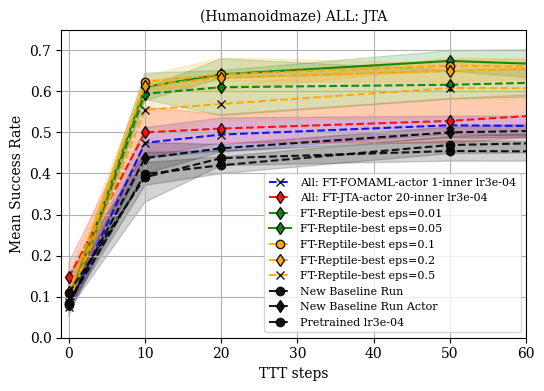

<Axes: title={'center': '(Humanoidmaze) ALL: JTA'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [ ]:
HUMANOIDMAZE_JTA = {

    "All: FT-JTA-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },

    #"All: FT-JTA-actor 200-inner lr3e-04": {
    #    "groups": [
    #        "FT-ALL-humanoidmaze-ddpgbc-JTA-200-1-mc0.2-lr0.0003-ilr0.0003"
    #    ],
    #    "color": "purple",
    #    "linestyle": "-",
    #    "dot_type": "d",
    #},

    #"All: FT-Reptile-actor Best eps=0.15": {
    #    "groups": [
    #        "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.15-lr0.15-ilr0.0003"
    #    ],
    #    "color": "green",
    #    "linestyle": "-",
    #},

    "FT-Reptile-best eps=0.01": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.01-lr0.01-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },

    "FT-Reptile-best eps=0.05": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.05-lr0.05-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "d",
    },

    "FT-Reptile-best eps=0.1": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "orange",
        "linestyle": "--",
        "dot_type": "o",
    },

    "FT-Reptile-best eps=0.2": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.2-lr0.2-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "orange",
        "linestyle": "--",
        "dot_type": "d",
    },

    "FT-Reptile-best eps=0.5": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.5-lr0.5-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "orange",
        "linestyle": "--",
        "dot_type": "x",
    },
    "New Baseline Run": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "New Baseline Run Actor": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_actor_lossddpgbc_TTT_actor"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "d",
    },


    #"All: FT-Reptile-actor Best eps=1.0": {
    #    "groups": [
    #        "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-lr1.0-ilr0.0003"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #    "dot_type": "o",
    #},
}

for run_name, run_info in HUMANOIDMAZE_JTA.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(
    HUMANOIDMAZE_JTA,
    reset=False,
    title="(Humanoidmaze) ALL: JTA",
    ylim=(0, 0.75),
    xlim=(-1, 60),
    print_table=True,
    fontsize=10)


Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
All: FT-FOMAML-actor 1-inner lr3e-04                0.0760 ± 0.0115  0.4747 ± 0.0189  0.4947 ± 0.0207  0.5173 ± 0.0114  0.5093 ± 0.0160  0.5240 ± 0.0118  0.5240 ± 0.0118
All: FT-JTA-actor 20-inner lr3e-04                  0.1467 ± 0.0181  0.5000 ± 0.0314  0.5093 ± 0.0175  0.5280 ± 0.0278  0.5860 ± 0.0173  0.5213 ± 0.0134  0.5860 ± 0.0173
All: FT-Reptile-actor Best eps=0.1                  0.0787 ± 0.0093  0.6227 ± 0.0076  0.6640 ± 0.0000  0.6280 ± 0.0085              N/A              N/A  0.6640 ± 0.0000
FT-Reptile-actor 1-inner eps=0.1                    0.0853 ± 0.0076  0.4373 ± 0.0194  0.4613 ± 0.0047  0.5000 ± 0.0068  0.5160 ± 0.0132  0.4880 ± 0.01

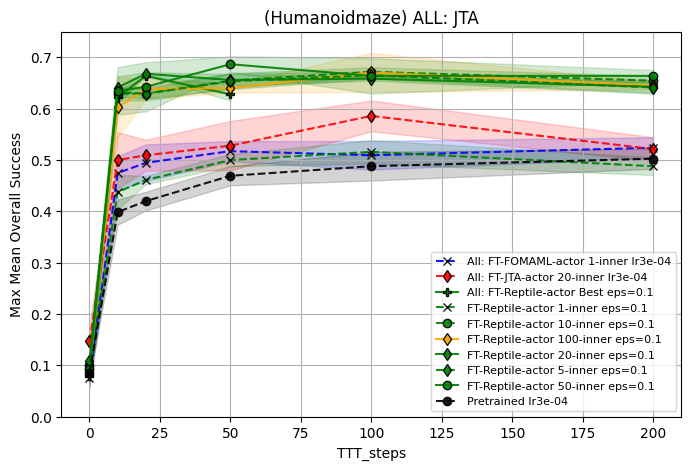

<Axes: title={'center': '(Humanoidmaze) ALL: JTA'}, xlabel='TTT_steps', ylabel='Max Mean Overall Success'>

In [ ]:
# [Humanoidmaze stitch GCIQL-DDPBC]
# TT-reptile -> sweep on inner lr

HUMANOIDMAZE_JTA = {
    "All: FT-JTA-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },

    #"All: FT-JTA-actor 200-inner lr3e-04": {
    #    "groups": [
    #        "FT-ALL-humanoidmaze-ddpgbc-JTA-200-1-mc0.2-lr0.0003-ilr0.0003"
    #    ],
    #    "color": "purple",
    #    "linestyle": "-",
    #    "dot_type": "d",
    #},

    "All: FT-Reptile-actor Best eps=0.1": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "P",
    },

    "FT-Reptile-actor 1-inner eps=0.1": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-1-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "x",
    },


    "FT-Reptile-actor 5-inner eps=0.1": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-5-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },

    "FT-Reptile-actor 10-inner eps=0.1": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-10-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "o",
    },

    "FT-Reptile-actor 20-inner eps=0.1": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-20-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "d",
    },

    "FT-Reptile-actor 50-inner eps=0.1": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-50-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "o",
    },

    "FT-Reptile-actor 100-inner eps=0.1": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-100-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "orange",
        "linestyle": "-",
        "dot_type": "d",
    },


    #"All: FT-Reptile-actor Best eps=1.0": {
    #    "groups": [
    #        "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-lr1.0-ilr0.0003"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #    "dot_type": "o",
    #},
}

for run_name, run_info in HUMANOIDMAZE_JTA.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(HUMANOIDMAZE_JTA, reset=False, title="(Humanoidmaze) ALL: JTA", ylim=(0, 0.75), print_table=True)

In [ ]:
# Antmaze BC
ANTMAZE_BC = {

    #"RRAB 0.1": {
    #    "groups": [
    #        "antmaze_iql_bc/FT-ALL-antmaze-bc-RRAB-200-1-m_0.1-lr0.1-ilr0.001_actor_lossbc"
    #    ],
    #    "color": "blue",
    #    "linestyle": "--",
    #    "dot_type": "o",
    #},

    #"RRAB 0.2": {
    #    "groups": [
    #        "antmaze_iql_bc/FT-ALL-antmaze-bc-RRAB-200-1-m_0.2-lr0.2-ilr0.001_actor_lossbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},

    #"RRAB 0.5": {
    #    "groups": [
    #        "antmaze_iql_bc/FT-ALL-antmaze-bc-RRAB-200-1-m_0.05-lr0.05-ilr0.001_actor_lossbc"
    #    ],
    #    "color": "purple",
    #    "linestyle": "--",
    #},

    "FOMAML-actor 1-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-FFA-1-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },

    #"FOMAML-actor 5-inner": {
    #    "groups": [
    #        "antmaze_iql_bc/FT-ALL-antmaze-bc-FFA-5-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossbc"
    #    ],
    #    "color": "orange",
    #    "linestyle": "--",
    #},

    #"FOMAML-actor 10-inner": {
    #    "groups": [
    #        "antmaze_iql_bc/FT-ALL-antmaze-bc-FFA-10-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossbc"
    #    ],
    #    "color": "orange",
    #    "linestyle": "--",
    #},

    "JT-actor 1-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-JTA-1-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "d",
    },

    #"RRA 1-inner": {
    #    "groups": [
    #        "antmaze_iql_bc/FT-ALL-antmaze-bc-RRA-1-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "--",
    #},

    "RRA 5-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-RRA-5-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    #"RRA 10-inner": {
    #    "groups": [
    #        "antmaze_iql_bc/FT-ALL-antmaze-bc-RRA-10-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossbc"
    #    ],
    #    "color": "pink",
    #    "linestyle": "--",
    #},

    #"RRA 20-inner": {
    #    "groups": [
    #        "antmaze_iql_bc/FT-ALL-antmaze-bc-RRA-20-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossbc"
    #    ],
    #    "color": "pink",
    #    "linestyle": "--",
    #},

    "Baseline lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

}

for run_name, run_info in ANTMAZE_BC.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(ANTMAZE_BC, reset=False, title="(Antmaze) BC", ylim=(0.3, 0.8))


# Pointmaze

DDPG-BC (Ignored?):
- Select best LR
- Reptile:
- Fomaml: 
- Joint training:

BC (best learning rate 1e-03):
- Reptile: (1, 5, 10, 20, 50, 100, 200)
- Fomaml: (1, 5, 10, 20, 50, 100, 200)
- Joint Training: In progress (TODO: evaluate)
- RRAB todo ([25000, ..., 50000]), JTAB in progress, FFAB todo

num_seeds: 3, num_meta_steps: 10
Area under success curve for RRA 5-inner lr3e-03: 0.9158666666666667
num_seeds: 3, num_meta_steps: 10


Area under success curve for Reptile (50-inner) lr3e-03: 0.9275
num_seeds: 3, num_meta_steps: 10
Area under success curve for Fomaml (1-inner) lr3e-03: 0.8950333333333333
num_seeds: 3, num_meta_steps: 10
Area under success curve for Joint Training (1-inner) lr3e-03: 0.6156333333333331
num_seeds: 3, num_meta_steps: 4
Area under success curve for RRAB lr3e-03: 0.9203333333333333
num_seeds: 3, num_meta_steps: 1
Area under success curve for Pretrained lr3e-03: 0.9019666666666666

Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
Fomaml (1-inner) lr3e-03                            0.1627 ± 0.0289  0.9667 ± 0.0079  0.9653 ± 0.0047  0.9280 ± 0.0086  0.9053 ± 0.0175  0.8840 ± 0.0371              N/A
Joint Trai

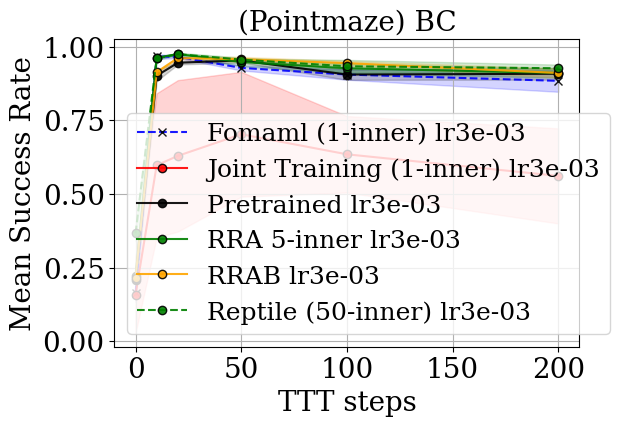

<Axes: title={'center': '(Pointmaze) BC'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [ ]:
# Pointmaze BASELINES
# TODO: evaluate for [25000, ..., 50000] RRAB
POINTMAZE_BC = {

    #"RRA 1-inner lr3e-03": {
    #    "groups": [
    #        "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-1-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
    #    ],
    #    "color": "blue",
    #    "linestyle": "-",
    #},

    "RRA 5-inner lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-5-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "-",
    },

    #"RRA 10-inner lr3e-03": {
    #    "groups": [
    #        "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-10-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
    #    ],
    #    "color": "purple",
    #    "linestyle": "-",
    #},

    #"RRA 20-inner lr3e-03": {
    #    "groups": [
    #        "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-20-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "--",
    #},

    "Reptile (50-inner) lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-50-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    #"RRA 100-inner lr3e-03": {
    #    "groups": [
    #        "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-100-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},

    #"RRA 200-inner lr3e-03": {
    #    "groups": [
    #        "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-200-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
    #    ],
    #    "color": "purple",
    #    "linestyle": "--",
    #},

    "Fomaml (1-inner) lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-FFA-1-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },


    # TODO: add Joint training
    "Joint Training (1-inner) lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-JTA-1-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
    },

    "RRAB lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRAB-200-1-m_1e-05-lr1e-05-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor_actor_lossbc"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },
}

for run_name, run_info in POINTMAZE_BC.items():
    pass #plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(POINTMAZE_BC, title="(Pointmaze) BC", print_table=True)

In [ ]:
# Pointmaze BASELINES
# TODO: evaluate for [25000, ..., 50000] RRAB
POINTMAZE_BC_REPTILE = {

    "RRA 1-inner lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-1-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "-",
    },

    "RRA 5-inner lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-5-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "-",
    },

    "RRA 10-inner lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-10-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "purple",
        "linestyle": "-",
    },

    "RRA 20-inner lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-20-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
    },

    "Reptile (50-inner) lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-50-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "orange",
        "linestyle": "--",
    },

    "RRA 100-inner lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-100-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "x",
    },

    "RRA 200-inner lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-200-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Fomaml (1-inner) lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-FFA-1-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },

    # TODO: add Joint training
    #Joint Training (1-inner) lr3e-03": {
    #    "groups": [
    #        "pointmaze_iql_bc/FT-ALL-pointmaze-bc-JTA-1-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "-",
    #},

    #"RRAB lr3e-03": {
    #    "groups": [
    #        "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRAB-200-1-m_1e-05-lr1e-05-ilr0.003_finetune_lr3e-03_actor_lossbc"
    #    ],
    #    "color": "orange",
    #    "linestyle": "-",
    #},

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor_actor_lossbc"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },
}

for run_name, run_info in POINTMAZE_BC_REPTILE.items():
    plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(POINTMAZE_BC_REPTILE, title="(Pointmaze) BC", print_table=True, ylim=(0.8, 1.0))

FileNotFoundError: Results directory not found: results_eval/pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-1-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc

<Figure size 800x500 with 0 Axes>

In [ ]:
# Pointmaze DDPG-BC
POINTMAZE_DDPGBC_BEST_LR = {

    "Fomaml (1-inner) lr5e-03": {
        "groups": [
            "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-FFA-1-1-lr0.0003-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "x",
    },

    "Reptile (1-inner) lr5e-03": {
        "groups": [
            "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-RRA-1-1-m_0.1-lr0.1-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Reptile (5-inner) lr5e-03": {
        "groups": [
            "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-RRA-5-1-m_0.1-lr0.1-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
        ],
        "color": "orange",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Reptile (10-inner) lr5e-03": {
        "groups": [
            "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-RRA-10-1-m_0.1-lr0.1-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Reptile (20-inner) lr5e-03": {
        "groups": [
            "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-RRA-20-1-m_0.1-lr0.1-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Joint Training (1-inner) lr5e-03": {
        "groups": [
            "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-JTA-1-1-lr0.0003-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr5e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },
}
for run_name, run_info in POINTMAZE_DDPGBC_BEST_LR.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(
    POINTMAZE_DDPGBC_BEST_LR,
    title="(Pointmaze) DDPG-BC",
    ylim=(0, 0.7),
    use_best_auc_up_to=200,
)


num_seeds: 3, num_meta_steps: 10


AssertionError: Expected 1 row for seed 1 and meta_steps 15000 and ttt_steps 0 - Fomaml (1-inner) lr5e-03

Group label: Fomaml (1-inner) lr3e-04
Group info: ['FT-ALL-pointmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.0003']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.2860333333333333
Meta steps: 10000, Area under success curve: 0.28619999999999995
Meta steps: 15000, Area under success curve: 0.28606666666666664
Meta steps: 20000, Area under success curve: 0.29283333333333333
Meta steps: 25000, Area under success curve: 0.3002666666666666
Meta steps: 30000, Area under success curve: 0.30039999999999994
Meta steps: 35000, Area under success curve: 0.28619999999999995
Meta steps: 40000, Area under success curve: 0.2983
Meta steps: 45000, Area under success curve: 0.2821
Meta steps: 50000, Area under success curve: 0.29679999999999995


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:387: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


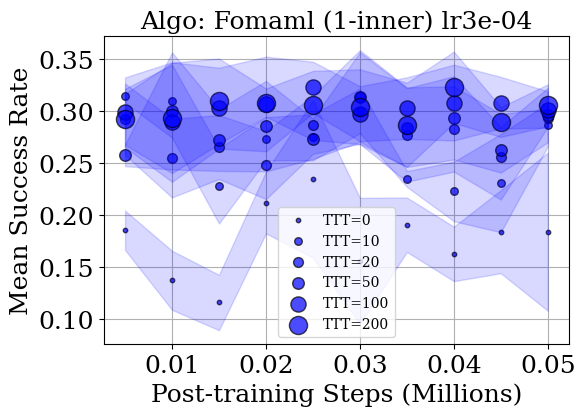

Group label: Joint Training (1-inner) lr3e-04
Group info: ['FT-ALL-pointmaze-ddpgbc-JTA-1-1-mc0.2-lr0.0003-ilr0.0003']
num_seeds: 3, num_meta_steps: 10
Meta steps: 5000, Area under success curve: 0.25743333333333335
Meta steps: 10000, Area under success curve: 0.26666666666666666
Meta steps: 15000, Area under success curve: 0.30443333333333333
Meta steps: 20000, Area under success curve: 0.25920000000000004
Meta steps: 25000, Area under success curve: 0.2593
Meta steps: 30000, Area under success curve: 0.2908333333333333
Meta steps: 35000, Area under success curve: 0.2899
Meta steps: 40000, Area under success curve: 0.30713333333333337
Meta steps: 45000, Area under success curve: 0.27833333333333327
Meta steps: 50000, Area under success curve: 0.31339999999999996


/cluster/home/anmari/gc_ttt/notebooks/../utils/plotting.py:387: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


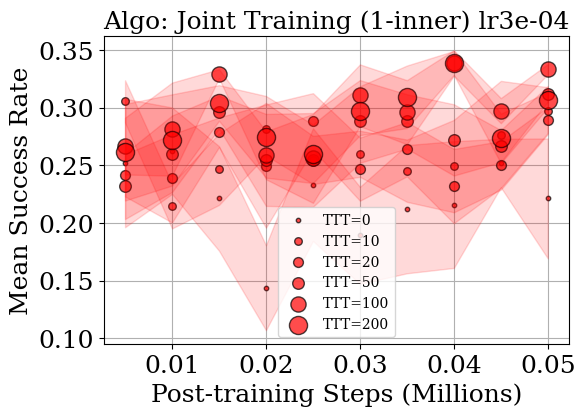

Group label: Reptile (20-inner) lr3e-04
Group info: ['FT-ALL-pointmaze-ddpgbc-RRAFIX-20-1-mc0.2-m_0.1-lr0.1-ilr0.0003']


FileNotFoundError: Results directory not found: results_eval/FT-ALL-pointmaze-ddpgbc-RRAFIX-20-1-mc0.2-m_0.1-lr0.1-ilr0.0003

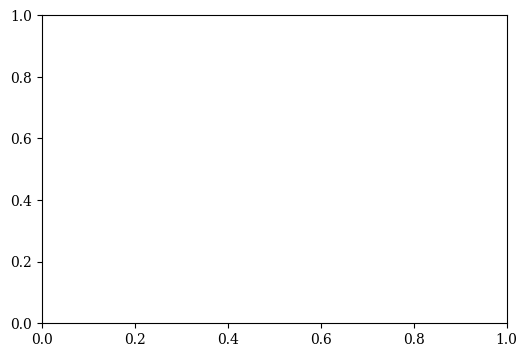

In [20]:
# Pointmaze DDPG-BC
POINTMAZE_FOMAML = {

    "Fomaml (1-inner) lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "x",
    },

    "Joint Training (1-inner) lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Reptile (20-inner) lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-20-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "o",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },
}
for run_name, run_info in POINTMAZE_FOMAML.items():
    plot_mean_success_over_checkpoints({run_name: run_info}, new_style=True)

plot_max_overall_success_vs_ttt_steps(
    POINTMAZE_FOMAML,
    title="(Pointmaze) DDPG-BC",
    ylim=(0, 0.6))


# Early stopping strategy?

Pointmaze BC:

Antmaze BC:

Antmaze DDPG-BC:

Humanoidmaze DDPG-BC:



In [ ]:
HUMANOIDMAZE_EARLY_STOPPING = {

    "All: FT-JTA-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },

    #"All: FT-JTA-actor 200-inner lr3e-04": {
    #    "groups": [
    #        "FT-ALL-humanoidmaze-ddpgbc-JTA-200-1-mc0.2-lr0.0003-ilr0.0003"
    #    ],
    #    "color": "purple",
    #    "linestyle": "-",
    #    "dot_type": "d",
    #},

    "All: FT-Reptile-actor Best eps=0.15": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.15-lr0.15-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "-",
    },

    "FT-Reptile-actor 50-inner eps=0.1": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-50-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },


    "All: FT-Reptile-actor Best eps=1.0": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-lr1.0-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "o",
    },
}

for run_name, run_info in HUMANOIDMAZE_EARLY_STOPPING.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(HUMANOIDMAZE_EARLY_STOPPING, reset=False, title="(Humanoidmaze) ALL: JTA", ylim=(0, 0.75))

In [ ]:
RRB_ANTMAZE_BC_BEST_LR = {
    "Reptile Best eps 0.05": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-RRAB-200-1-m_0.05-lr0.05-ilr0.001_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Reptile Best eps 0.1": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-RRAB-200-1-m_0.1-lr0.1-ilr0.001_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Reptile Best eps 0.2": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-RRAB-200-1-m_0.2-lr0.2-ilr0.001_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained BC lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },
}
plot_max_overall_success_vs_ttt_steps(RRB_ANTMAZE_BC_BEST_LR, reset=False, title="(Antmaze) BC Reptile-actor Early stopping", ylim=(0.3, 0.8))


In [ ]:
# TODO: evaluate these for steps 10000, 15000, 20000, ..., 50000
REPTILE_FOMAML_JTA_ANTMAZE_BC_BEST_LR = {
    "FOMAML-actor 1-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-FFA-1-1-lr0.0003-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "FOMAML-actor 5-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-FFA-5-1-lr0.0003-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "o",
    },

    "FOMAML-actor 10-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-FFA-10-1-lr0.0003-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Reptile-actor 1-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-RRA-1-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Reptile-actor 5-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-RRA-5-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "o",
    },

    "Reptile-actor 10-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-RRA-10-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },

    "JT-actor 1-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-JTA-1-1-lr0.0003-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained BC lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },
}


for run_name, run_info in FOMAML_ALL_ACTOR_ONLY.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(REPTILE_FOMAML_JTA_ANTMAZE_BC_BEST_LR, reset=False, title="(Antmaze) BC Reptile-actor Early stopping", ylim=(0.3, 0.8))


# Ablations

In [ ]:
FOMAML_ALL_ACTOR_ONLY = {
    "All: FT-FOMAML-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 5-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-5-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "orange",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 10-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-10-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "orange",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-20-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 50-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-50-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 100-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-100-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 200-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-200-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "Pretrained lr5e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "X",
    },

    "Reptile Best": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-200-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "-",
        "dot_type": "o",
    },
    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    }
}


for run_name, run_info in FOMAML_ALL_ACTOR_ONLY.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(NEW_FOMAML_ALL, reset=False, title="(Antmaze) ALL: Fomaml-actor", ylim=(0.3, 0.8))
plot_max_overall_success_vs_ttt_steps(FOMAML_ALL_ACTOR_ONLY, reset=False, title="(Antmaze) ALL: Fomaml-actor", ylim=(0.3, 0.8))


In [ ]:
JTA_ALL_ACTOR_ONLY = {
    "All: FT-Joint-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-1-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "orange",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Joint-actor 5-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-5-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-Joint-actor 10-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-10-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-Joint-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-Joint-actor 50-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-50-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-Joint-actor 100-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-100-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    "All: FT-Joint-actor 200-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-200-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    }
}


plot_max_overall_success_vs_ttt_steps(JTA_ALL_ACTOR_ONLY, reset=False, title="(Antmaze) ALL: Joint-Training-actor", ylim=(0.3, 0.8))


In [ ]:
REPTILE_ALL_ACTOR_ONLY = {
    "All: FT-Reptile-actor 1-inner eps=0.1 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-1-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor 5-inner eps=0.1 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-5-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor 10-inner eps=0.1 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-10-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor 20-inner eps=0.1 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-20-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor 50-inner eps=0.1 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-50-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor 100-inner eps=0.1 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-100-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor 200-inner eps=0.1 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-200-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "d",
    },


"Pretrained lr5e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "X",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor best eps=0.05 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAB-200-1-m_0.05-lr0.05-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor best eps=0.1 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAB-200-1-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor best eps=0.2 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAB-200-1-m_0.2-lr0.2-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor best eps=0.5 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAB-200-1-m_0.5-lr0.5-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
        "dot_type": "o",
    },
}

plot_max_overall_success_vs_ttt_steps(REPTILE_ALL_ACTOR_ONLY, reset=False, title="(Antmaze) ALL: Reptile-actor", ylim=(0.3, 0.8))


In [ ]:
# Higher learning rate
REPTILE_ALL_ACTOR_ONLY_HIGHER_LR = {
    "All: FT-Reptile-actor 1-inner eps=0.1 lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-1-1-mc0.2-m_0.1-lr0.1-ilr0.003_TTT_actor"
        ],
        "color": "purple",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor 5-inner eps=0.1 lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-5-1-mc0.2-m_0.1-lr0.1-ilr0.003_TTT_actor"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor only 1-inner eps=0.1 lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-1-1-mc0.2-m_0.1-lr0.1-ilr0.003"
        ],
        "color": "purple",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor only 5-inner eps=0.1 lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-5-1-mc0.2-m_0.1-lr0.1-ilr0.003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },


    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "d",
    }
}

plot_max_overall_success_vs_ttt_steps(REPTILE_ALL_ACTOR_ONLY_HIGHER_LR, reset=False, title="ALL: Reptile-actor", ylim=(0.3, 0.8))


In [ ]:
# Higher learning rate
FOMAML_ALL_ACTOR_ONLY_HIGHER_LR = {
    "All: FT-FOMAML-actor 1-inner lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.003_TTT_actor"
        ],
        "color": "purple",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 5-inner lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-5-1-mc0.2-lr0.0003-ilr0.003_TTT_actor"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor only 1-inner lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "purple",
        "linestyle": "--",
        "dot_type": "d",
    },

    "All: FT-FOMAML-actor only 5-inner lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-5-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },


    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    }
}

plot_max_overall_success_vs_ttt_steps(FOMAML_ALL_ACTOR_ONLY_HIGHER_LR, reset=False, title="ALL: FOMAML-actor", ylim=(0.3, 0.8))


In [ ]:
# Higher learning rate
ANTMAZE_FOMAML_HIGHER_LR = {
    "All: FT-FOMAML-actor 1-inner lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 5-inner lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-5-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "orange",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr5e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "X",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    }
}


for run_name, run_info in ANTMAZE_FOMAML_HIGHER_LR.items():
    pass #plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(ANTMAZE_FOMAML_HIGHER_LR, reset=False, title="(Antmaze) ALL: Fomaml-actor", ylim=(0.3, 0.8))

# Pointmaze

In [ ]:
# Pointmaze BASELINES
POINTMAZE_BASELINES = {
    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

        "Pretrained lr5e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr5e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Pretrained lr1e-02": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "x",
    },

    "Pretrained BC lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
    },

    "Pretrained BC lr5e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained BC lr1e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained BC lr3e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained BC lr5e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Pretrained BC lr1e-02": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "x",
    }
}

plot_max_overall_success_vs_ttt_steps(POINTMAZE_BASELINES, title="(Pointmaze) Baselines:DDPGBC vs BC")

In [ ]:
POINTMAZE_FOMAML = {

    "All: FT-FOMAML-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 5-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-5-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-FOMAML-actor 10-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-10-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 50-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-50-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 100-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-100-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 200-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-200-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },
}
for run_name, run_info in POINTMAZE_FOMAML.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(POINTMAZE_FOMAML, reset=False, title="(Pointmaze) ALL: FOMAML-actor", ylim=(0, 0.6))


In [ ]:
POINTMAZE_FOMAML_HIGHER_LR = {

    "All: FT-FOMAML-actor 1-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 5-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-5-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-FOMAML-actor 10-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-10-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 20-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-20-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 50-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-50-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 100-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-100-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "brown",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 200-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-200-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "pink",
        "linestyle": "--",
    },


    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

        "Pretrained lr5e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr5e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Pretrained lr1e-02": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "x",
    }
}

for run_name, run_info in POINTMAZE_FOMAML_HIGHER_LR.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(POINTMAZE_FOMAML_HIGHER_LR, reset=False, title="(Pointmaze) ALL: FOMAML-actor")

In [ ]:
POINTMAZE_JTA = {

    "All: FT-Joint-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Joint-actor 5-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-5-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-Joint-actor 10-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-10-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-Joint-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "All: FT-Joint-actor 50-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-50-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Joint-actor 100-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-100-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
    },

    "All: FT-Joint-actor 200-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-200-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
    },


    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    }
}

for run_name, run_info in POINTMAZE_JTA.items():
    pass #plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(POINTMAZE_JTA, reset=False, title="(Pointmaze) ALL: Joint-Training-actor", ylim=(0, 0.6))


In [ ]:
POINTMAZE_JTA_HIGHER_LR = {

    "All: FT-Joint-actor 1-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-1-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Joint-actor 5-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-5-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-Joint-actor 10-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-10-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-Joint-actor 20-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "All: FT-Joint-actor 50-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-50-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Joint-actor 100-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-100-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "brown",
        "linestyle": "--",
    },

    "All: FT-Joint-actor 200-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-200-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "pink",
        "linestyle": "-",
    },


    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    }
}

for run_name, run_info in POINTMAZE_JTA_HIGHER_LR.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(POINTMAZE_JTA_HIGHER_LR, reset=False, title="(Pointmaze) ALL: Joint-Training-actor", ylim=(0, 0.6), error_bars=False)


In [ ]:
POINTMAZE_REPTILE = {

    "All: FT-Reptile-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-1-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor 5-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-5-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-Reptile-actor 10-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-10-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-20-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 50-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-50-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 100-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-100-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "pink",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 200-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-200-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "pink",
        "linestyle": "-",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    }
}

for run_name, run_info in POINTMAZE_REPTILE.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(POINTMAZE_REPTILE, reset=False, title="(Pointmaze) ALL: Reptile-actor", ylim=(0, 0.6))


In [ ]:
POINTMAZE_REPTILE_HIGHER_LR = {

    "All: FT-Reptile-actor 1-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-1-1-mc0.2-m_0.1-lr0.1-ilr0.003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor 5-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-5-1-mc0.2-m_0.1-lr0.1-ilr0.003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-Reptile-actor 10-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-10-1-mc0.2-m_0.1-lr0.1-ilr0.003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 20-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-20-1-mc0.2-m_0.1-lr0.1-ilr0.003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 50-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-50-1-mc0.2-m_0.1-lr0.1-ilr0.003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 100-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-100-1-mc0.2-m_0.1-lr0.1-ilr0.003"
        ],
        "color": "pink",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 200-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-200-1-mc0.2-m_0.1-lr0.1-ilr0.003"
        ],
        "color": "pink",
        "linestyle": "-",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

        "Pretrained lr5e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr5e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Pretrained lr1e-02": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "x",
    }

}

for run_name, run_info in POINTMAZE_REPTILE_HIGHER_LR.items():
    pass #plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(POINTMAZE_REPTILE_HIGHER_LR, reset=False, title="(Pointmaze) ALL: Reptile-actor", ylim=(0, 0.6))


# Humanoidmaze (3 seeds)


In [ ]:
HUMANOIDMAZE_FOMAML = {

    "All: FT-FOMAML-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 5-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-5-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-FOMAML-actor 10-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-10-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 50-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-50-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 100-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-100-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "brown",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 200-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-200-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "pink",
        "linestyle": "-",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    }
}


HUMANOIDMAZE_JTA = {

    "All: FT-JTA-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-JTA-actor 5-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-5-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-JTA-actor 10-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-10-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-JTA-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "All: FT-JTA-actor 50-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-50-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-JTA-actor 100-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-100-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "brown",
        "linestyle": "--",
    },

    "All: FT-JTA-actor 200-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-200-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "pink",
        "linestyle": "-",
    },


    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "Pretrained lr5e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr5e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Pretrained lr1e-02": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "x",
    }
}

for run_name, run_info in HUMANOIDMAZE_JTA.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

for run_name, run_info in HUMANOIDMAZE_FOMAML.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(HUMANOIDMAZE_JTA, reset=False, title="(Humanoidmaze) ALL: JTA", ylim=(0, 0.75))
plot_max_overall_success_vs_ttt_steps(HUMANOIDMAZE_FOMAML, reset=False, title="(Humanoidmaze) ALL: Fomaml", ylim=(0, 0.75))

In [ ]:
HUMANOIDMAZE_RRAB = {

    "All: FT-Reptile-actor Best eps=0.05": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.05-lr0.05-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    # NOTE: this one might be not up to date implementation
    "All: FT-Reptile-actor Best eps=0.1": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor Best eps=0.15": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.15-lr0.15-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "--",
    },

    # NOTE: this one might be not up to date implementation
    "All: FT-Reptile-actor Best eps=0.2": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.2-lr0.2-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    # NOTE: this one might be not up to date implementation
    "All: FT-Reptile-actor Best eps=0.5": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.5-lr0.5-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },


    "All: FT-Reptile-actor Best eps=1.0": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-lr1.0-ilr0.0003"
        ],
        "color": "brown",
        "linestyle": "--",
    },


    "All: FT-Reptile Best eps=0.05": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRB-200-1-m_0.05-lr0.05-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "-",
    },

    # NOTE: this one might be not up to date implementation
    "All: FT-Reptile Best eps=0.1": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRB-200-1-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile Best eps=0.15": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRB-200-1-m_0.15-lr0.15-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-Reptile Best eps=1.0": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRB-200-1-lr1.0-ilr0.0003"
        ],
        "color": "brown",
        "linestyle": "-",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    }
}

for run_name, run_info in HUMANOIDMAZE_RRAB.items():
    plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(HUMANOIDMAZE_RRAB, reset=False, title="(Humanoidmaze) ALL: RRAB", ylim=(0, 0.75))


In [ ]:
HUMANOIDMAZE_JTA = {

    "All: FT-JTA-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-JTA-actor 5-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-5-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-JTA-actor 10-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-10-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-JTA-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "All: FT-JTA-actor 50-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-50-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-JTA-actor 100-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-100-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "brown",
        "linestyle": "--",
    },

    "All: FT-JTA-actor 200-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-200-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "pink",
        "linestyle": "-",
    },


    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "Pretrained lr5e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr5e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Pretrained lr1e-02": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "x",
    }


}

for run_name, run_info in HUMANOIDMAZE_JTA.items():
    pass # plot_mean_success_over_checkpoints({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(HUMANOIDMAZE_JTA, reset=False, title="(Humanoidmaze) ALL: JTA", ylim=(0, 0.75))

# TTT actor only

num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr3e-04: 0.6725666666666666
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr3e-04_TTT_actor: 0.6914999999999998
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr5e-04: 0.6791666666666666


num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr5e-04_TTT_actor: 0.711
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr1e-03: 0.6908333333333333
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr1e-03_TTT_actor: 0.7151666666666665
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr3e-03: 0.6675333333333333
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr3e-03_TTT_actor: 0.6818000000000001
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr5e-03: 0.5899666666666665
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr5e-03_TTT_actor: 0.5954999999999999


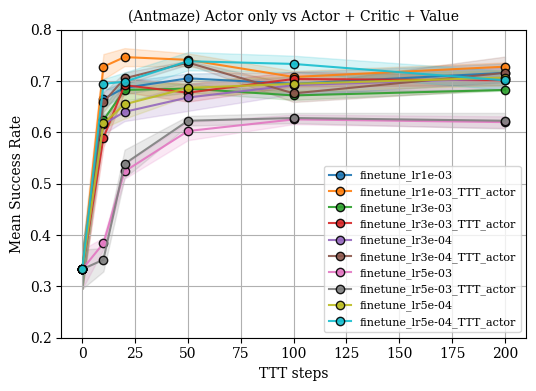

<Axes: title={'center': '(Antmaze) Actor only vs Actor + Critic + Value'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [7]:
ANTMAZE_TTT_ACTOR_ONLY = {
    "finetune_lr3e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-04"
        ]
    },
    "finetune_lr3e-04_TTT_actor": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-04_TTT_actor_actor_lossbc"
        ]
    },
    "finetune_lr5e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ]
    },
    "finetune_lr5e-04_TTT_actor": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04_TTT_actor_actor_lossbc"
        ]
    },
    "finetune_lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ]
    },
    "finetune_lr1e-03_TTT_actor": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ]
    },
    "finetune_lr3e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ]
    },
    "finetune_lr3e-03_TTT_actor": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor_actor_lossbc"
        ]
    },
    "finetune_lr5e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ]
    },
    "finetune_lr5e-03_TTT_actor": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03_TTT_actor_actor_lossbc"
        ]
    },
}

plot_max_overall_success_vs_ttt_steps(
    ANTMAZE_TTT_ACTOR_ONLY,
    title="(Antmaze) Actor only vs Actor + Critic + Value",
    ylim=(0.2, 0.8),
    fontsize=10,
)

num_seeds: 3, num_meta_steps: 1
Area under success curve for best checkpoint finetune_lr1e-03: 0.7039666666666667 at meta_steps 400000
num_seeds: 3, num_meta_steps: 1
Area under success curve for best checkpoint finetune_lr1e-03_TTT_actor: 0.6800333333333333 at meta_steps 400000
num_seeds: 3, num_meta_steps: 1
Area under success curve for best checkpoint finetune_lr1e-04: 0.6208666666666666 at meta_steps 400000
num_seeds: 3, num_meta_steps: 1
Area under success curve for best checkpoint finetune_lr1e-04_TTT_actor: 0.6073999999999998 at meta_steps 400000
num_seeds: 3, num_meta_steps: 1
Area under success curve for best checkpoint finetune_lr3e-03: 0.6605666666666667 at meta_steps 400000
num_seeds: 3, num_meta_steps: 1
Area under success curve for best checkpoint finetune_lr3e-03_TTT_actor: 0.6476333333333334 at meta_steps 400000
num_seeds: 3, num_meta_steps: 1
Area under success curve for best checkpoint finetune_lr3e-04: 0.6733666666666666 at meta_steps 400000
num_seeds: 3, num_meta_st

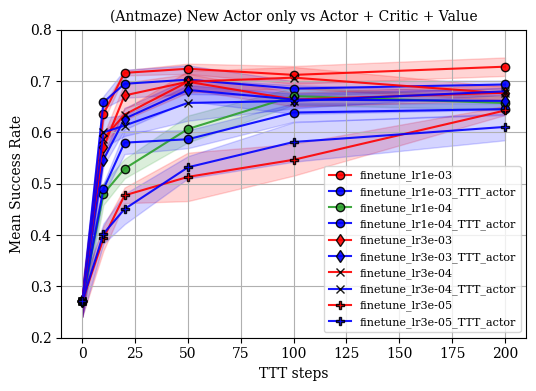

<Axes: title={'center': '(Antmaze) New Actor only vs Actor + Critic + Value'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [15]:

ANTMAZE_TTT_ACTOR_ONLY_NEW = {
    "finetune_lr1e-03": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/RANDOM-ant_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },
    "finetune_lr1e-03_TTT_actor": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/RANDOM-ant_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "o",
    },
    "finetune_lr1e-04": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/RANDOM-ant_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-04"
        ]
    },
    "finetune_lr1e-04_TTT_actor": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/RANDOM-ant_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-04_TTT_actor"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "o",
    },
    "finetune_lr3e-03": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/RANDOM-ant_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "d",
    },
    "finetune_lr3e-03_TTT_actor": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/RANDOM-ant_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "d",
    },
    "finetune_lr3e-04": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/RANDOM-ant_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-04"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "x",
    },
    "finetune_lr3e-04_TTT_actor": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/RANDOM-ant_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-04_TTT_actor"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "x",
    },
    "finetune_lr3e-05": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/RANDOM-ant_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-05"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "P",
    },
    "finetune_lr3e-05_TTT_actor": {
        "groups": [
            "antmaze_stitch/iql_ddpgbc/RANDOM-ant_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-05_TTT_actor"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "P",
    },
}


plot_max_overall_success_vs_ttt_steps(
    ANTMAZE_TTT_ACTOR_ONLY_NEW,
    title="(Antmaze) New Actor only vs Actor + Critic + Value",
    ylim=(0.2, 0.8),
    fontsize=10,
    root_dir="../results",
    use_best_auc_up_to=200,
    print_table=True,
)

num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr1e-03: 0.4086333333333333
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr1e-03_TTT_actor: 0.31683333333333336
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr1e-04: 0.2761333333333333
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr1e-04_TTT_actor: 0.2382333333333333
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr3e-03: 0.5330333333333335
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr3e-03_TTT_actor: 0.3479333333333333
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr3e-04: 0.3257333333333334
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr3e-04_TTT_actor: 0.26999999999999996
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr3e-05: 0.21446666666666667
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr3e-

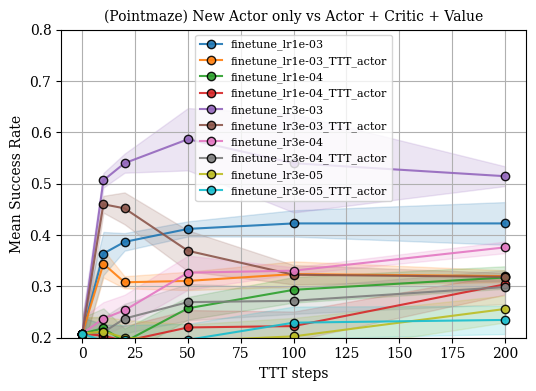

<Axes: title={'center': '(Pointmaze) New Actor only vs Actor + Critic + Value'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [23]:
POINTMAZE_TTT_ACTOR_ONLY_NEW = {
    "finetune_lr1e-03": {
        "groups": [
            "pointmaze_stitch/iql_ddpgbc/RANDOM-point_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ]
    },
    "finetune_lr1e-03_TTT_actor": {
        "groups": [
            "pointmaze_stitch/iql_ddpgbc/RANDOM-point_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor"
        ]
    },
    "finetune_lr1e-04": {
        "groups": [
            "pointmaze_stitch/iql_ddpgbc/RANDOM-point_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-04"
        ]
    },
    "finetune_lr1e-04_TTT_actor": {
        "groups": [
            "pointmaze_stitch/iql_ddpgbc/RANDOM-point_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-04_TTT_actor"
        ]
    },
    "finetune_lr3e-03": {
        "groups": [
            "pointmaze_stitch/iql_ddpgbc/RANDOM-point_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ]
    },
    "finetune_lr3e-03_TTT_actor": {
        "groups": [
            "pointmaze_stitch/iql_ddpgbc/RANDOM-point_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor"
        ]
    },
    "finetune_lr3e-04": {
        "groups": [
            "pointmaze_stitch/iql_ddpgbc/RANDOM-point_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-04"
        ]
    },
    "finetune_lr3e-04_TTT_actor": {
        "groups": [
            "pointmaze_stitch/iql_ddpgbc/RANDOM-point_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-04_TTT_actor"
        ]
    },
    "finetune_lr3e-05": {
        "groups": [
            "pointmaze_stitch/iql_ddpgbc/RANDOM-point_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-05"
        ]
    },
    "finetune_lr3e-05_TTT_actor": {
        "groups": [
            "pointmaze_stitch/iql_ddpgbc/RANDOM-point_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-05_TTT_actor"
        ]
    },
}

plot_max_overall_success_vs_ttt_steps(
    POINTMAZE_TTT_ACTOR_ONLY_NEW,
    title="(Pointmaze) New Actor only vs Actor + Critic + Value",
    ylim=(0.2, 0.8),
    fontsize=10,
    root_dir="../results",
)

In [ ]:
HUMANOIDMAZE_TTT_ACTOR_ONLY_NEW = {
    "finetune_lr1e-03": {
        "groups": [
            "humanoidmaze_stitch/iql_ddpgbc/RANDOM-humanoid_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ]
    },
    "finetune_lr1e-03_TTT_actor": {
        "groups": [
            "humanoidmaze_stitch/iql_ddpgbc/RANDOM-humanoid_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor"
        ]
    },
    "finetune_lr1e-04": {
        "groups": [
            "humanoidmaze_stitch/iql_ddpgbc/RANDOM-humanoid_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-04"
        ]
    },
    "finetune_lr1e-04_TTT_actor": {
        "groups": [
            "humanoidmaze_stitch/iql_ddpgbc/RANDOM-humanoid_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr1e-04_TTT_actor"
        ]
    },
    "finetune_lr3e-03": {
        "groups": [
            "humanoidmaze_stitch/iql_ddpgbc/RANDOM-humanoid_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ]
    },
    "finetune_lr3e-03_TTT_actor": {
        "groups": [
            "humanoidmaze_stitch/iql_ddpgbc/RANDOM-humanoid_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor"
        ]
    },
    "finetune_lr3e-04": {
        "groups": [
            "humanoidmaze_stitch/iql_ddpgbc/RANDOM-humanoid_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-04"
        ]
    },
    "finetune_lr3e-04_TTT_actor": {
        "groups": [
            "humanoidmaze_stitch/iql_ddpgbc/RANDOM-humanoid_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-04_TTT_actor"
        ]
    },
    "finetune_lr3e-05": {
        "groups": [
            "humanoidmaze_stitch/iql_ddpgbc/RANDOM-humanoid_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-05"
        ]
    },
    "finetune_lr3e-05_TTT_actor": {
        "groups": [
            "humanoidmaze_stitch/iql_ddpgbc/RANDOM-humanoid_sti-ddpgbc-JT-1-1-lr0.0003-ilr0.0003_finetune_lr3e-05_TTT_actor"
        ]
    },
}

plot_max_overall_success_vs_ttt_steps(
    HUMANOIDMAZE_TTT_ACTOR_ONLY_NEW,
    title="(Humanoidmaze) New Actor only vs Actor + Critic + Value",
    ylim=(0.0, 0.8),
    fontsize=10,
    root_dir="../results",
)

num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr3e-04: 0.41966666666666674
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr3e-04_TTT_actor: 0.38010000000000005
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr5e-04: 0.39063333333333333
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr5e-04_TTT_actor: 0.37910000000000005
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr1e-03: 0.3472
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr1e-03_TTT_actor: 0.3378999999999999
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr3e-03: 0.026799999999999987
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr3e-03_TTT_actor: 0.0274
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr5e-03: 0.002133333333333333
num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr5e-03_TTT_actor: 0.002

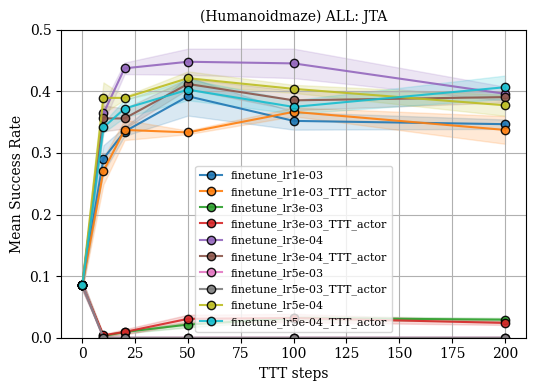

<Axes: title={'center': '(Humanoidmaze) ALL: JTA'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [10]:
HUMANOIDMAZE_TTT_ACTOR_ONLY = {

    "finetune_lr3e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-04"
        ]
    },
    "finetune_lr3e-04_TTT_actor": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-04_TTT_actor_actor_lossbc"
        ]
    },

    "finetune_lr5e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ]
    },
    "finetune_lr5e-04_TTT_actor": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04_TTT_actor_actor_lossbc"
        ]
    },
    "finetune_lr1e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ]
    },
    "finetune_lr1e-03_TTT_actor": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ]
    },
    "finetune_lr3e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ]
    },
    "finetune_lr3e-03_TTT_actor": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor_actor_lossbc"
        ]
    },
    "finetune_lr5e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ]
    },
    "finetune_lr5e-03_TTT_actor": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03_TTT_actor_actor_lossbc"
        ]
    },
}

plot_max_overall_success_vs_ttt_steps(
    HUMANOIDMAZE_TTT_ACTOR_ONLY,
    title="(Humanoidmaze) ALL: JTA",
    ylim=(0.0, 0.5),
    fontsize=10,
)

In [ ]:
POINTMAZE_TTT_ACTOR_ONLY = {

    "finetune_lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ]
    },
    "finetune_lr3e-04_TTT_actor": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-04_TTT_actor_actor_lossbc"
        ]
    },

    "finetune_lr5e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ]
    },
    "finetune_lr5e-04_TTT_actor": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04_TTT_actor_actor_lossbc"
        ]
    },
    "finetune_lr1e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ]
    },
    "finetune_lr1e-03_TTT_actor": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ]
    },
    "finetune_lr3e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ]
    },
    "finetune_lr3e-03_TTT_actor": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor_actor_lossbc"
        ]
    },
    "finetune_lr5e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ]
    },
    "finetune_lr5e-03_TTT_actor": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03_TTT_actor_actor_lossbc"
        ]
    },
}

plot_max_overall_success_vs_ttt_steps(
    POINTMAZE_TTT_ACTOR_ONLY,
    title="(Humanoidmaze) ALL: JTA",
    ylim=(0.2, 0.8),
    fontsize=10,
)

num_seeds: 3, num_meta_steps: 1
Area under success curve for finetune_lr3e-04: 0.31620000000000004


FileNotFoundError: Results directory not found: results_eval/RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-04_TTT_actor_actor_lossbc

num_seeds: 3, num_meta_steps: 10


Area under success curve for FFA-1: 0.8950333333333333
num_seeds: 3, num_meta_steps: 10
Area under success curve for FFA-5: 0.8515
num_seeds: 3, num_meta_steps: 10
Area under success curve for FFA-10: 0.8591
num_seeds: 3, num_meta_steps: 10
Area under success curve for FFA-20: 0.8400666666666666
num_seeds: 3, num_meta_steps: 9
Area under success curve for FFA-50: 0.8371666666666667
num_seeds: 3, num_meta_steps: 5
Area under success curve for FFA-100: 0.7793000000000001
num_seeds: 3, num_meta_steps: 3
Area under success curve for FFA-200: 0.7446333333333334
num_seeds: 3, num_meta_steps: 10
Area under success curve for JTA-1: 0.6156333333333331
num_seeds: 3, num_meta_steps: 10
Area under success curve for JTA-5: 0.31739999999999996
num_seeds: 3, num_meta_steps: 10
Area under success curve for JTA-10: 0.30623333333333336
num_seeds: 3, num_meta_steps: 10
Area under success curve for JTA-20: 0.3052666666666666
num_seeds: 3, num_meta_steps: 10
Area under success curve for JTA-50: 0.301633333

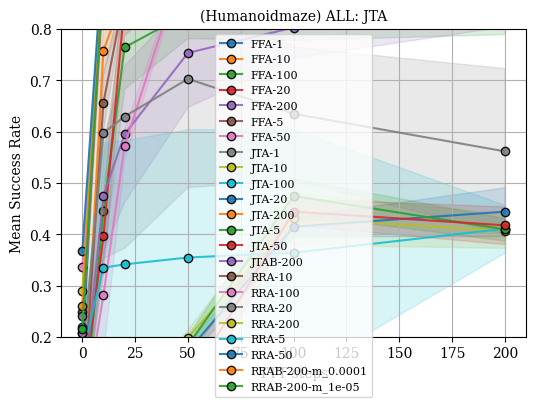

<Axes: title={'center': '(Humanoidmaze) ALL: JTA'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [ ]:
POINTMAZE_IQL_BC_FINETUNED = {
    "FFA-1": {
        "groups": [
            "FT-ALL-pointmaze-bc-FFA-1-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },
    "FFA-5": {
        "groups": [
            "FT-ALL-pointmaze-bc-FFA-5-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },
    "FFA-10": {
        "groups": [
            "FT-ALL-pointmaze-bc-FFA-10-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },
    "FFA-20": {
        "groups": [
            "FT-ALL-pointmaze-bc-FFA-20-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },
    "FFA-50": {
        "groups": [
            "FT-ALL-pointmaze-bc-FFA-50-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },
    "FFA-100": {
        "groups": [
            "FT-ALL-pointmaze-bc-FFA-100-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },
    "FFA-200": {
        "groups": [
            "FT-ALL-pointmaze-bc-FFA-200-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },

    "JTA-1": {
        "groups": [
            "FT-ALL-pointmaze-bc-JTA-1-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },
    "JTA-5": {
        "groups": [
            "FT-ALL-pointmaze-bc-JTA-5-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },
    "JTA-10": {
        "groups": [
            "FT-ALL-pointmaze-bc-JTA-10-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },
    "JTA-20": {
        "groups": [
            "FT-ALL-pointmaze-bc-JTA-20-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },
    "JTA-50": {
        "groups": [
            "FT-ALL-pointmaze-bc-JTA-50-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },
    "JTA-100": {
        "groups": [
            "FT-ALL-pointmaze-bc-JTA-100-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },
    "JTA-200": {
        "groups": [
            "FT-ALL-pointmaze-bc-JTA-200-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },

    "JTAB-200": {
        "groups": [
            "FT-ALL-pointmaze-bc-JTAB-200-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },

    "RRA-5": {
        "groups": [
            "FT-ALL-pointmaze-bc-RRA-5-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },
    "RRA-10": {
        "groups": [
            "FT-ALL-pointmaze-bc-RRA-10-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },
    "RRA-20": {
        "groups": [
            "FT-ALL-pointmaze-bc-RRA-20-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },
    "RRA-50": {
        "groups": [
            "FT-ALL-pointmaze-bc-RRA-50-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },
    "RRA-100": {
        "groups": [
            "FT-ALL-pointmaze-bc-RRA-100-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },
    "RRA-200": {
        "groups": [
            "FT-ALL-pointmaze-bc-RRA-200-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },

    "RRAB-200-m_0.0001": {
        "groups": [
            "FT-ALL-pointmaze-bc-RRAB-200-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    },
    "RRAB-200-m_1e-05": {
        "groups": [
            "FT-ALL-pointmaze-bc-RRAB-200-1-m_1e-05-lr1e-05-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ]
    }
}

plot_max_overall_success_vs_ttt_steps(
    POINTMAZE_IQL_BC_FINETUNED,
    title="(Pointmaze) ALL: JTA",
    ylim=(0.2, 0.8),
    fontsize=10,
    root_dir="results_eval/pointmaze_iql_bc",
)

num_seeds: 3, num_meta_steps: 10
Area under success curve for TT-Fomaml: 0.8950333333333333
num_seeds: 3, num_meta_steps: 10
Area under success curve for Continual-TTT: 0.9028999999999999
num_seeds: 3, num_meta_steps: 10
Area under success curve for TT-Reptile: 0.9283333333333332
num_seeds: 3, num_meta_steps: 1
Area under success curve for Pretrained: 0.9019666666666666

Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
Continual-TTT                                       0.2080 ± 0.0617  0.9013 ± 0.0343  0.9547 ± 0.0056  0.9533 ± 0.0140  0.9053 ± 0.0349  0.9080 ± 0.0391              N/A
Pretrained                                          0.2080 ± 0.0617  0.9013 ± 0.0343  0.9453 ± 0.0113  0.9533 ± 0.014

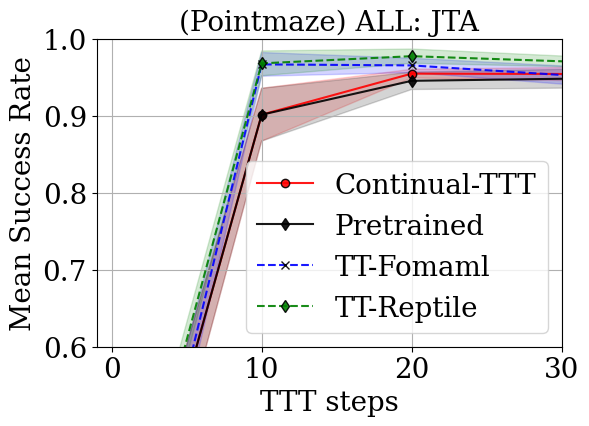

<Axes: title={'center': '(Pointmaze) ALL: JTA'}, xlabel='TTT steps', ylabel='Mean Success Rate'>

In [41]:
POINTMAZE_IQL_BC_FINETUNED = {
    "TT-Fomaml": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-FFA-1-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },
    "Continual-TTT": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-JTAB-200-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "TT-Reptile": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-10-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor_actor_lossbc"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },
}

plot_max_overall_success_vs_ttt_steps(
    POINTMAZE_IQL_BC_FINETUNED,
    title="(Pointmaze) ALL: JTA",
    figure_path="figures/pointmaze_iql_bc_ablation.pdf",
    ylim=(0.6, 1.0),
    print_table=True,
    xlim=(-1, 30),
    fontsize=20,
)

In [ ]:
# Libero results


import numpy as np
from scipy import stats

def mean_and_95ci(data):
    """Compute mean and 95% confidence interval (CI) for the mean."""
    data = np.array(data)
    mean = np.mean(data)
    se = stats.sem(data)  # Standard error of the mean
    # 95% CI using t-distribution
    ci = se * 1.96
    return mean, ci


for data in [
    [0.24, 0.24, 0.22],
    [0.06, 0, 0],
    [0.82, 0.78, 0.78],
    [0, 0, 0],
    [0.5, 0.5, 0.54],
    [0.16, 0.18, 0.16],
]:
    mean, ci = mean_and_95ci(data)
    print(f"No TTT - Mean: {mean:.2f} ± {ci:.2f} (95% CI)")

No TTT - Mean: 0.23 ± 0.01 (95% CI)
No TTT - Mean: 0.02 ± 0.04 (95% CI)
No TTT - Mean: 0.79 ± 0.03 (95% CI)
No TTT - Mean: 0.00 ± 0.00 (95% CI)
No TTT - Mean: 0.51 ± 0.03 (95% CI)
No TTT - Mean: 0.17 ± 0.01 (95% CI)


In [32]:
for data in [
    [0.1, 0.18, 0.18],
    [0.04, 0, 0.02],
    [0.5, 0.58, 0.62],
    [0.04, 0, 0.02],
    [0.02, 0, 0],
    [0, 0, 0],
    [0.02, 0, 0],
    [0.5, 0.52, 0.48],
]:
    mean, ci = mean_and_95ci(data)
    print(f"TTT - Mean: {mean:.2f} ± {ci:.2f} (95% CI)")


TTT - Mean: 0.15 ± 0.05 (95% CI)
TTT - Mean: 0.02 ± 0.02 (95% CI)
TTT - Mean: 0.57 ± 0.07 (95% CI)
TTT - Mean: 0.02 ± 0.02 (95% CI)
TTT - Mean: 0.01 ± 0.01 (95% CI)
TTT - Mean: 0.00 ± 0.00 (95% CI)
TTT - Mean: 0.01 ± 0.01 (95% CI)
TTT - Mean: 0.50 ± 0.02 (95% CI)


In [33]:
for data in [
   [0.36, 0.4, 0.46],
   [0.08, 0.18, 0.16],
   [0.84, 0.82, 0.72],
   [0.04, 0.04, 0.06],
   [0.02, 0.06, 0.02],
   [0.14, 0.16, 0.2],
   [0.4, 0.38, 0.3],
   [0.42, 0.54, 0.66]
]:
    mean, ci = mean_and_95ci(data)
    print(f"TTT - Mean: {mean:.2f} ± {ci:.2f} (95% CI)")

TTT - Mean: 0.41 ± 0.06 (95% CI)
TTT - Mean: 0.14 ± 0.06 (95% CI)
TTT - Mean: 0.79 ± 0.07 (95% CI)
TTT - Mean: 0.05 ± 0.01 (95% CI)
TTT - Mean: 0.03 ± 0.03 (95% CI)
TTT - Mean: 0.17 ± 0.03 (95% CI)
TTT - Mean: 0.36 ± 0.06 (95% CI)
TTT - Mean: 0.54 ± 0.14 (95% CI)


In [34]:
# Baseline
for data in [
    [0.06, 0.1, 0.06],
    [0, 0, 0],
    [0.8, 0.84, 0.92],
    [0, 0, 0.02]
]:
    mean, ci = mean_and_95ci(data)
    print(f"Baseline - Mean: {mean:.2f} ± {ci:.2f} (95% CI)")

Baseline - Mean: 0.07 ± 0.03 (95% CI)
Baseline - Mean: 0.00 ± 0.00 (95% CI)
Baseline - Mean: 0.85 ± 0.07 (95% CI)
Baseline - Mean: 0.01 ± 0.01 (95% CI)
